# Air Quality in India

**Main Idea:** The project aims to transform raw environmental data into an actionable policy roadmap for India. By combining forecasting, causal clustering, and spatial optimization, we provide a comprehensive framework to understand not just how polluted the air is, but why it is polluted and where we need better data to make informed decisions drove air quality.

#### **The Technical Pipeline (Workflow)**
1. **Temporal Analysis: Forecasting (The "Warning" Phase)**
- Action: Predict AQI trends for the end of 2020 using historical data (2015–2020).
- Goal: To establish the trajectory of the air quality crisis. This phase proves the urgency of the problem and identifies whether current mitigation efforts are sufficient.

2. **Causal Analysis: Interpretative Clustering (The "Diagnosis" Phase)**
- Action: Apply K-Means clustering to segment monitoring stations based on their chemical "fingerprints" (ratios of $SO_2, NO_2, CO, PM_{2.5}$).
- Explainability: To overcome the "black-box" nature of clustering, we use a Decision Tree surrogate model.
- Goal: To identify the root causes of pollution. Instead of generic policies, this allows for targeted interventions (e.g., distinguishing "Traffic-Dominated" zones from "Industrial-Thermal" hubs).

3. **Spatial Analysis: Network Optimization**
- Action: Utilize Ordinary Kriging to interpolate data and generate a "Uncertainty/Variance Map" of the Indian monitoring network.
- Goal: To identify geographic "Blind Spots" (information deserts). By locating coordinates where the model's confidence is lowest, we propose optimal sites for new monitoring stations to ensure future data collection is maximized for effective policy-making.

In [184]:
# import libraries
import kagglehub
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tabulate
import os
import warnings
import plotly.express as px
import json
import scipy.stats as st
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from IPython.display import Image, display

import lightgbm as lgb
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import silhouette_score, davies_bouldin_score
from folium import DivIcon
import math
from math import pi

from sklearn.ensemble import RandomForestClassifier
from pykrige.ok import OrdinaryKriging
import folium
import geopandas as gpd
from shapely.geometry import Point

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Data load and preprocessing

This part of the project includes:
- choice of most suitable dataset for project purpouses
- development of imputation strategy and filling in missing values
- chwkibg for explicit and implicit duplicates 

In [185]:
#loading data using kaggle api
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12


In [186]:
# Construct the full file path for one of the dataset files
station_hour = os.path.join(path, 'station_hour.csv') 
station_day = os.path.join(path, 'station_day.csv')
city_day = os.path.join(path, 'city_day.csv')
city_hour = os.path.join(path, 'city_hour.csv')
stations = os.path.join(path, 'stations.csv')


# Load the data into a DataFrame
station_hour = pd.read_csv(station_hour)
station_day = pd.read_csv(station_day)
city_day = pd.read_csv(city_day)
city_hour = pd.read_csv(city_hour)
stations = pd.read_csv(stations)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32908\4204765171.py:10: DtypeWarning:

Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.



In [187]:
# we are planning to work primarily with station hour, but i have uploaded all datasets
station_hour = pd.DataFrame(station_hour)
station_day = pd.DataFrame(station_day)
city_day = pd.DataFrame(city_day)
city_hour = pd.DataFrame(city_hour)
stations = pd.DataFrame(stations)

In [188]:
# overview that station_hour data loaded correctly
station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [189]:
# cheking for datatypes
station_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   StationId   object 
 1   Datetime    object 
 2   PM2.5       float64
 3   PM10        float64
 4   NO          float64
 5   NO2         float64
 6   NOx         float64
 7   NH3         float64
 8   CO          float64
 9   SO2         float64
 10  O3          float64
 11  Benzene     float64
 12  Toluene     float64
 13  Xylene      float64
 14  AQI         float64
 15  AQI_Bucket  object 
dtypes: float64(13), object(3)
memory usage: 316.1+ MB


In [190]:
# the datetime variable should be stored in the appropriate type
station_hour['Datetime'] = pd.to_datetime(station_hour['Datetime'])

In [191]:
#creating separate time variables for further analysis
#variable with date
station_hour['Date'] = station_hour['Datetime'].dt.date

#variable with time
station_hour['Time'] = station_hour['Datetime'].dt.hour

#variable with month
station_hour['Month'] = station_hour['Datetime'].dt.month

#variable with day of the week (0-Monday, 6-Sunday)
station_hour['Weekday'] = station_hour['Datetime'].dt.weekday

#Defining period of the day (Night, Morning, Day, Evening)
bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Day', 'Evening']
station_hour['Time_Period'] = pd.cut(station_hour['Time'], bins=bins, labels=labels, right=False, include_lowest=True)

In [192]:
# overviewing station_hour data after creating additional time variables
station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Date,Time,Month,Weekday,Time_Period
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,...,0.1,6.10,0.10,NaN,NaN,2017-11-24,17,11,4,Day
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,...,0.1,6.25,0.15,NaN,NaN,2017-11-24,18,11,4,Evening
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,...,0.2,5.98,0.18,NaN,NaN,2017-11-24,19,11,4,Evening
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,...,0.2,6.72,0.10,NaN,NaN,2017-11-24,20,11,4,Evening
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,...,0.2,5.75,0.08,NaN,NaN,2017-11-24,21,11,4,Evening


In [193]:
# overview that station_day data loaded correctly
station_day.head()

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [194]:
# cheking for correct datatypes
station_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   StationId   108035 non-null  object 
 1   Date        108035 non-null  object 
 2   PM2.5       86410 non-null   float64
 3   PM10        65329 non-null   float64
 4   NO          90929 non-null   float64
 5   NO2         91488 non-null   float64
 6   NOx         92535 non-null   float64
 7   NH3         59930 non-null   float64
 8   CO          95037 non-null   float64
 9   SO2         82831 non-null   float64
 10  O3          82467 non-null   float64
 11  Benzene     76580 non-null   float64
 12  Toluene     69333 non-null   float64
 13  Xylene      22898 non-null   float64
 14  AQI         87025 non-null   float64
 15  AQI_Bucket  87025 non-null   object 
dtypes: float64(13), object(3)
memory usage: 13.2+ MB


In [195]:
# the same as in the previous dataset date values should be stored as date
station_day['Date'] = pd.to_datetime(station_day['Date'])

In [196]:
# overview that city_day data loaded correctly
city_day.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [197]:
# cheking for correct datatypes
city_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [198]:
# the same as in the previous dataset date vales should be stored as date
city_day['Date'] = pd.to_datetime(city_day['Date'])

In [199]:
# overview that city_hour data loaded correctly
city_hour.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [200]:
# cheking for correct datatypes
city_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707875 entries, 0 to 707874
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   City        707875 non-null  object 
 1   Datetime    707875 non-null  object 
 2   PM2.5       562787 non-null  float64
 3   PM10        411138 non-null  float64
 4   NO          591243 non-null  float64
 5   NO2         590753 non-null  float64
 6   NOx         584651 non-null  float64
 7   NH3         435333 non-null  float64
 8   CO          621358 non-null  float64
 9   SO2         577502 non-null  float64
 10  O3          578667 non-null  float64
 11  Benzene     544229 non-null  float64
 12  Toluene     487268 non-null  float64
 13  Xylene      252046 non-null  float64
 14  AQI         578795 non-null  float64
 15  AQI_Bucket  578795 non-null  object 
dtypes: float64(13), object(3)
memory usage: 86.4+ MB


In [201]:
# the same as in the previous dataset date vales should be stored as date
city_hour['Datetime'] = pd.to_datetime(city_hour['Datetime'])

In [202]:
# creating additional time variables for the city_hour dataset
city_hour['Date'] = city_hour['Datetime'].dt.date
city_hour['Time'] = city_hour['Datetime'].dt.hour

In [203]:
# function for calculating share of missing values for each variable in the datasets
def get_missing_percentage_for_plot(df, df_name):
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_df = mis_val_percent.reset_index()
    mis_val_df.columns = ['Feature', 'Missing_Percentage']
    mis_val_df['Dataset'] = df_name
    mis_val_df = mis_val_df[mis_val_df['Missing_Percentage'] > 0]
    return mis_val_df

In [204]:
datasets_to_process = [
    (city_day, 'city_day'),
    (city_hour, 'city_hour'),
    (station_day, 'station_day'),
    (station_hour, 'station_hour')
]
all_missing_data = pd.concat([
    get_missing_percentage_for_plot(df, name) for df, name in datasets_to_process
], ignore_index=True)

In [205]:
# preparing data for heatmap visualization
heatmap_data = all_missing_data.pivot_table(
    index='Feature',
    columns='Dataset',
    values='Missing_Percentage'
).fillna(0.0).round(1)

In [206]:
# sorting values for visual representation
heatmap_data['Total_Missing_Avg'] = heatmap_data.sum(axis=1) / len(datasets_to_process)
heatmap_data = heatmap_data.sort_values(by='Total_Missing_Avg', ascending=False).drop(columns=['Total_Missing_Avg'])

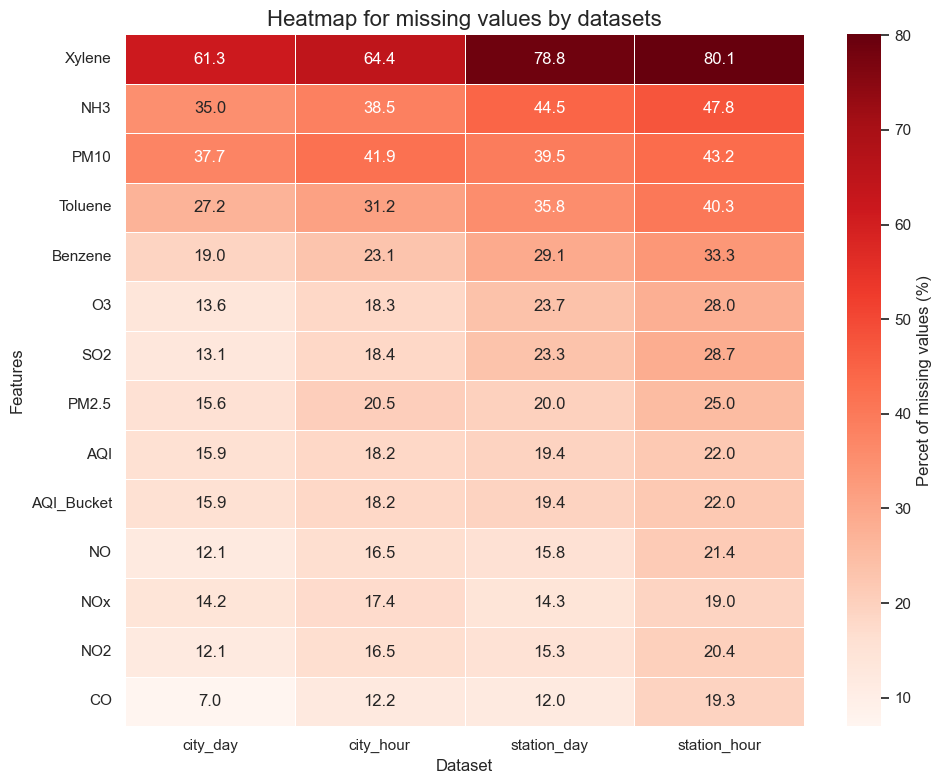

In [207]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,             
    fmt=".1f",             
    cmap="Reds",
    linewidths=.5,          
    cbar_kws={'label': 'Percet of missing values (%)'} # Подпись цветовой шкалы
)

plt.title('Heatmap for missing values by datasets', fontsize=16)
plt.ylabel('Features', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('missing_values_heatmap_comparison.png')
plt.show()

***
**What data we choose and why**
- Hourly data ha sthe greates  percetage of missing values for each variable
- In general the missing values for data by stations is greater
**Despite the fact that `station_hour` dataset contains the greatest number of missing values, but meanwhile the greatest number of observatios, for our projethe most detailedile data suits tproject's aimect the best.**

We choose:
- **station-level** data for geaographical reasons, as its depicts local picture of pollution
- **hour-level** data sinceimportant for modelling elling purpouses, and allows more flexible aggregation, but we should pay attention to fact that hourly data is sesetive to noise
***

### Imputing missing values

In this subsection of data preparation we firstly analyse missing values patterns, then choose the strategy for filling in missing values.

In [208]:
#overviewing chose dataset
station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Date,Time,Month,Weekday,Time_Period
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,...,0.1,6.10,0.10,NaN,NaN,2017-11-24,17,11,4,Day
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,...,0.1,6.25,0.15,NaN,NaN,2017-11-24,18,11,4,Evening
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,...,0.2,5.98,0.18,NaN,NaN,2017-11-24,19,11,4,Evening
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,...,0.2,6.72,0.10,NaN,NaN,2017-11-24,20,11,4,Evening
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,...,0.2,5.75,0.08,NaN,NaN,2017-11-24,21,11,4,Evening


In [209]:
# cheking descriptive statistics
station_hour.describe()

,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Time,Month,Weekday
count,2589083,1.941394e+06,1.469831e+06,2.035372e+06,2.060110e+06,2.098275e+06,1.352465e+06,2.089781e+06,1.846346e+06,1.863110e+06,1.727504e+06,1.546717e+06,513979.000000,2.018893e+06,2.589083e+06,2.589083e+06,2.589083e+06
mean,2018-08-17 09:52:35.777856768,8.086481e+01,1.584839e+02,2.278825e+01,3.523689e+01,4.055115e+01,2.870856e+01,1.502366e+00,1.211602e+01,3.806408e+01,3.305493e+00,1.490266e+01,2.448881,1.801730e+02,1.150185e+01,6.287408e+00,2.999846e+00
min,2015-01-01 01:00:00,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,0.000000e+00,0.000000,5.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2017-10-13 20:00:00,2.816000e+01,6.400000e+01,3.050000e+00,1.310000e+01,1.135000e+01,1.123000e+01,4.100000e-01,4.250000e+00,1.102000e+01,8.000000e-02,3.400000e-01,0.000000,8.400000e+01,6.000000e+00,3.000000e+00,1.000000e+00
50%,2018-12-02 06:00:00,5.259000e+01,1.162500e+02,7.150000e+00,2.479000e+01,2.286000e+01,2.235000e+01,8.000000e-01,8.250000e+00,2.475000e+01,9.600000e-01,3.400000e+00,0.200000,1.310000e+02,1.200000e+01,6.000000e+00,3.000000e+00
75%,2019-10-15 06:00:00,9.774000e+01,2.040000e+02,1.858000e+01,4.548000e+01,4.570000e+01,3.778000e+01,1.380000e+00,1.453000e+01,4.953000e+01,3.230000e+00,1.510000e+01,1.830000,2.590000e+02,1.800000e+01,9.000000e+00,5.000000e+00
max,2020-07-01 00:00:00,1.000000e+03,1.000000e+03,5.000000e+02,4.999900e+02,5.000000e+02,4.999700e+02,4.985700e+02,1.999600e+02,9.970000e+02,4.980700e+02,4.999900e+02,499.990000,3.133000e+03,2.300000e+01,1.200000e+01,6.000000e+00
std,NaN,8.947618e+01,1.397883e+02,4.846146e+01,3.497508e+01,5.590894e+01,2.753244e+01,6.292445e+00,1.467385e+01,4.710653e+01,1.214053e+01,3.329729e+01,8.973470,1.404095e+02,6.922524e+00,3.431469e+00,2.000903e+00


In [210]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

missing_values= missing_values_table(station_hour)
missing_values.style.background_gradient(cmap='Reds')

Your selected dataframe has 21 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
Xylene,2075104,80.100000
NH3,1236618,47.800000
PM10,1119252,43.200000
Toluene,1042366,40.300000
Benzene,861579,33.300000
SO2,742737,28.700000
O3,725973,28.000000
PM2.5,647689,25.000000
AQI_Bucket,570190,22.000000
AQI,570190,22.000000


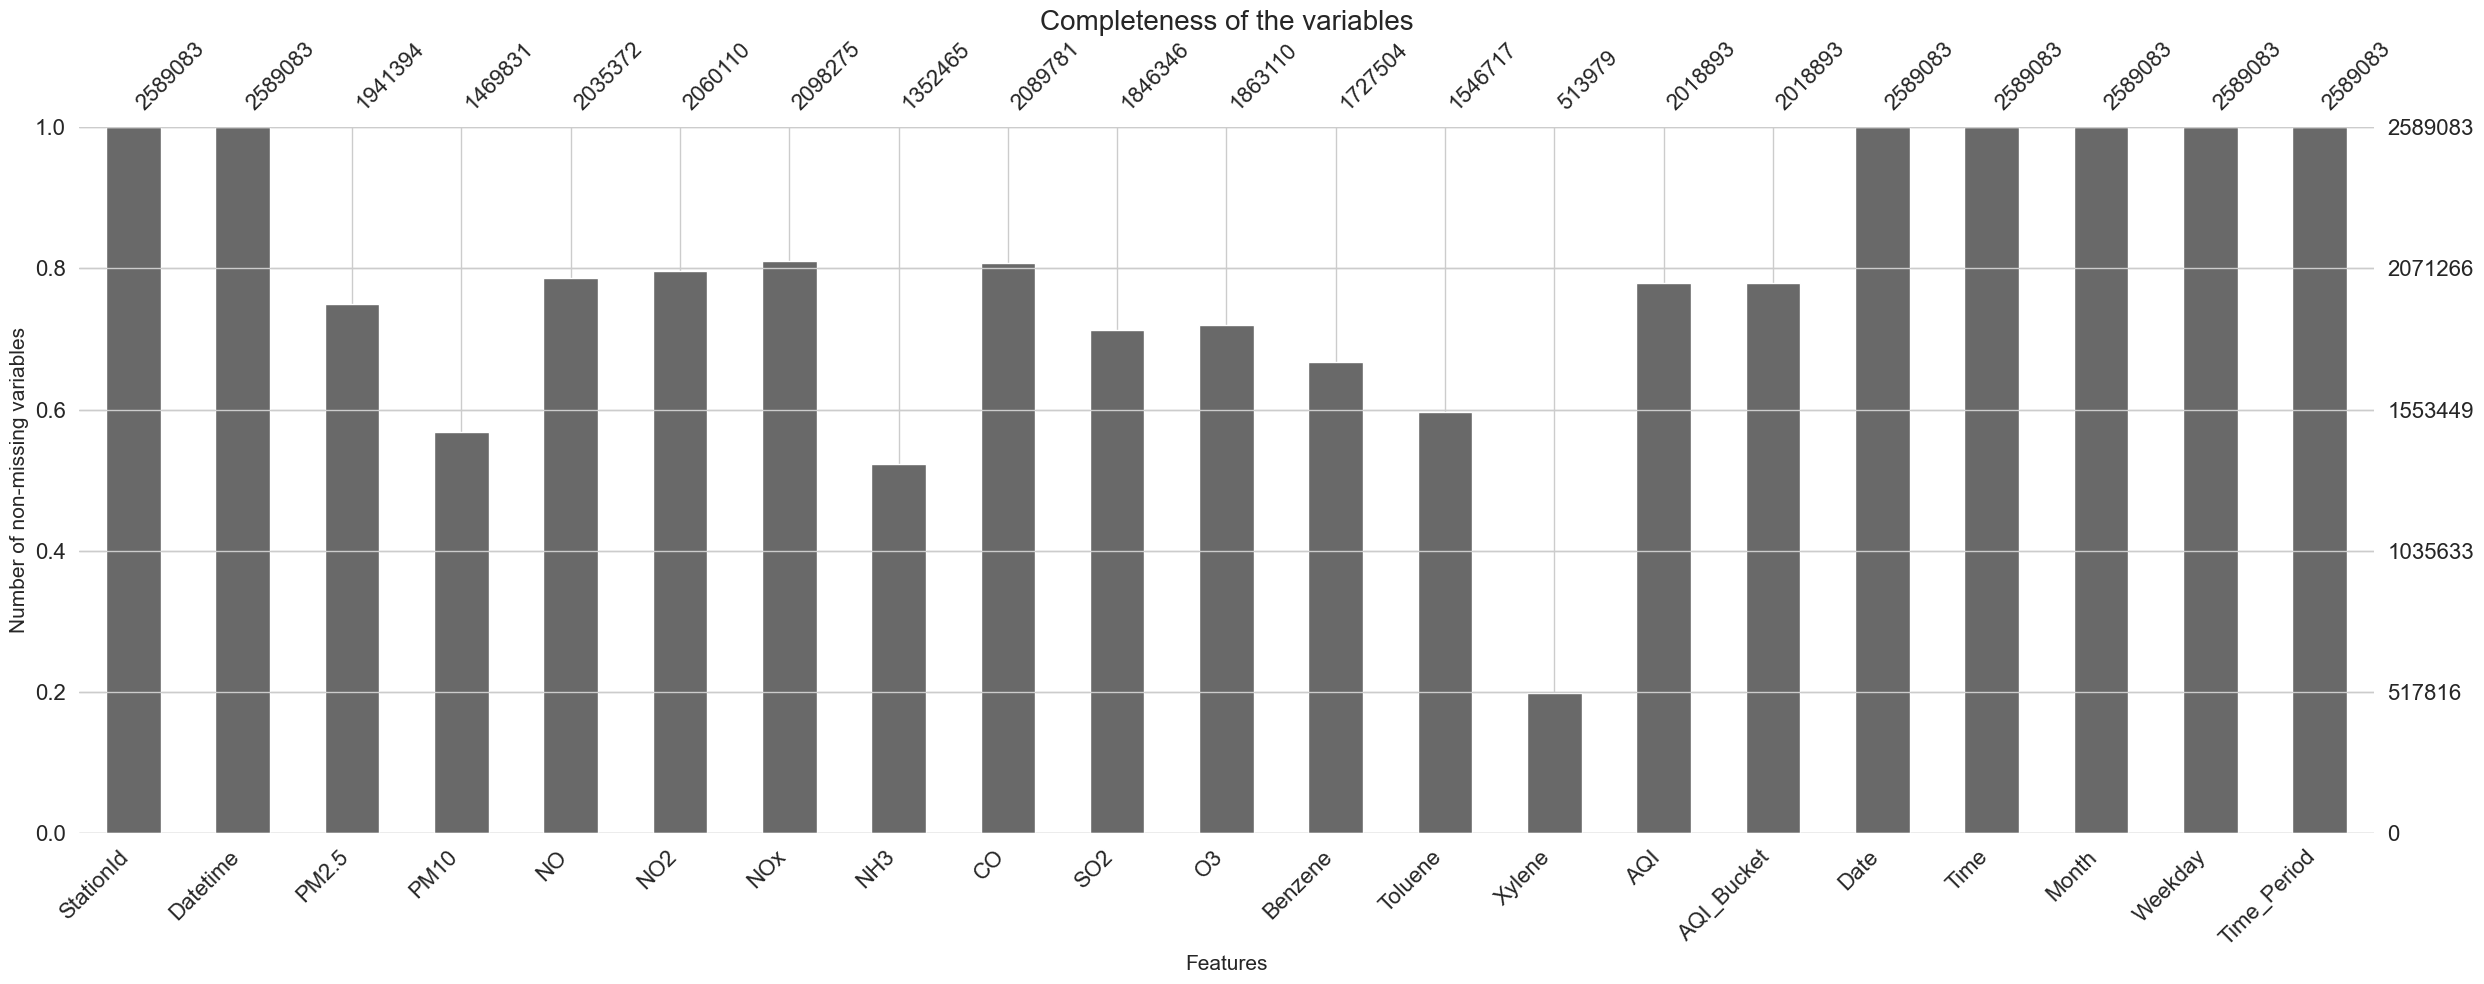

In [211]:
# using missingno library to analyze patterns in missing data
ax = msno.bar(station_hour)

ax.set_title('Completeness of the variables', fontsize=20)
ax.set_xlabel('Features', fontsize = 15)
ax.set_ylabel('Number of non-missing variables', fontsize = 15)

plt.tight_layout() 

plt.show()

''

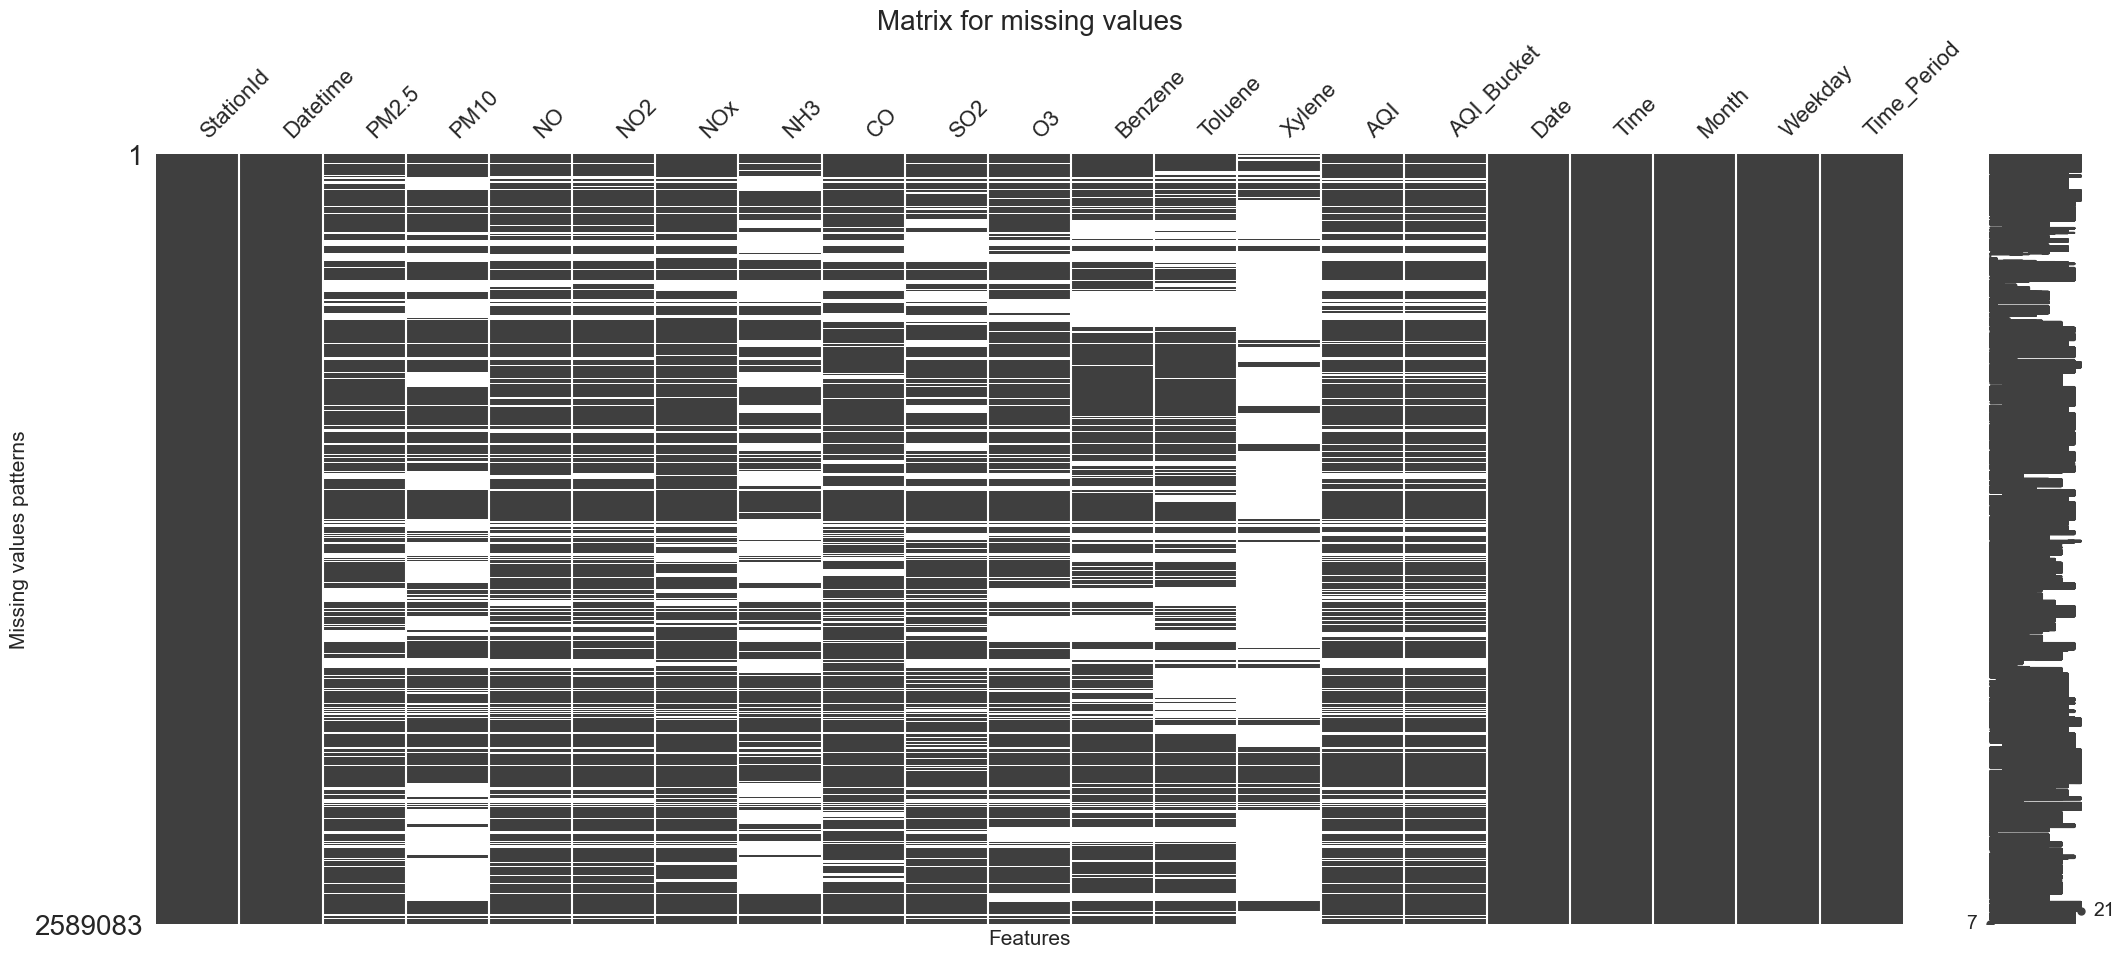

In [212]:
# looking for the bloos of missig data, similar pattern in different columns means that these datapoints were likely collected together
missing_values.style.background_gradient(cmap='Reds')
msno.matrix(station_hour)

plt.title('Matrix for missing values', fontsize = 20)
plt.xlabel('Features', fontsize = 15)
plt.ylabel('Missing values patterns', fontsize = 15)
;

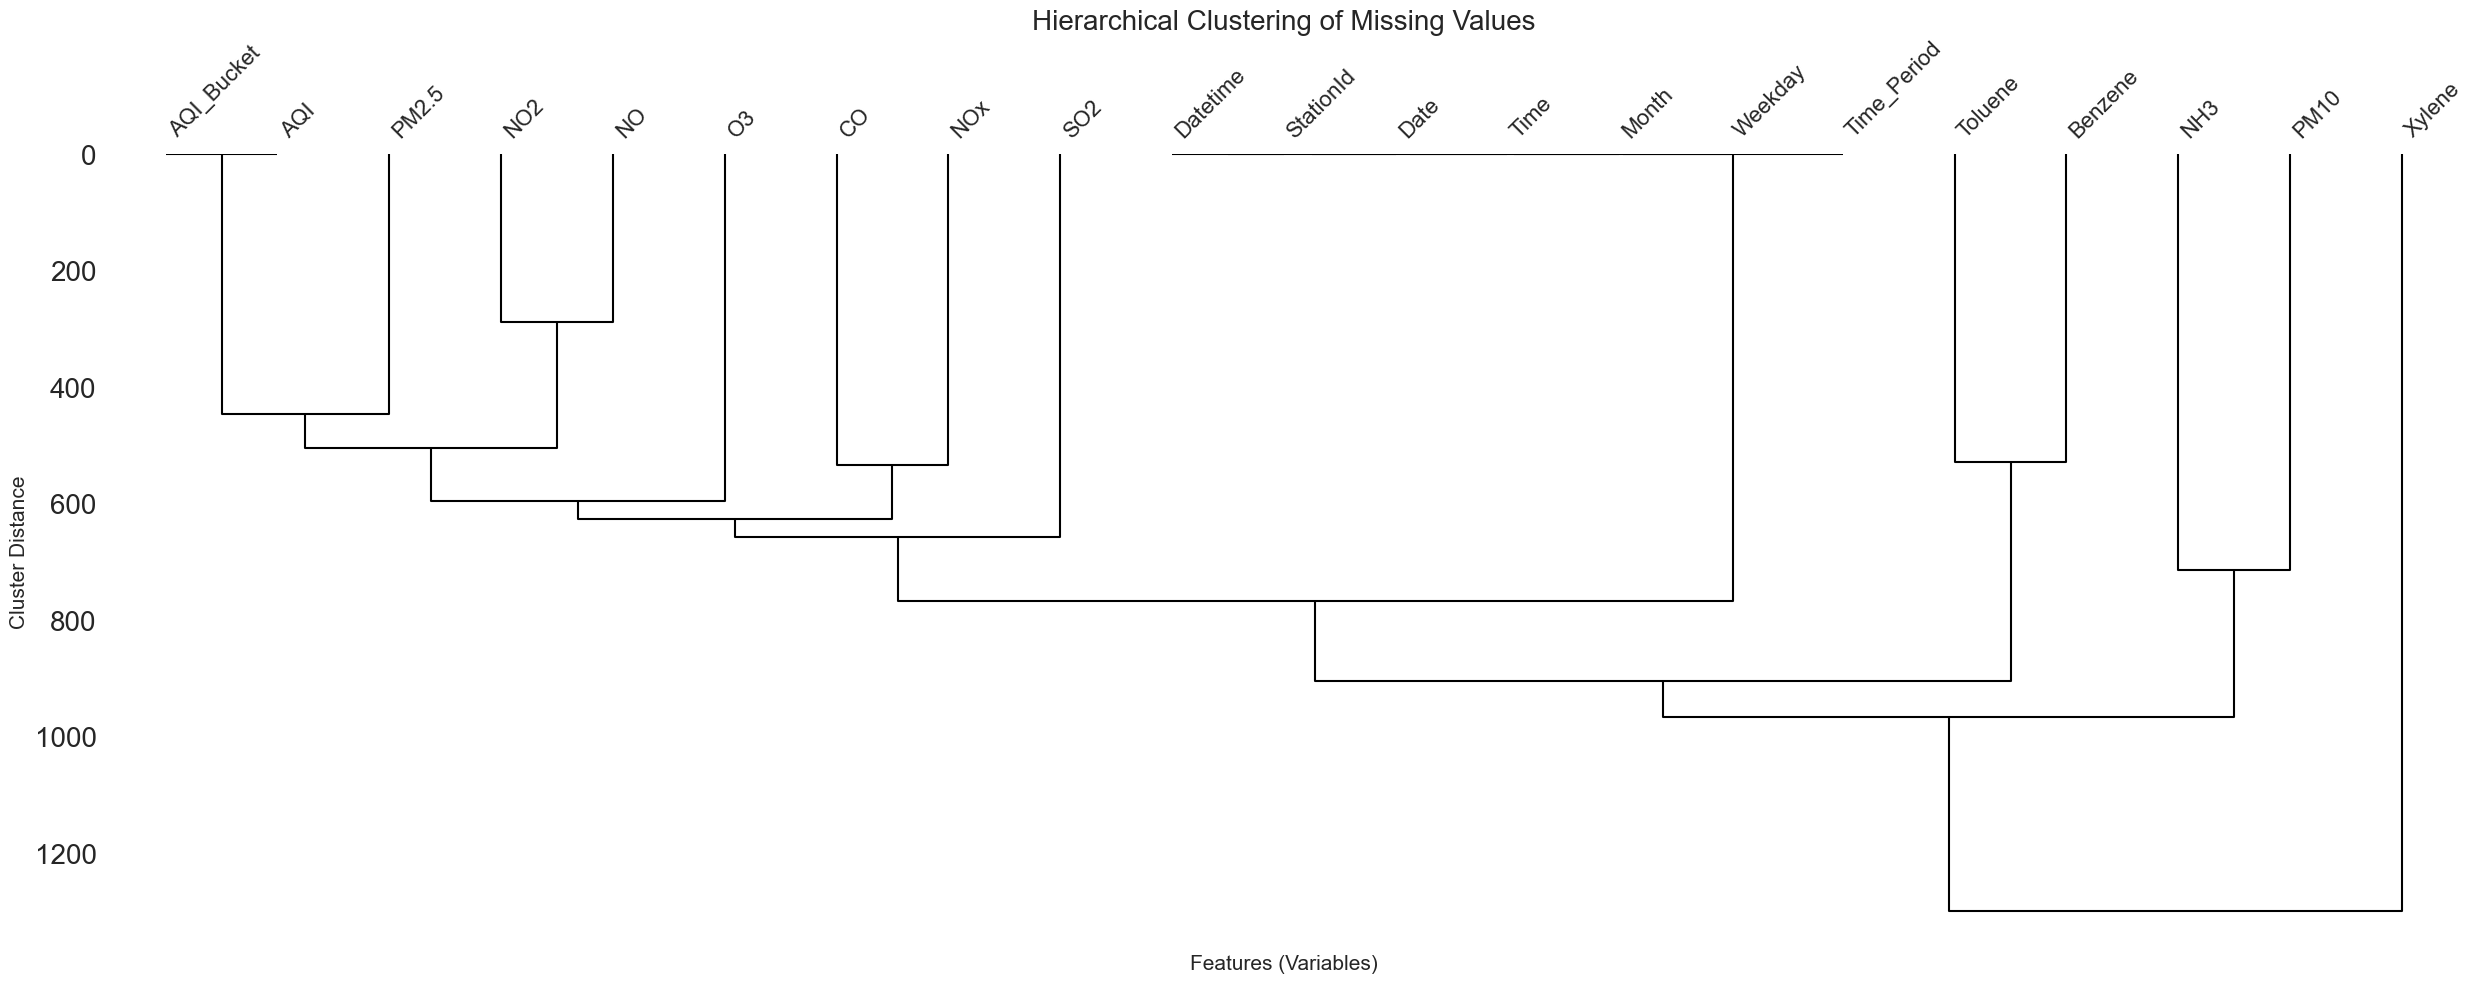

In [213]:
# this graph uses clustering to group variables that have similar missing values pattern
ax = msno.dendrogram(station_hour)

ax.set_title('Hierarchical Clustering of Missing Values', fontsize=20)
ax.set_xlabel('Features (Variables)', fontsize=15)
ax.set_ylabel('Cluster Distance', fontsize=15)

plt.tight_layout()

plt.show()

**Simmilar patterns for missing values based on the dendogram**
- AQI_Bucket & AQI and PM2.5
- NO and NO2
- O3
- NOx and CO
- SO2
- PM10, NH3
- Touene and Benzene
- NH3 and PM10
- Xylene presents the most missing values

Since these variables present similar pattern in missing values, they should be filled in in similar way.

In [214]:
# overview of station dataset to merge with station_hour to have information about stations location (city, state) including status and station name
stations.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [215]:
stations['Status'].value_counts()

Status
Active      131
Inactive      2
Name: count, dtype: int64

In [216]:
station_hour = station_hour.merge(stations, on='StationId', how = 'inner')

In [217]:
station_hour['City'].value_counts()

City
Delhi                 1087388
Bengaluru              287564
Hyderabad              209831
Chennai                153648
Lucknow                146210
Mumbai                 131750
Kolkata                 75717
Jaipur                  74032
Gurugram                67804
Patna                   64031
Ahmedabad               48192
Visakhapatnam           35053
Thiruvananthapuram      29971
Amritsar                29269
Jorapokhar              28025
Amaravati               22784
Brajrajnagar            22468
Talcher                 22161
Guwahati                12002
Coimbatore               9229
Shillong                 7402
Chandigarh               7263
Bhopal                   6903
Kochi                    3854
Ernakulam                3852
Aizawl                   2680
Name: count, dtype: int64

In [218]:
station_hour['State'].value_counts()

State
Delhi             1087388
Karnataka          287564
Telangana          209831
Tamil Nadu         162877
Uttar Pradesh      146210
Maharashtra        131750
West Bengal         75717
Rajasthan           74032
Haryana             67804
Bihar               64031
Andhra Pradesh      57837
Gujarat             48192
Odisha              44629
Kerala              37677
Punjab              29269
Jharkhand           28025
Assam               12002
Meghalaya            7402
Chandigarh           7263
Madhya Pradesh       6903
Mizoram              2680
Name: count, dtype: int64

In [219]:
# exploring missing values for the variable with station status
inactive_stations = pd.DataFrame(station_hour['Status'].isna().groupby([
    station_hour['State'], 
    station_hour['City']
]).sum()).reset_index()

inactive_stations = inactive_stations.rename(columns={'Status':'Number of inactive stations'})
total_records = station_hour.groupby(['State', 'City']).size().reset_index(name='Total Records')
inactive_stations = inactive_stations.merge(
    total_records, 
    on=['State', 'City'], 
    how='left'
)
inactive_stations

,State,City,Number of inactive stations,Total Records
0,Andhra Pradesh,Amaravati,0,22784
1,Andhra Pradesh,Visakhapatnam,0,35053
2,Assam,Guwahati,0,12002
3,Bihar,Patna,0,64031
4,Chandigarh,Chandigarh,0,7263
5,Delhi,Delhi,0,1087388
6,Gujarat,Ahmedabad,0,48192
7,Haryana,Gurugram,0,67804
8,Jharkhand,Jorapokhar,0,28025
9,Karnataka,Bengaluru,0,287564


**Inactive stations are located in same state, in different cities. We need to check if these stations track the emissios or not**

In [220]:
station_hour[station_hour['City'].isin(('Ernakulam', 'Kochi'))].head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI_Bucket,Date,Time,Month,Weekday,Time_Period,StationName,City,State,Status
1660106,KL002,2020-01-22 13:00:00,33.83,78.25,130.28,7.63,137.91,103.77,2.02,NaN,...,NaN,2020-01-22,13,1,2,Day,"Kacheripady, Ernakulam - Kerala PCB",Ernakulam,Kerala,NaN
1660107,KL002,2020-01-22 14:00:00,41.00,87.00,128.78,7.77,136.52,102.78,2.10,NaN,...,NaN,2020-01-22,14,1,2,Day,"Kacheripady, Ernakulam - Kerala PCB",Ernakulam,Kerala,NaN
1660108,KL002,2020-01-22 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2020-01-22,15,1,2,Day,"Kacheripady, Ernakulam - Kerala PCB",Ernakulam,Kerala,NaN
1660109,KL002,2020-01-22 16:00:00,40.10,83.36,125.70,7.90,133.62,100.35,1.78,3.35,...,NaN,2020-01-22,16,1,2,Day,"Kacheripady, Ernakulam - Kerala PCB",Ernakulam,Kerala,NaN
1660110,KL002,2020-01-22 17:00:00,35.00,74.00,126.47,7.76,134.24,100.99,1.84,3.33,...,NaN,2020-01-22,17,1,2,Day,"Kacheripady, Ernakulam - Kerala PCB",Ernakulam,Kerala,NaN


**There are inactive stations in Kerala state in cities Ernakulam and Kochi, however they still provide records for emissions. Therefore, for these stations we may fill in missing values as `active`**

In [221]:
station_hour['Status'] = station_hour['Status'].fillna('active')

#### Missing values overview emissions

Exploring missing values and its time patterns to understand and reveal nature of missing data

In [222]:
# creating boolean values with informatio about missing values for summary table and visualization
station_hour.loc[:,'PM2.5_is_zero'] = (station_hour['PM2.5'].isna())

station_hour.loc[:,'NO_is_zero'] = (station_hour['NO'].isna())
station_hour.loc[:,'NO2_is_zero'] = (station_hour['NO2'].isna())

station_hour.loc[:,'O3_is_zero'] = (station_hour['O3'].isna())

station_hour.loc[:,'CO_is_zero'] = (station_hour['CO'].isna())
station_hour.loc[:,'NOx_is_zero'] = (station_hour['NOx'].isna())

station_hour.loc[:,'SO2_is_zero'] = (station_hour['SO2'].isna())

station_hour.loc[:,'Toluene_is_zero'] = (station_hour['Toluene'].isna())
station_hour.loc[:,'Benzene_is_zero'] = (station_hour['Benzene'].isna())

station_hour.loc[:,'PM10_is_zero'] = (station_hour['PM10'].isna())
station_hour.loc[:,'NH3_is_zero'] = (station_hour['NH3'].isna())

station_hour.loc[:,'Xylene_is_zero'] = (station_hour['Xylene'].isna())

In [223]:
# summary table representing dynamics of missing values for each emission in time
zeros_by_datetime = station_hour.groupby('Datetime')[['PM2.5_is_zero', 'NO_is_zero', 'NO2_is_zero', 'O3_is_zero', 'NOx_is_zero', 'CO_is_zero', 'SO2_is_zero',
                                                     'Toluene_is_zero', 'Benzene_is_zero', 'PM10_is_zero', 'NH3_is_zero', 'Xylene_is_zero']].sum()
zeros_by_datetime = zeros_by_datetime.reset_index()
zeros_by_datetime.head()

,Datetime,PM2.5_is_zero,NO_is_zero,NO2_is_zero,O3_is_zero,NOx_is_zero,CO_is_zero,SO2_is_zero,Toluene_is_zero,Benzene_is_zero,PM10_is_zero,NH3_is_zero,Xylene_is_zero
0,2015-01-01 01:00:00,12,2,1,5,0,4,4,6,5,13,10,11
1,2015-01-01 02:00:00,12,3,2,6,1,5,5,7,7,14,10,11
2,2015-01-01 03:00:00,12,2,2,7,1,4,5,7,7,14,10,11
3,2015-01-01 04:00:00,12,2,2,6,1,6,5,7,7,14,10,11
4,2015-01-01 05:00:00,12,2,2,7,1,4,5,7,7,13,10,11


In [224]:
# creating time variables(date, hour, month, weekday, time period) to explore missing values in different time dimensions
zeros_by_datetime['Date'] = zeros_by_datetime['Datetime'].dt.date

zeros_by_datetime['Hour'] = zeros_by_datetime['Datetime'].dt.hour

zeros_by_datetime['Month'] = zeros_by_datetime['Datetime'].dt.month

zeros_by_datetime['Weekday'] = zeros_by_datetime['Datetime'].dt.weekday

bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Day', 'Evening']
zeros_by_datetime['Time_Period'] = pd.cut(zeros_by_datetime['Hour'], bins=bins, labels=labels, right=False, include_lowest=True)

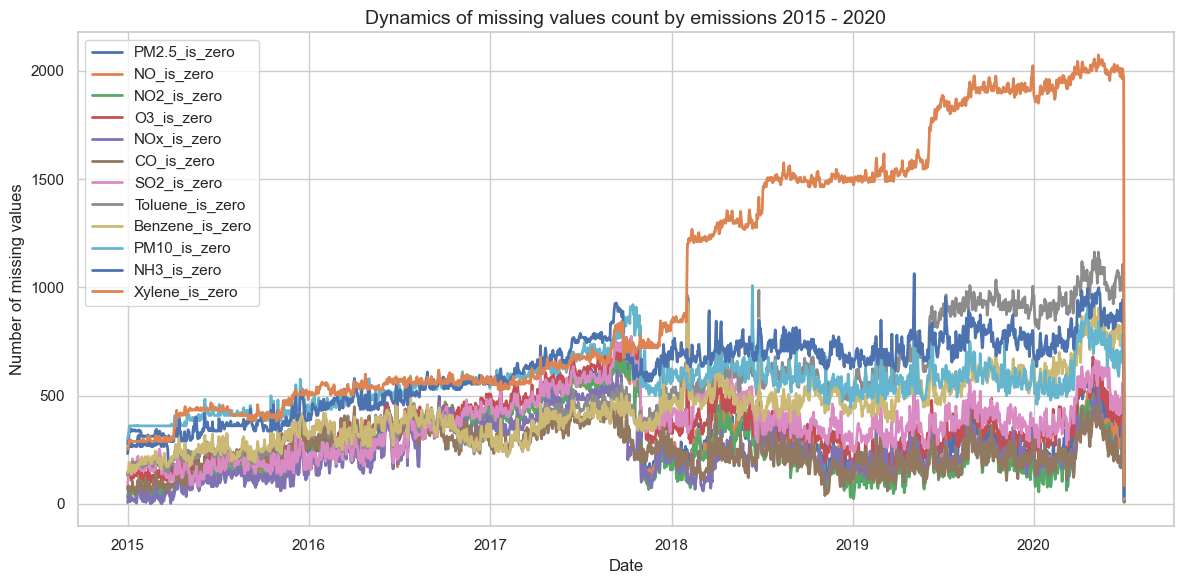

In [225]:
# visualizing missing values dynamics for date timeline for each emission
plt.figure(figsize=(12, 6))

df_plot = zeros_by_datetime.drop(columns=['Datetime', 'Hour', 'Month', 'Weekday', 'Time_Period'])

df_plot = pd.DataFrame(df_plot.groupby('Date').sum()).reset_index()
df_plot = df_plot.set_index('Date')

df_plot.plot(ax=plt.gca(), linewidth=2)

plt.title('Dynamics of missing values count by emissions 2015 - 2020', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of missing values')
plt.tight_layout()
plt.show()

***
- **In general, number of missing values has increased significantly in 2018, primarily because of the Xylene**
- **However, there is a positive trend in number of missing values increase over time**

In [226]:
#creating auxiliary datasets for exploring missing values dynamics in other time dimensions
#dataset with number of missing values for each month 
zeros_by_month = pd.DataFrame(zeros_by_datetime.groupby('Month')[['PM2.5_is_zero', 'NO_is_zero', 'NO2_is_zero', 'O3_is_zero', 'NOx_is_zero', 'CO_is_zero', 'SO2_is_zero',
                                                     'Toluene_is_zero', 'Benzene_is_zero', 'PM10_is_zero', 'NH3_is_zero', 'Xylene_is_zero']].sum()).reset_index()
zeros_by_month = zeros_by_month.set_index('Month')

#dataset with number of missing values for each weekday
zeros_by_weekday = pd.DataFrame(zeros_by_datetime.groupby('Weekday')[['PM2.5_is_zero', 'NO_is_zero', 'NO2_is_zero', 'O3_is_zero', 'NOx_is_zero', 'CO_is_zero', 'SO2_is_zero',
                                                     'Toluene_is_zero', 'Benzene_is_zero', 'PM10_is_zero', 'NH3_is_zero', 'Xylene_is_zero']].sum()).reset_index()
zeros_by_weekday = zeros_by_weekday.set_index('Weekday')

#dataset with number of missing values for each time period (night, morning, afternoon, evening)
zeros_by_time_period = pd.DataFrame(zeros_by_datetime.groupby('Time_Period')[['PM2.5_is_zero', 'NO_is_zero', 'NO2_is_zero', 'O3_is_zero', 'NOx_is_zero', 'CO_is_zero', 'SO2_is_zero',
                                                     'Toluene_is_zero', 'Benzene_is_zero', 'PM10_is_zero', 'NH3_is_zero', 'Xylene_is_zero']].sum()).reset_index()
zeros_by_time_period = zeros_by_time_period.set_index('Time_Period')

#dataset with number of missing values for each hour
zeros_by_hour = pd.DataFrame(zeros_by_datetime.groupby('Hour')[['PM2.5_is_zero', 'NO_is_zero', 'NO2_is_zero', 'O3_is_zero', 'NOx_is_zero', 'CO_is_zero', 'SO2_is_zero',
                                                     'Toluene_is_zero', 'Benzene_is_zero', 'PM10_is_zero', 'NH3_is_zero', 'Xylene_is_zero']].sum()).reset_index()
zeros_by_hour = zeros_by_hour.set_index('Hour')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32908\4232406089.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



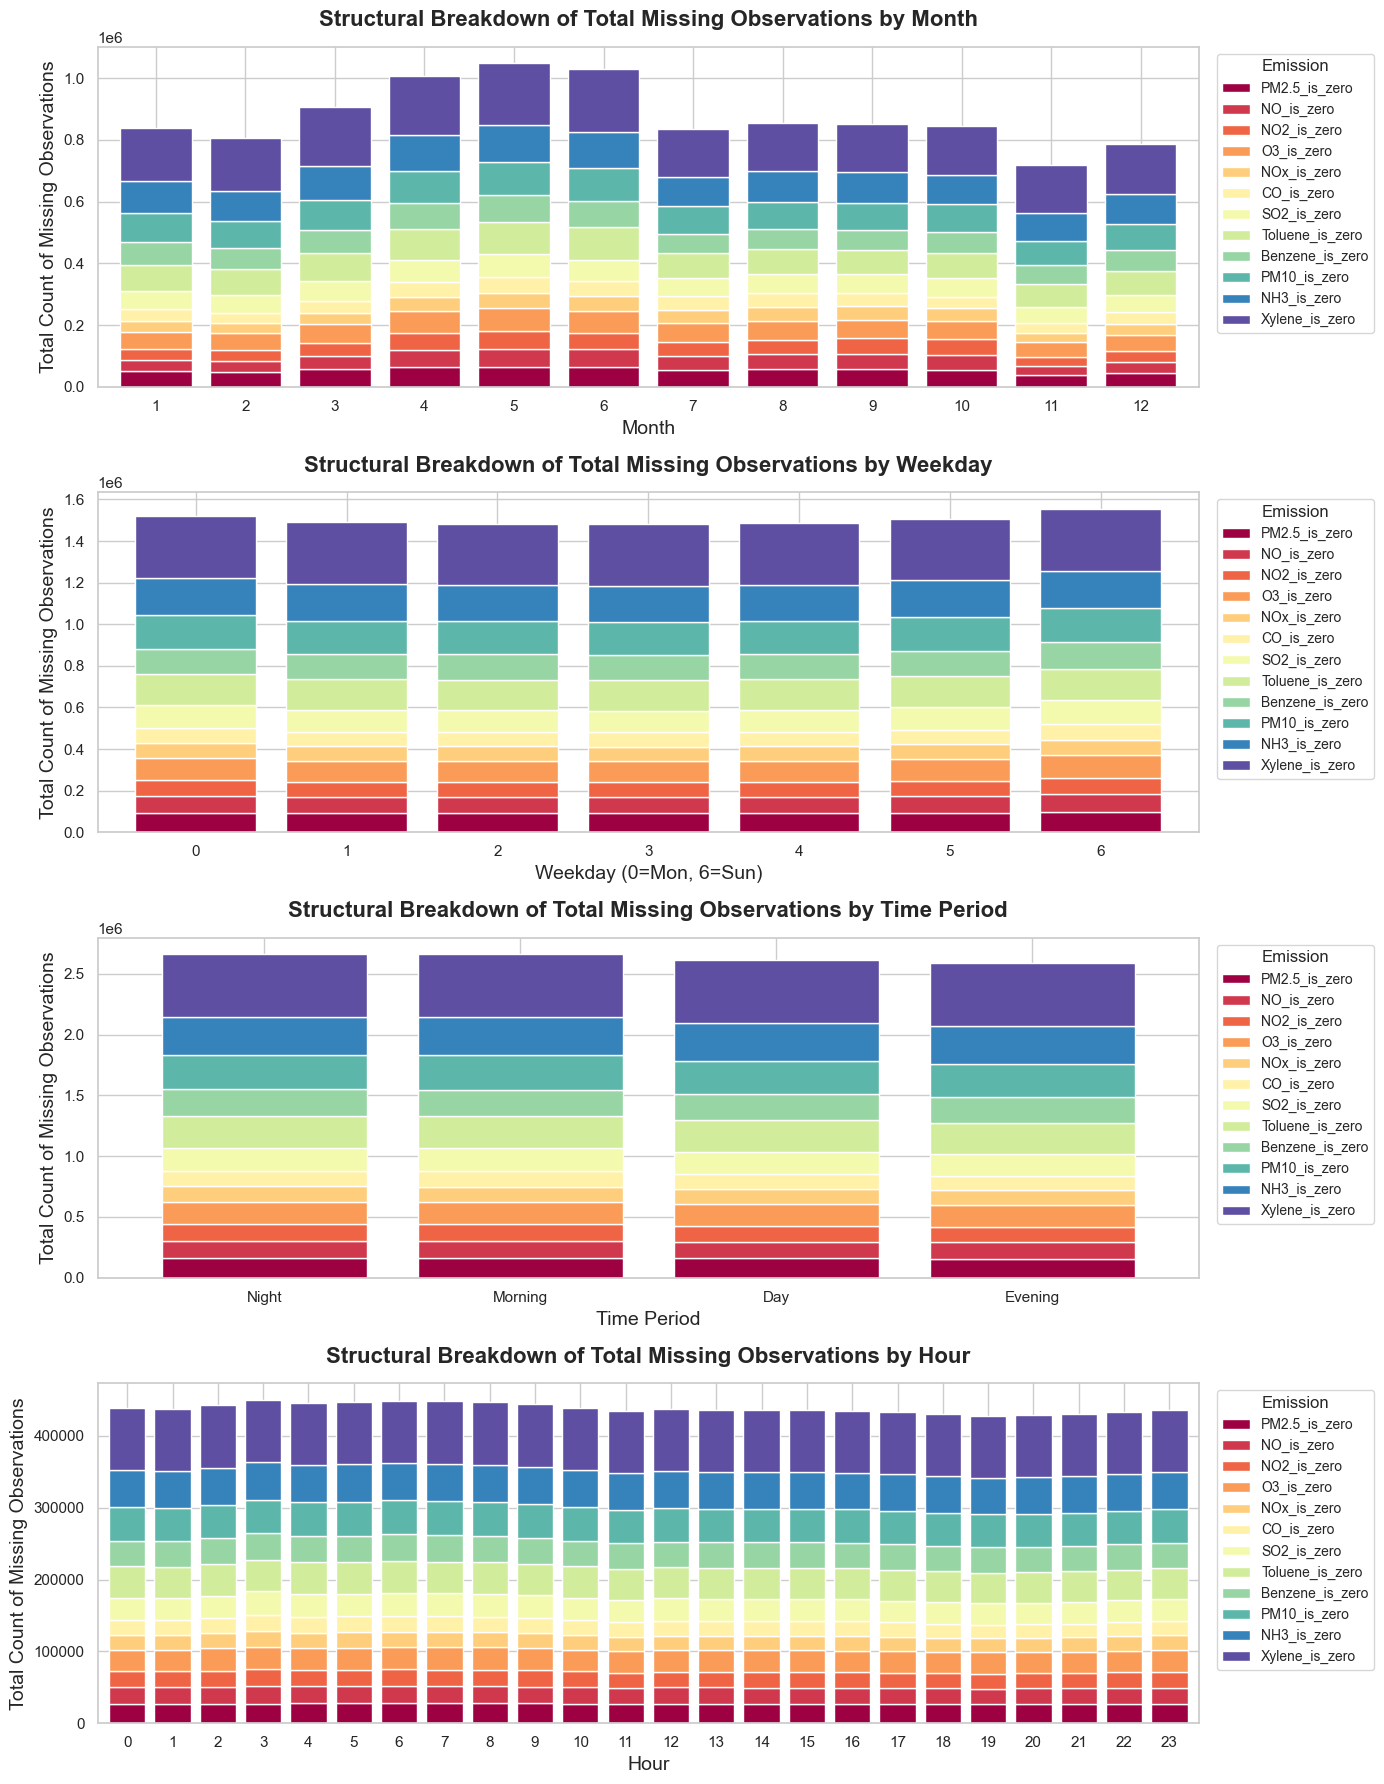

In [227]:
#graph for visualizing missing values dynamics for different time dimensions
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    nrows=4, 
    ncols=1, 
    figsize=(14, 18)
)

# Flatten the axes array for easier indexing (axes[0], axes[1], etc.)
axes = axes.flatten() 

# --- PLOT 1: MISSING VALUES BY MONTH (axes[0]) ---
zeros_by_month.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[0],
    colormap='Spectral',
    width=0.8
)

axes[0].set_title(
    'Structural Breakdown of Total Missing Observations by Month',
    fontsize=16, 
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel('Month', fontsize=14)
axes[0].set_ylabel('Total Count of Missing Observations', fontsize=14)
axes[0].tick_params(axis='x', rotation=0)

axes[0].legend(
    title='Emission', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 1),
    frameon=True, 
    ncol=1, 
    fontsize=10
)

# --- PLOT 2: MISSING VALUES BY WEEKDAY (axes[1]) ---
zeros_by_weekday.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1],
    colormap='Spectral',
    width=0.8
)

axes[1].set_title(
    'Structural Breakdown of Total Missing Observations by Weekday',
    fontsize=16, 
    fontweight='bold',
    pad=15
)
axes[1].set_xlabel('Weekday (0=Mon, 6=Sun)', fontsize=14)
axes[1].set_ylabel('Total Count of Missing Observations', fontsize=14)
axes[1].tick_params(axis='x', rotation=0)

axes[1].legend(
    title='Emission', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 1),
    frameon=True, 
    ncol=1, 
    fontsize=10
)

# --- PLOT 3: MISSING VALUES BY TIME PERIOD (axes[2]) ---
zeros_by_time_period.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[2],
    colormap='Spectral',
    width=0.8
)

axes[2].set_title(
    'Structural Breakdown of Total Missing Observations by Time Period',
    fontsize=16, 
    fontweight='bold',
    pad=15
)
axes[2].set_xlabel('Time Period', fontsize=14)
axes[2].set_ylabel('Total Count of Missing Observations', fontsize=14)
axes[2].tick_params(axis='x', rotation=0)

axes[2].legend(
    title='Emission', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 1),
    frameon=True, 
    ncol=1, 
    fontsize=10
)

# --- PLOT 4: MISSING VALUES BY HOUR (axes[3]) ---
zeros_by_hour.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[3],
    colormap='Spectral',
    width=0.8
)

axes[3].set_title(
    'Structural Breakdown of Total Missing Observations by Hour',
    fontsize=16, 
    fontweight='bold',
    pad=15
)
axes[3].set_xlabel('Hour', fontsize=14)
axes[3].set_ylabel('Total Count of Missing Observations', fontsize=14)
axes[3].tick_params(axis='x', rotation=0)

axes[3].legend(
    title='Emission', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 1),
    frameon=True, 
    ncol=1, 
    fontsize=10
)

plt.tight_layout()
plt.show()

**There is no temporal dependency in terms of Date, Month, Weekday, Time Period, Hour, since count are relatively equally distributed for these time variables.**

Start working on missing values with emissions. So that later we can calculate missing values in AQI and AQI_bucket based on the emissions tracked.

#### Strategy for filling in missing values (Ekaterina)

In [228]:
station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,NO2_is_zero,O3_is_zero,CO_is_zero,NOx_is_zero,SO2_is_zero,Toluene_is_zero,Benzene_is_zero,PM10_is_zero,NH3_is_zero,Xylene_is_zero
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,...,False,False,False,False,False,False,False,False,False,False
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,...,False,False,False,False,False,False,False,False,False,False
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,...,False,False,False,False,False,False,False,False,False,False
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,...,False,False,False,False,False,False,False,False,False,False
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,...,False,False,False,False,False,False,False,False,False,False


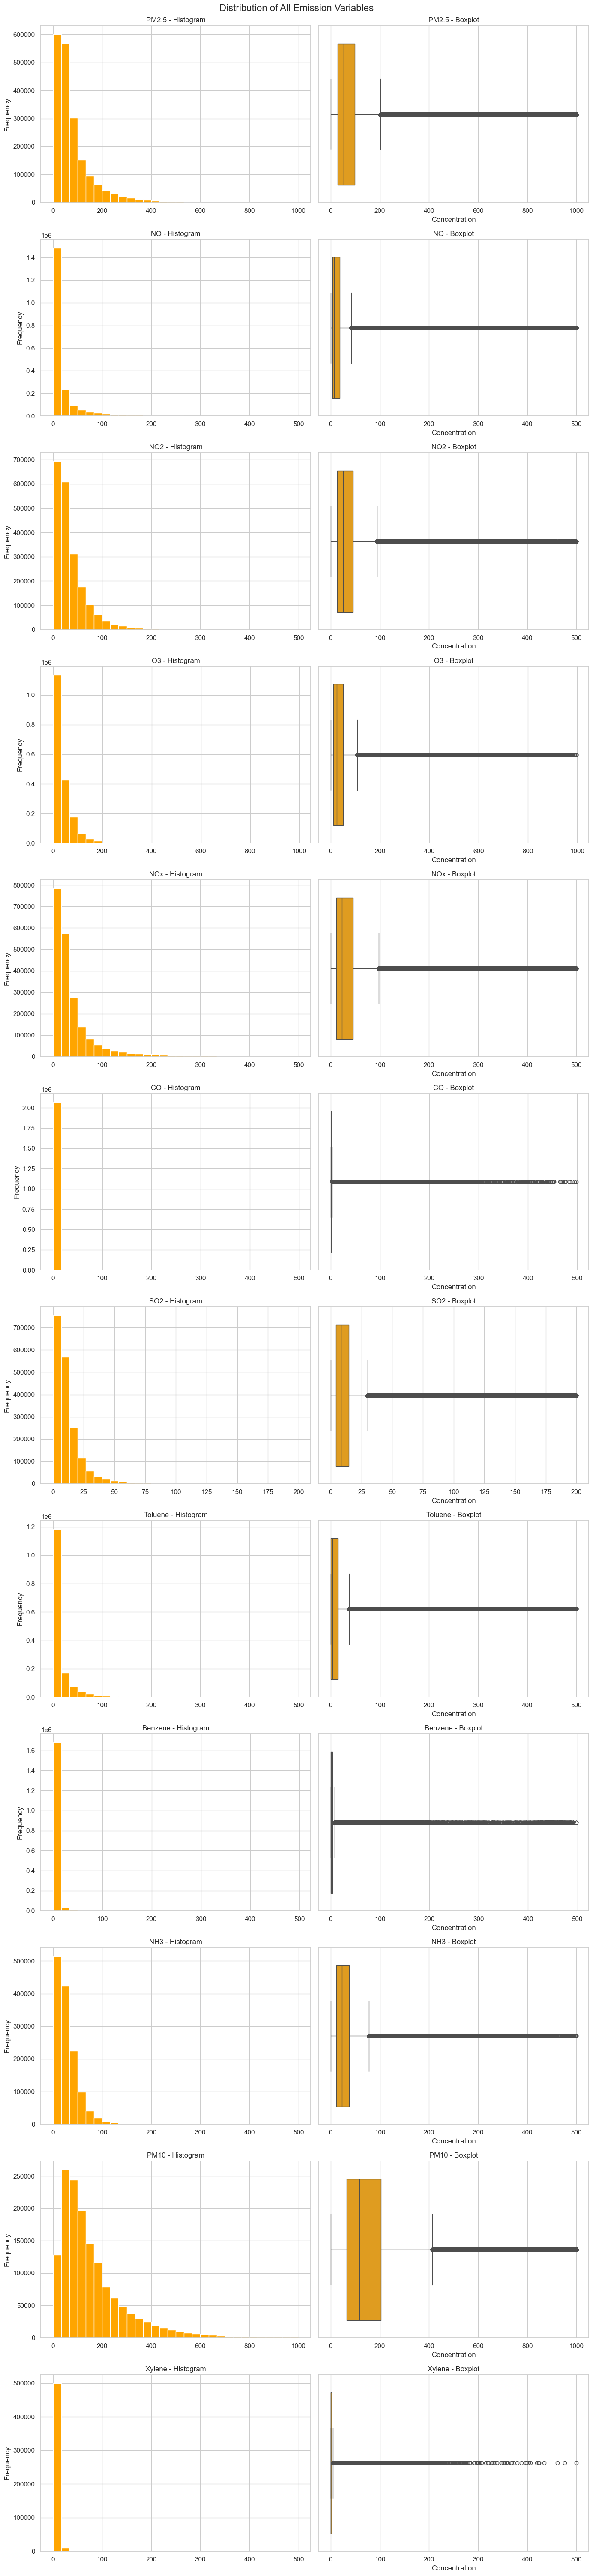

In [229]:
pollutants = ['PM2.5', 'NO', 'NO2', 'O3', 'NOx', 'CO', 'SO2', 'Toluene', 'Benzene', 'NH3', 'PM10', 'Xylene']

# Creating graph with subplots
fig, axes = plt.subplots(nrows=len(pollutants), ncols=2, figsize=(14, 5 * len(pollutants)))

for i, col in enumerate(pollutants):
    # 1. Histogram (Left)
    station_hour[col].hist(ax=axes[i, 0], edgecolor='white', color='orange', bins=30)
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].set_ylabel('Frequency')
    
    # 2. Boxplot (Right)
    sns.boxplot(x=station_hour[col], ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'{col} - Boxplot')
    axes[i, 1].set_xlabel('Concentration')

plt.tight_layout()
plt.suptitle('Distribution of All Emission Variables', y=1.002, fontsize=16)
plt.show()

**For variables**
- There is high volatility of the data
- There are a lot of outliers
- No special time- or spatial- dependencies (na values are relatively equally destributed among states, cities and temporal variables)
Therefore, to fill in the missing values it is better to use median value typical for specific station 

In [230]:
#cheking number of missing values remaining for each variable
print(f"Number of missing values for PM2.5 emissions {station_hour['PM2.5'].isna().sum()}")

print(f"Number of missing values for NO emissions {station_hour['NO'].isna().sum()}")
print(f"Number of missing values for NO2 emissions {station_hour['NO2'].isna().sum()}")

print(f"Number of missing values for O3 emissions {station_hour['O3'].isna().sum()}")

print(f"Number of missing values for NOx emissions {station_hour['NOx'].isna().sum()}")
print(f"Number of missing values for CO emissions {station_hour['CO'].isna().sum()}")

print(f"Number of missing values for SO2 emissions {station_hour['SO2'].isna().sum()}")

print(f"Number of missing values for Toluene emissions {station_hour['Toluene'].isna().sum()}")
print(f"Number of missing values for Benzene emissions {station_hour['Benzene'].isna().sum()}")

print(f"Number of missing values for PM10 emissions {station_hour['PM10'].isna().sum()}")
print(f"Number of missing values for NH3 emissions {station_hour['NH3'].isna().sum()}")

Number of missing values for PM2.5 emissions 647689
Number of missing values for NO emissions 553711
Number of missing values for NO2 emissions 528973
Number of missing values for O3 emissions 725973
Number of missing values for NOx emissions 490808
Number of missing values for CO emissions 499302
Number of missing values for SO2 emissions 742737
Number of missing values for Toluene emissions 1042366
Number of missing values for Benzene emissions 861579
Number of missing values for PM10 emissions 1119252
Number of missing values for NH3 emissions 1236618


In [231]:
#station_hour = station_hour.sort_values(by=['StationId', 'Datetime'])
station_hour = station_hour.set_index('Datetime')

cols_to_fix = ['PM2.5', 'NO', 'NO2', 'O3', 'NOx', 'CO', 'SO2', 'Toluene', 'Benzene', 'PM10', 'NH3']

for col in cols_to_fix:
    if col in station_hour.columns:
        station_hour[col] = station_hour.groupby('StationId')[col].transform(
            lambda x: x.interpolate(method='time', limit=3)
        )

station_hour = station_hour.reset_index()

In [232]:
station_hour = station_hour.sort_values(['StationId', 'Datetime'])

for col in cols_to_fix:
    if col not in station_hour.columns:
        continue

    # 1st layer: time linear intepolation
    station_hour[col] = station_hour.groupby('StationId')[col].ffill(limit=6)

    # 2nd layer: Historical lags
    # Fill with value from 24 hours ago (Daily Cycle)
    station_hour[col] = station_hour[col].fillna(
        station_hour.groupby('StationId')[col].shift(24)
    )
    
    # Fill with value from 168 hours ago (Weekly Cycle)
    station_hour[col] = station_hour[col].fillna(
        station_hour.groupby('StationId')[col].shift(168)
    )
    
    # Fill with Station's Monthly Average for that specific hour
    station_hour[col] = station_hour[col].fillna(
        station_hour.groupby(['StationId', 'Month', 'Time'])[col].transform('median')
    )

In [233]:
# 3rd layer: Spacial imputation
# City Median
if 'City' in station_hour.columns:
    for col in cols_to_fix:
        if col in station_hour.columns:
            station_hour[col] = station_hour[col].fillna(
                station_hour.groupby(['City', 'Datetime'])[col].transform('median')
            )

# State Median
if 'State' in station_hour.columns:
    for col in cols_to_fix:
        if col in station_hour.columns:
            station_hour[col] = station_hour[col].fillna(
                station_hour.groupby(['State', 'Datetime'])[col].transform('median')
            )

# 4th layer: Global Median
for col in cols_to_fix:
    if col in station_hour.columns:
        station_hour[col] = station_hour[col].fillna(station_hour[col].median())

In [234]:
#cheking number of missing values remaining for each variable
print(f"Number of missing values for PM2.5 emissions {station_hour['PM2.5'].isna().sum()}")

print(f"Number of missing values for NO emissions {station_hour['NO'].isna().sum()}")
print(f"Number of missing values for NO2 emissions {station_hour['NO2'].isna().sum()}")

print(f"Number of missing values for O3 emissions {station_hour['O3'].isna().sum()}")

print(f"Number of missing values for NOx emissions {station_hour['NOx'].isna().sum()}")
print(f"Number of missing values for CO emissions {station_hour['CO'].isna().sum()}")

print(f"Number of missing values for SO2 emissions {station_hour['SO2'].isna().sum()}")

print(f"Number of missing values for Toluene emissions {station_hour['Toluene'].isna().sum()}")
print(f"Number of missing values for Benzene emissions {station_hour['Benzene'].isna().sum()}")

print(f"Number of missing values for PM10 emissions {station_hour['PM10'].isna().sum()}")
print(f"Number of missing values for NH3 emissions {station_hour['NH3'].isna().sum()}")

Number of missing values for PM2.5 emissions 0
Number of missing values for NO emissions 0
Number of missing values for NO2 emissions 0
Number of missing values for O3 emissions 0
Number of missing values for NOx emissions 0
Number of missing values for CO emissions 0
Number of missing values for SO2 emissions 0
Number of missing values for Toluene emissions 0
Number of missing values for Benzene emissions 0
Number of missing values for PM10 emissions 0
Number of missing values for NH3 emissions 0


In [235]:
missing_values= missing_values_table(station_hour)
missing_values.style.background_gradient(cmap='Reds')

Your selected dataframe has 37 columns.
There are 3 columns that have missing values.


,Missing Values,% of Total Values
Xylene,2075104,80.100000
AQI,570190,22.000000
AQI_Bucket,570190,22.000000


**The variable Xylene contains 80% of missing values, therefore it won't be accurate to impute missing values in this case. Moreover, this pollutant is irrelevant and do not participate in the AQI calculation. Thus, we can drop this variable to continue working with data without creating noise.**

In [236]:
# dropping irrelevat variable `Xylene`
station_hour = station_hour.drop(columns='Xylene')

#### AQI calculation

After filling in missing values for the pollutants, we filling in missing values by simply calculating AQI using the formula.

We calculate AQI using following methodology:

link - https://www.kaggle.com/code/rohanrao/calculating-aqi-air-quality-index-tutorial?scriptVersionId=41199538

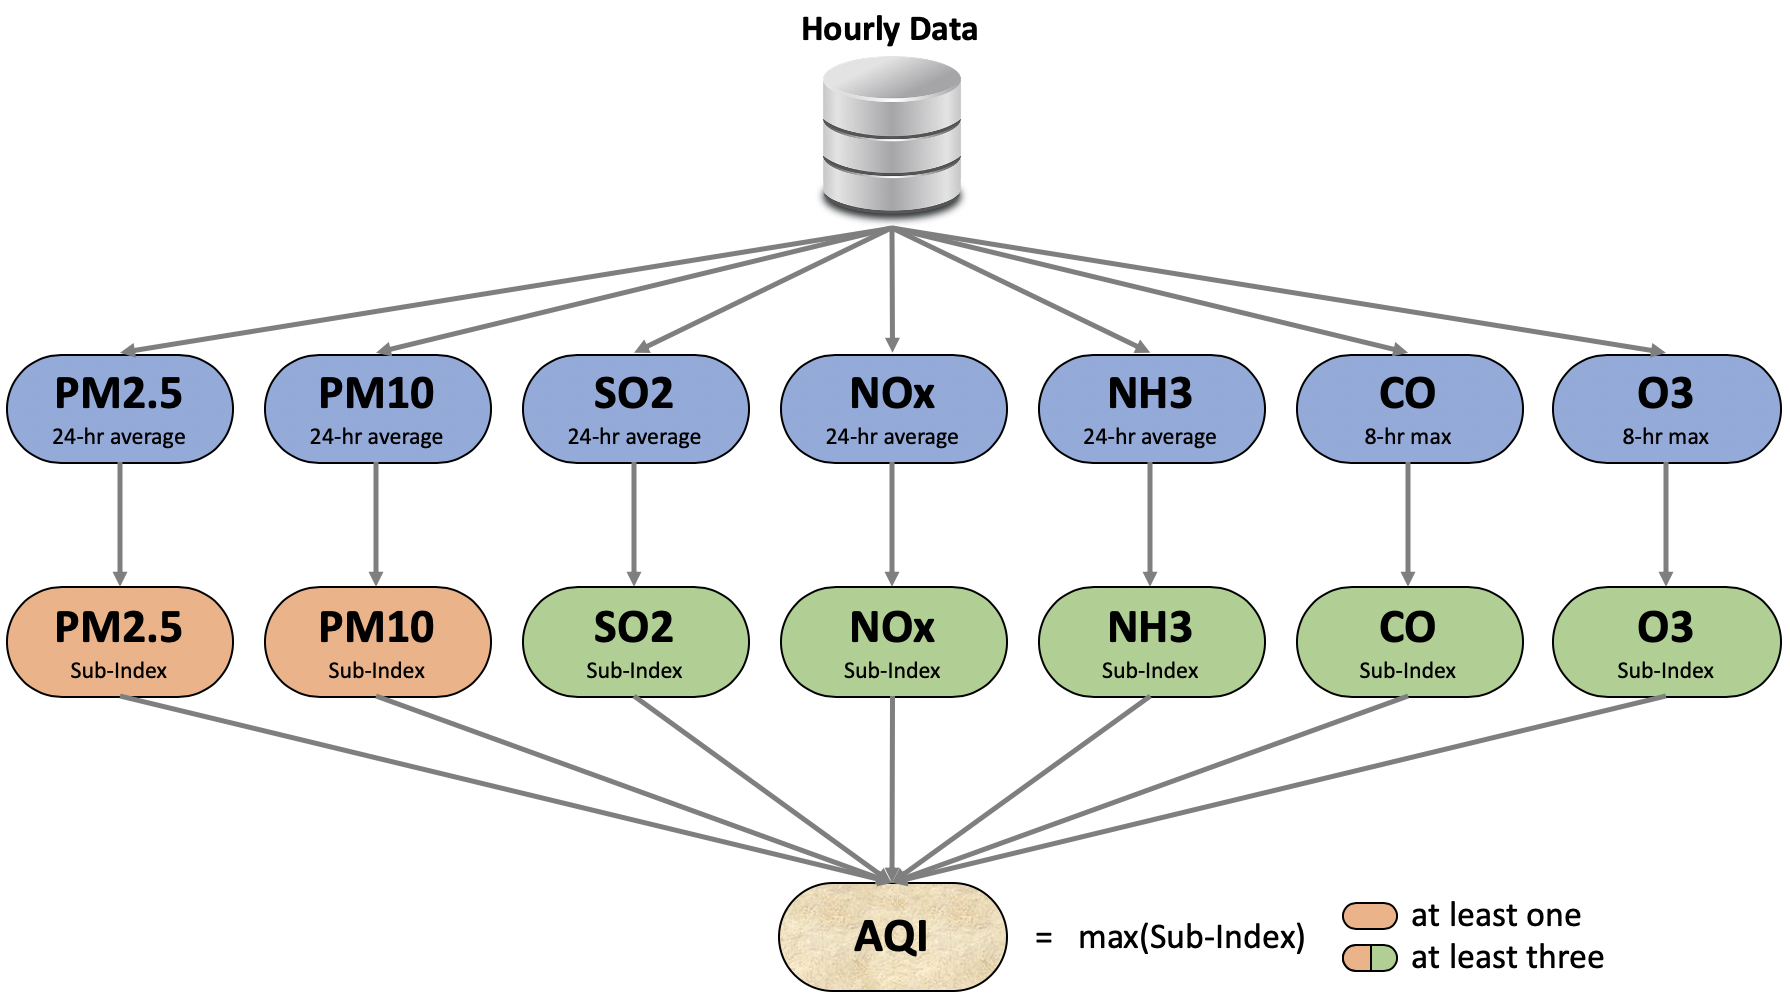

In [237]:
station_hour["PM10_24hr_avg"] = station_hour.groupby("StationId")["PM10"].rolling(window = 24, min_periods = 16).mean().values
station_hour["PM2.5_24hr_avg"] = station_hour.groupby("StationId")["PM2.5"].rolling(window = 24, min_periods = 16).mean().values
station_hour["SO2_24hr_avg"] = station_hour.groupby("StationId")["SO2"].rolling(window = 24, min_periods = 16).mean().values
station_hour["NOx_24hr_avg"] = station_hour.groupby("StationId")["NOx"].rolling(window = 24, min_periods = 16).mean().values
station_hour["NH3_24hr_avg"] = station_hour.groupby("StationId")["NH3"].rolling(window = 24, min_periods = 16).mean().values
station_hour["CO_8hr_max"] = station_hour.groupby("StationId")["CO"].rolling(window = 8, min_periods = 1).max().values
station_hour["O3_8hr_max"] = station_hour.groupby("StationId")["O3"].rolling(window = 8, min_periods = 1).max().values

In [238]:
## PM2.5 Sub-Index calculation
def get_PM25_subindex(x):
    if x <= 30:
        return x * 50 / 30
    elif x <= 60:
        return 50 + (x - 30) * 50 / 30
    elif x <= 90:
        return 100 + (x - 60) * 100 / 30
    elif x <= 120:
        return 200 + (x - 90) * 100 / 30
    elif x <= 250:
        return 300 + (x - 120) * 100 / 130
    elif x > 250:
        return 400 + (x - 250) * 100 / 130
    else:
        return 0

station_hour["PM2.5_SubIndex"] = station_hour["PM2.5_24hr_avg"].apply(lambda x: get_PM25_subindex(x))

In [239]:
## PM10 Sub-Index calculation
def get_PM10_subindex(x):
    if x <= 50:
        return x
    elif x <= 100:
        return x
    elif x <= 250:
        return 100 + (x - 100) * 100 / 150
    elif x <= 350:
        return 200 + (x - 250)
    elif x <= 430:
        return 300 + (x - 350) * 100 / 80
    elif x > 430:
        return 400 + (x - 430) * 100 / 80
    else:
        return 0

station_hour["PM10_SubIndex"] = station_hour["PM10_24hr_avg"].apply(lambda x: get_PM10_subindex(x))

In [240]:
## SO2 Sub-Index calculation
def get_SO2_subindex(x):
    if x <= 40:
        return x * 50 / 40
    elif x <= 80:
        return 50 + (x - 40) * 50 / 40
    elif x <= 380:
        return 100 + (x - 80) * 100 / 300
    elif x <= 800:
        return 200 + (x - 380) * 100 / 420
    elif x <= 1600:
        return 300 + (x - 800) * 100 / 800
    elif x > 1600:
        return 400 + (x - 1600) * 100 / 800
    else:
        return 0

station_hour["SO2_SubIndex"] = station_hour["SO2_24hr_avg"].apply(lambda x: get_SO2_subindex(x))

In [241]:
## NOx Sub-Index calculation
def get_NOx_subindex(x):
    if x <= 40:
        return x * 50 / 40
    elif x <= 80:
        return 50 + (x - 40) * 50 / 40
    elif x <= 180:
        return 100 + (x - 80) * 100 / 100
    elif x <= 280:
        return 200 + (x - 180) * 100 / 100
    elif x <= 400:
        return 300 + (x - 280) * 100 / 120
    elif x > 400:
        return 400 + (x - 400) * 100 / 120
    else:
        return 0

station_hour["NOx_SubIndex"] = station_hour["NOx_24hr_avg"].apply(lambda x: get_NOx_subindex(x))

In [242]:
## NH3 Sub-Index calculation
def get_NH3_subindex(x):
    if x <= 200:
        return x * 50 / 200
    elif x <= 400:
        return 50 + (x - 200) * 50 / 200
    elif x <= 800:
        return 100 + (x - 400) * 100 / 400
    elif x <= 1200:
        return 200 + (x - 800) * 100 / 400
    elif x <= 1800:
        return 300 + (x - 1200) * 100 / 600
    elif x > 1800:
        return 400 + (x - 1800) * 100 / 600
    else:
        return 0

station_hour["NH3_SubIndex"] = station_hour["NH3_24hr_avg"].apply(lambda x: get_NH3_subindex(x))

In [243]:
## CO Sub-Index calculation
def get_CO_subindex(x):
    if x <= 1:
        return x * 50 / 1
    elif x <= 2:
        return 50 + (x - 1) * 50 / 1
    elif x <= 10:
        return 100 + (x - 2) * 100 / 8
    elif x <= 17:
        return 200 + (x - 10) * 100 / 7
    elif x <= 34:
        return 300 + (x - 17) * 100 / 17
    elif x > 34:
        return 400 + (x - 34) * 100 / 17
    else:
        return 0

station_hour["CO_SubIndex"] = station_hour["CO_8hr_max"].apply(lambda x: get_CO_subindex(x))

In [244]:
## O3 Sub-Index calculation
def get_O3_subindex(x):
    if x <= 50:
        return x * 50 / 50
    elif x <= 100:
        return 50 + (x - 50) * 50 / 50
    elif x <= 168:
        return 100 + (x - 100) * 100 / 68
    elif x <= 208:
        return 200 + (x - 168) * 100 / 40
    elif x <= 748:
        return 300 + (x - 208) * 100 / 539
    elif x > 748:
        return 400 + (x - 400) * 100 / 539
    else:
        return 0

station_hour["O3_SubIndex"] = station_hour["O3_8hr_max"].apply(lambda x: get_O3_subindex(x))

In [245]:
def get_AQI_bucket(x):
    if x <= 50:
        return "Good"
    elif x <= 100:
        return "Satisfactory"
    elif x <= 200:
        return "Moderate"
    elif x <= 300:
        return "Poor"
    elif x <= 400:
        return "Very Poor"
    elif x > 400:
        return "Severe"
    else:
        return np.nan

station_hour["Checks"] = (station_hour["PM2.5_SubIndex"] > 0).astype(int) + \
                (station_hour["PM10_SubIndex"] > 0).astype(int) + \
                (station_hour["SO2_SubIndex"] > 0).astype(int) + \
                (station_hour["NOx_SubIndex"] > 0).astype(int) + \
                (station_hour["NH3_SubIndex"] > 0).astype(int) + \
                (station_hour["CO_SubIndex"] > 0).astype(int) + \
                (station_hour["O3_SubIndex"] > 0).astype(int)

station_hour["AQI_calculated"] = round(station_hour[["PM2.5_SubIndex", "PM10_SubIndex", "SO2_SubIndex", "NOx_SubIndex",
                                 "NH3_SubIndex", "CO_SubIndex", "O3_SubIndex"]].max(axis = 1))
station_hour.loc[station_hour["PM2.5_SubIndex"] + station_hour["PM10_SubIndex"] <= 0, "AQI_calculated"] = np.nan
station_hour.loc[station_hour.Checks < 3, "AQI_calculated"] = np.nan

station_hour["AQI_bucket_calculated"] = station_hour["AQI_calculated"].apply(lambda x: get_AQI_bucket(x))

In [246]:
missing_values= missing_values_table(station_hour)
missing_values.style.background_gradient(cmap='Reds')

Your selected dataframe has 53 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
AQI,570190,22.000000
AQI_Bucket,570190,22.000000
PM10_24hr_avg,1650,0.100000
PM2.5_24hr_avg,1650,0.100000
SO2_24hr_avg,1650,0.100000
NOx_24hr_avg,1650,0.100000
NH3_24hr_avg,1650,0.100000
AQI_calculated,1650,0.100000
AQI_bucket_calculated,1650,0.100000


In [247]:
# dropping irrelevant columns 
station_hour = station_hour.drop(columns=['PM10_24hr_avg', 'PM2.5_24hr_avg', 'SO2_24hr_avg', 'NOx_24hr_avg', 'NH3_24hr_avg'])

#### AQI Formula Accuracy Validation

To evaluate the quality of our manual AQI calculation, we compare our results with the station's reference values using a filtered subset of data.

**Filtering Logic ("Valid Validation Set"):**
We only include timestamps where the station had sufficient data for a reliable calculation:
* PM2.5 or PM10 data is available.
* Data exists for at least 3 out of 7 pollutants.
* The station originally calculated the AQI (Target exists).

This allows us to eliminate errors related to missing sensor data and verify the pure mathematical correctness of the formula.

In [248]:
pollutant_flags = [
    'PM2.5_is_zero', 'PM10_is_zero', 'SO2_is_zero', 
    'NOx_is_zero', 'NH3_is_zero', 'CO_is_zero', 'O3_is_zero'
]

# Forming validity conditions according to the methodology (for ORIGINAL data)

# Condition 1: At least one PM (PM2.5 or PM10) is present
condition_pm_present = (~station_hour['PM2.5_is_zero']) | (~station_hour['PM10_is_zero'])

# Condition 2: At least 3 of the 7 indicators are present
# Sum the number (of real data) in the row
present_count = (~station_hour[pollutant_flags]).sum(axis=1)
condition_min_3 = present_count >= 3

# Condition 3: The original AQI must have existed too
condition_aqi_exists = station_hour['AQI'].notna()

# Collecting the "Golden Sample" (Valid Validation Set)
# These are the rows where the AQI was calculated honestly by the station, and the data for this was
valid_mask = condition_pm_present & condition_min_3 & condition_aqi_exists

# Select data for comparison
y_true = station_hour.loc[valid_mask, 'AQI']
y_pred = station_hour.loc[valid_mask, 'AQI_calculated']

# Calculating quality metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"Number of objects for validation: {valid_mask.sum()}")
print(f"R2 Score (accuracy of formula calculation): {r2:.4f}")
print(f"MAE (mean absolute error): {mae:.2f}")

Number of objects for validation: 1964352
R2 Score (accuracy of formula calculation): 0.9539
MAE (mean absolute error): 6.52


**According to the quality metrics the calculated AQI index is highly accurate presenting 95% of R-squared. And in general calculated AQI differs from initial AQI by 7 index points.** 

**The AQI calculation validation was conducted on those data points that were not affected by missing data imputation and were available initially and satisfy AQI calculatio methodology mentioned before.**

In [249]:
# filling in missing values with validated AQI calculation
station_hour['AQI_final'] = station_hour['AQI'].fillna(station_hour['AQI_calculated'])
station_hour['AQI_bucket_final'] = station_hour['AQI_Bucket'].fillna(station_hour['AQI_bucket_calculated'])

In [250]:
missing_values= missing_values_table(station_hour)
missing_values.style.background_gradient(cmap='Reds')

Your selected dataframe has 50 columns.
There are 6 columns that have missing values.


,Missing Values,% of Total Values
AQI,570190,22.000000
AQI_Bucket,570190,22.000000
AQI_calculated,1650,0.100000
AQI_bucket_calculated,1650,0.100000
AQI_final,1650,0.100000
AQI_bucket_final,1650,0.100000


In [251]:
df = station_hour

In [252]:
station_hour = station_hour.drop(columns=['AQI', 'AQI_Bucket', 'AQI_calculated', 'AQI_bucket_calculated'])

# deleting irrelevant columns 
patterns = ['_is_zero', '_max', '_SubIndex']
cols_to_drop = [col for col in df.columns if any(p in col for p in patterns)]
station_hour = station_hour.drop(columns=cols_to_drop)

station_hour = station_hour.drop(columns=['Checks'])

In [253]:
# final dataset and features
station_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 24 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Datetime          datetime64[ns]
 1   StationId         object        
 2   PM2.5             float64       
 3   PM10              float64       
 4   NO                float64       
 5   NO2               float64       
 6   NOx               float64       
 7   NH3               float64       
 8   CO                float64       
 9   SO2               float64       
 10  O3                float64       
 11  Benzene           float64       
 12  Toluene           float64       
 13  Date              object        
 14  Time              int32         
 15  Month             int32         
 16  Weekday           int32         
 17  Time_Period       category      
 18  StationName       object        
 19  City              object        
 20  State             object        
 21  Status  

#### Data Preparation Summary
- *Selection:* Prioritized station_hour (hourly data per station) for granular analysis of pollution profiles and merged it with stations data to add geospatial metadata (City, State, Status).

- *Engineering:* Converted Datetime to objects, extracted temporal features (Date, Time, Month, Weekday), and binned hours into Time_Period (Night, Morning, Day, Evening).

- *Cleaning:* Filled missing Status for 'Ernakulam' and 'Kochi' stations as 'Active'.

#### Missing Value Imputation Strategy
We implemented a **Cascading Imputation Hierarchy**, prioritizing **Temporal (Time)** consistency over **Spatial (Space)** consistency.

---

**The Execution Plan (Hierarchy of Accuracy)**

**Layer 1: The Bridge (Linear & Time Interpolation)**
* **Method:** `interpolate(method='time', limit=3)` followed by `ffill(limit=6)`.
* **Target:** Short gaps (3–6 hours).
* It is the most mathematically accurate method for short sensor dropouts.

**Layer 2: The Rhythm (Historical Lags)**
If the gap is too large for interpolation, we look at the station's history.
1.  **Daily Cycle ($t-24h$):** We fill missing values with the data from the **same hour, yesterday**. This preserves the daily rush-hour/factory patterns.
2.  **Weekly Cycle ($t-168h$):** If yesterday is missing, we use the data from the **same hour, last week**. This accounts for weekly patterns (e.g., lower traffic on Sundays).
3.  **Monthly Hour Mean:** If specific history is missing, we use the station's average for that specific hour in that specific month (e.g., "Average 8 AM in January for Station X").

**Layer 3: The Safety Net (Spatial - City/State)**
If a station has no history (e.g., it is brand new or broken for months), we look at neighbors.
* **Method:** `City Median` $\rightarrow$ `State Median`.
* **Logic:** A station likely behaves similarly to other stations in the same City or State.

**Layer 4: The Nuclear Option (Global)**
* **Method:** Global Median.
* Ensures the dataset has 0 missing values for the forecasting models.


## Explorative Data Analysis (EDA)

*****Exploring which emissions have a significant impact on AQI - Correlation, visualisation and data interpretation*****

In [254]:
emission_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
target_column = 'AQI_final'

emissions_df = station_hour[emission_columns + [target_column]].dropna()  # creating a dataframe with emissions and AQI from station_hour; dropping the missing values
corr_matrix = emissions_df.corr()                                         # buildding the corelation matrix

print("\nCorrelation Matrix for emissions and AQI:")
display(corr_matrix)


Correlation Matrix for emissions and AQI:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI_final
PM2.5,1.000000,0.696280,0.382022,0.362861,0.382367,0.276648,0.082916,0.154157,0.076927,0.115813,0.280585,0.658072
PM10,0.696280,1.000000,0.415917,0.397920,0.444264,0.290460,0.057443,0.177183,0.022665,0.125042,0.332936,0.613836
NO,0.382022,0.415917,1.000000,0.467665,0.842014,0.204759,0.155713,0.121553,-0.037547,0.148249,0.267172,0.319558
NO2,0.362861,0.397920,0.467665,1.000000,0.622595,0.214060,0.139390,0.211121,0.085842,0.110278,0.264085,0.391676
NOx,0.382367,0.444264,0.842014,0.622595,1.000000,0.218234,0.144654,0.161533,0.002966,0.155310,0.263759,0.358152
NH3,0.276648,0.290460,0.204759,0.214060,0.218234,1.000000,0.026005,0.036845,0.046274,0.025274,0.118126,0.249986
CO,0.082916,0.057443,0.155713,0.139390,0.144654,0.026005,1.000000,0.231803,-0.023858,0.065220,0.101356,0.402034
SO2,0.154157,0.177183,0.121553,0.211121,0.161533,0.036845,0.231803,1.000000,0.088403,0.059018,0.147870,0.290087
O3,0.076927,0.022665,-0.037547,0.085842,0.002966,0.046274,-0.023858,0.088403,1.000000,-0.013306,0.039468,0.143754
Benzene,0.115813,0.125042,0.148249,0.110278,0.155310,0.025274,0.065220,0.059018,-0.013306,1.000000,0.386092,0.108079


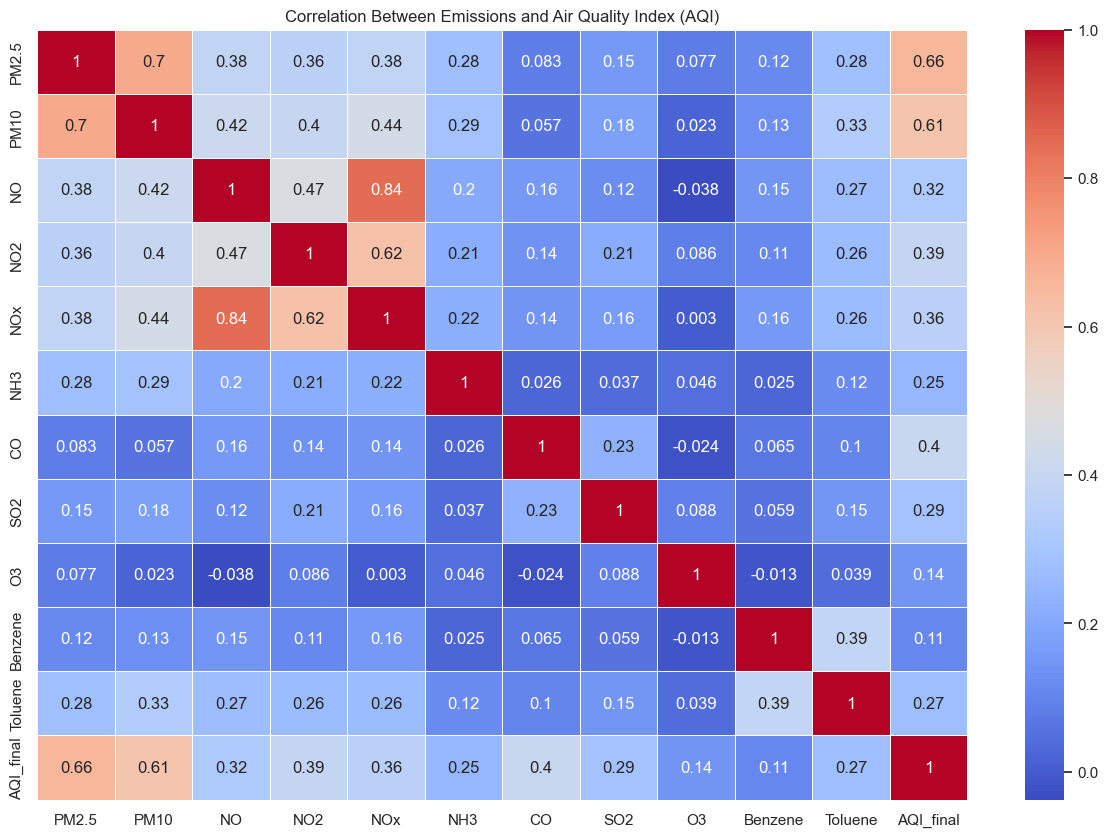

In [255]:
plt.figure(figsize=(15, 10))  #visualisation of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Emissions and Air Quality Index (AQI)")
plt.show()

***Graphic visualisation of correlation between AQI and individual emissions***

When visualizing the correlation between AQI and emissions with raw (unaggregated) data, we observe very large amount of datapoints and noise which distorts the visualisation. This is why below we aggregate the data in order to visualise the correlation between AQI and single emission types more clearly.

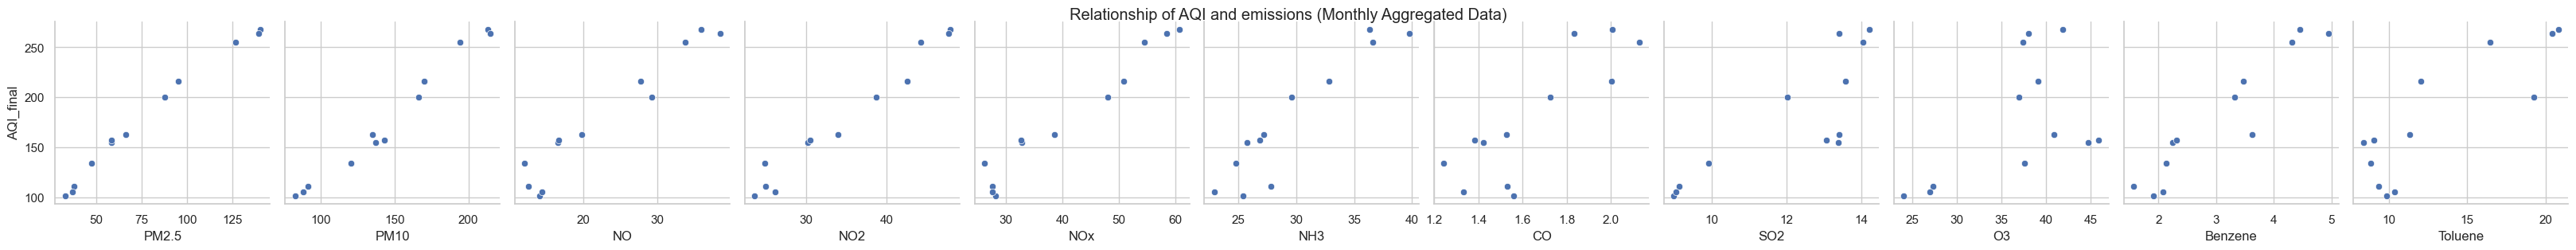

In [256]:
monthly_df = (
    station_hour[emission_columns + [target_column, 'Month']]
    .groupby('Month')
    .mean()
    .reset_index()
)

sns.pairplot(
    monthly_df,
    x_vars=emission_columns,
    y_vars=[target_column],
    height=3
)

plt.suptitle("Relationship of AQI and emissions (Monthly Aggregated Data)", y=1.02)
plt.show()

We aggregated the data on a monthly basis and took the mean values in order to visualise the correlation between individual emissions and AQI more clearly.

The results show a relatively strong correlation between AQI and PM2.5, PM10, a middle strong correlation between AQI and NO2, NOx, CO and relatively week correlation between AQI and Benzene, O3, SO2 and Toluene.

The con of this method is that we summarize many datapoints by taking the mean value. For even better visualisation below, we aggregate the data and group it by month and city in order to use more of the datapoints.

In [257]:
df_sample = station_hour.sample(n=20000, random_state=42)  #selecting 20000 rows to limit number of datapoints
                #random state = int equals same and consistent results each run

In [258]:
df_sample = station_hour.groupby(['City', 'Month'])[['AQI_final',"PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"]].mean().reset_index()
df_sample

,City,Month,AQI_final,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene
0,Ahmedabad,1,479.520234,74.619985,106.845857,22.710421,59.113333,44.580007,24.700000,22.710421,63.609444,43.391795,4.769680,28.021641
1,Ahmedabad,2,550.008333,85.036648,133.583697,28.164668,74.579874,57.899050,24.700000,28.164668,71.822728,44.930386,3.527098,25.029184
2,Ahmedabad,3,430.922043,76.193062,105.071688,17.922769,58.636488,41.933804,24.700000,17.922769,59.475273,45.965090,5.606102,29.150322
3,Ahmedabad,4,332.416667,73.574635,79.503896,12.415635,41.064233,33.095869,24.700000,11.999251,37.863281,39.731478,4.235224,23.622824
4,Ahmedabad,5,248.420475,49.947617,88.221153,9.356896,32.582108,25.275175,24.700000,8.833653,58.827180,36.863754,5.790035,27.714931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,Visakhapatnam,8,89.721102,32.858331,86.773456,13.663496,32.283251,20.869078,11.631410,0.650132,17.069368,18.275411,4.299304,10.921592
289,Visakhapatnam,9,90.287500,35.374730,82.759278,15.507037,32.944181,22.890383,7.976681,0.631619,14.129966,25.132065,3.734823,9.371436
290,Visakhapatnam,10,106.457997,45.243831,96.664834,13.920324,41.425078,26.951628,10.240002,0.672993,15.156848,32.594427,4.045931,9.118739
291,Visakhapatnam,11,122.967361,56.422222,103.467993,9.962499,33.918372,24.024053,10.519051,0.954294,10.706800,62.625473,4.597373,8.856934


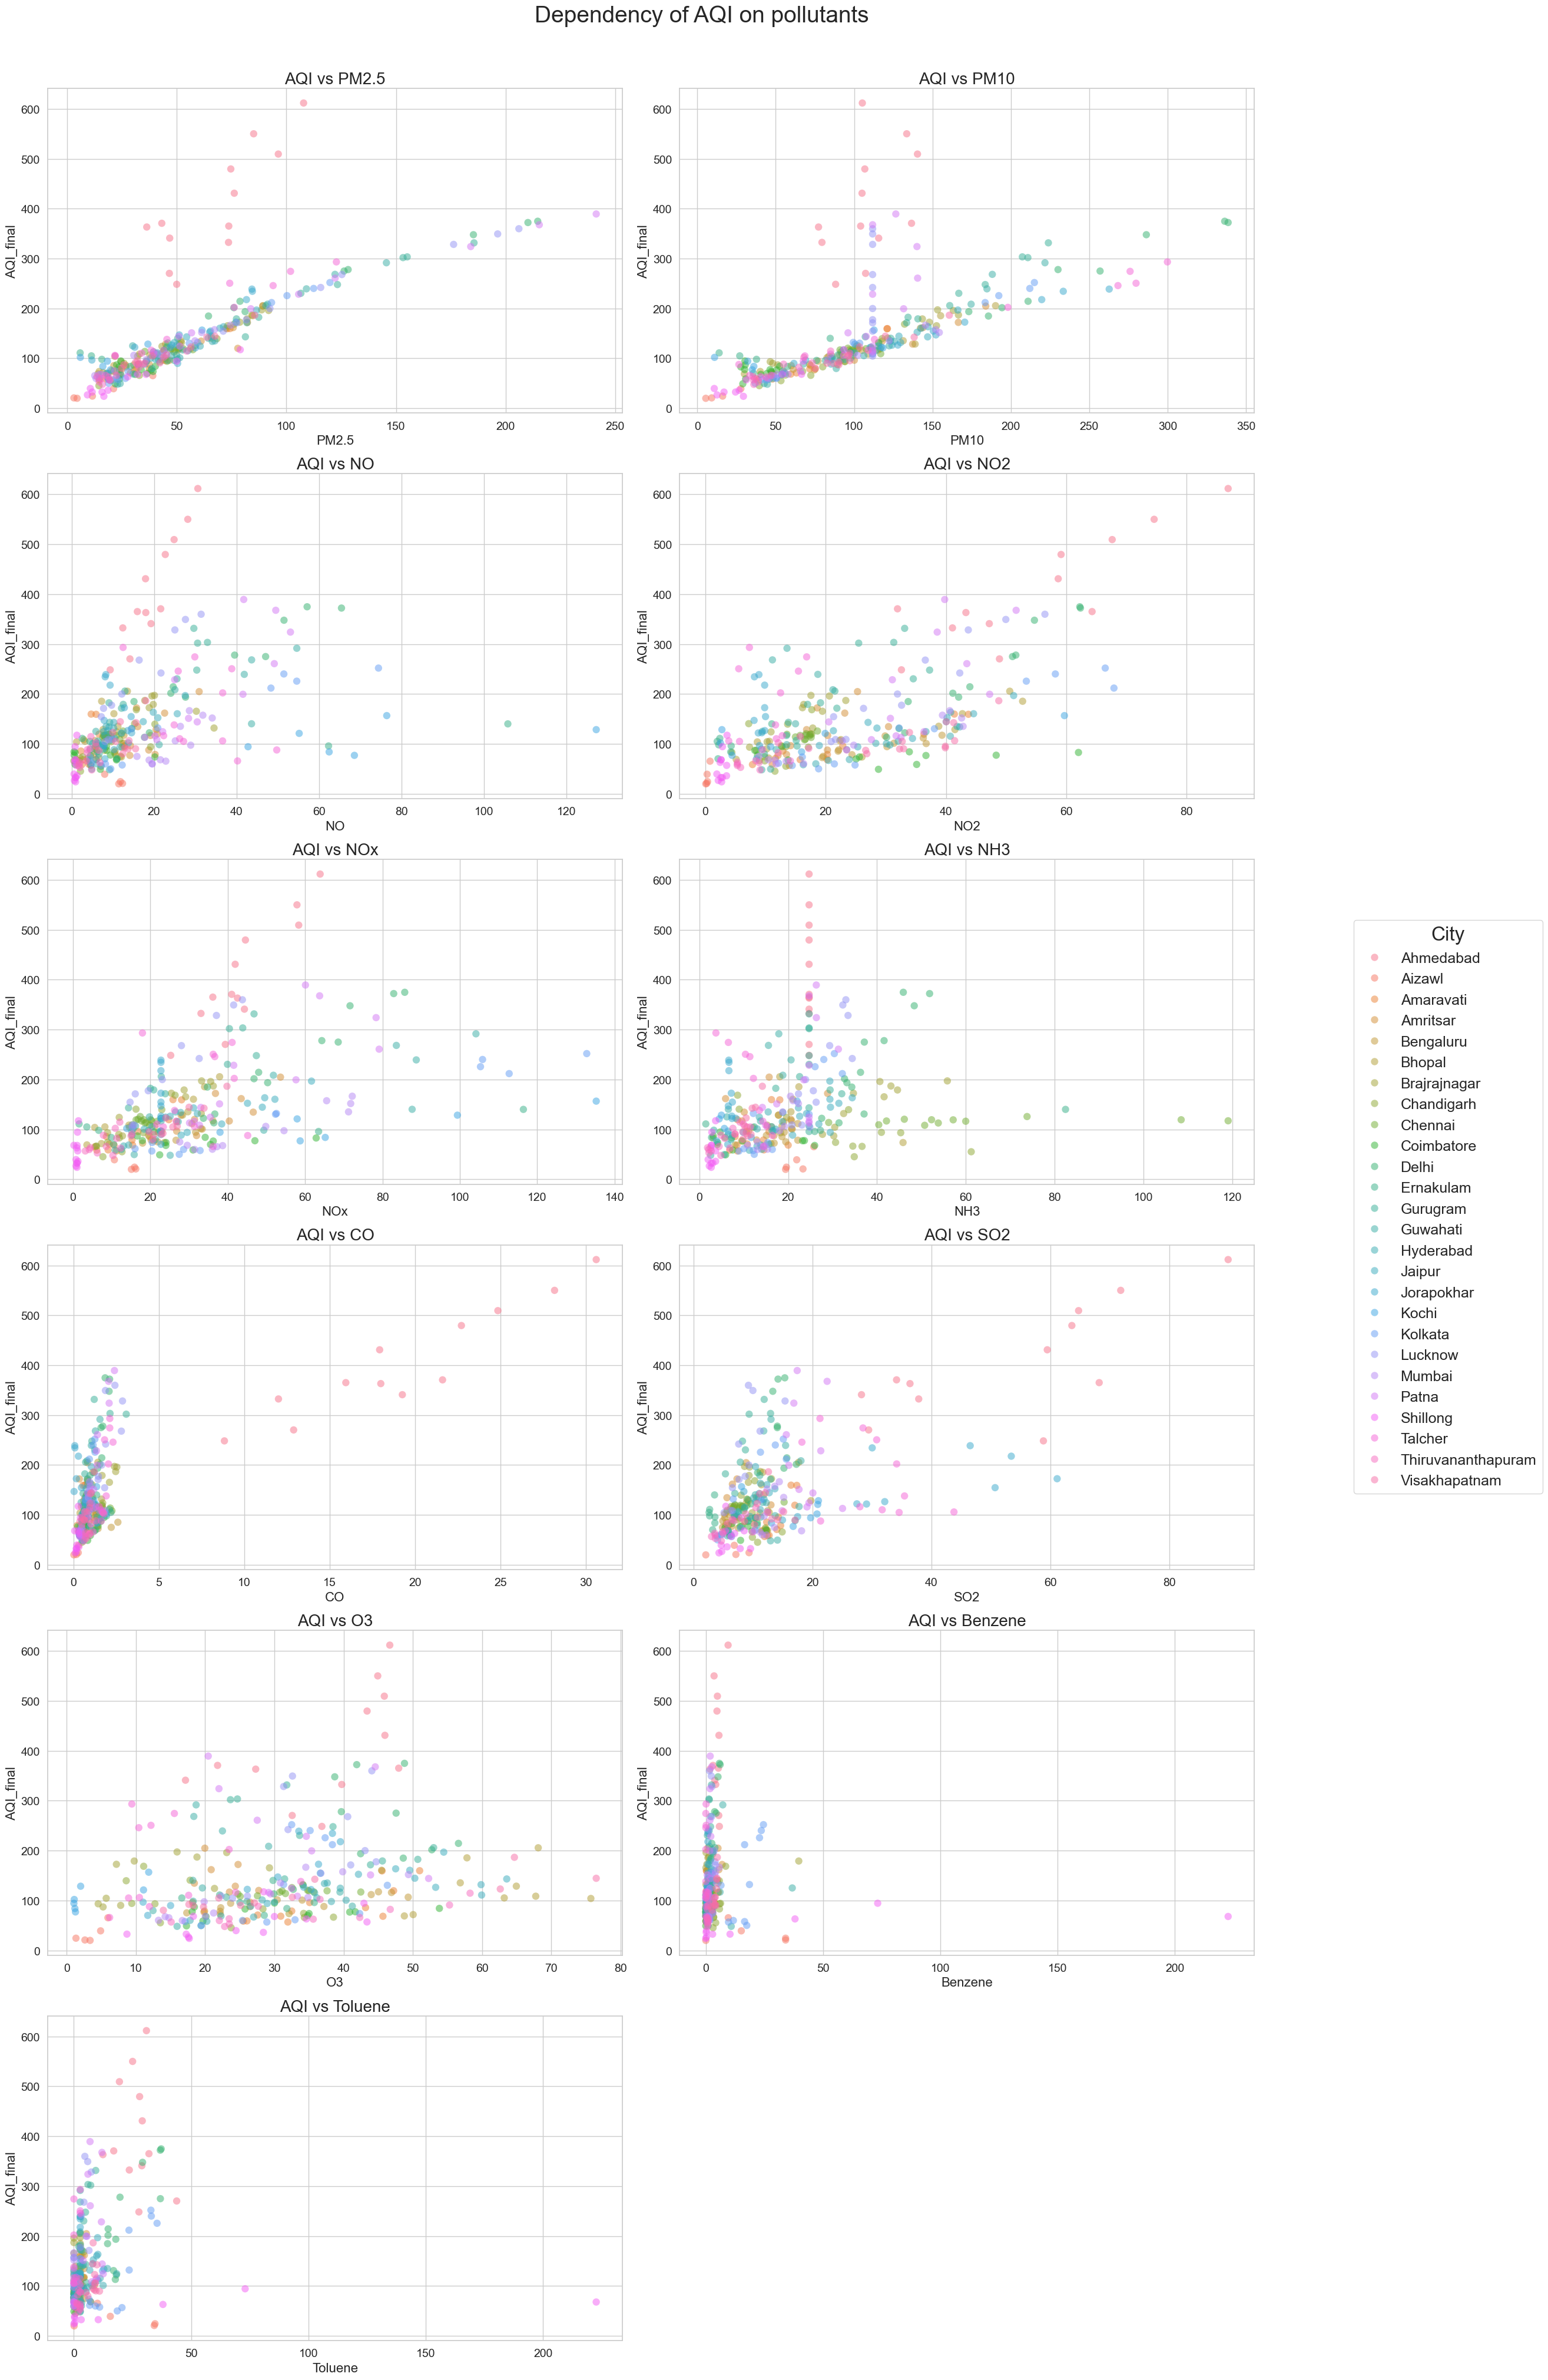

In [259]:
columns_to_plot = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"]

fig, axes = plt.subplots(6, 2, figsize=(24, 40)) 
axes = axes.flatten()

handles, labels = [], []

for i, col in enumerate(columns_to_plot):
    if i < len(axes):
        is_first = (i == 0)
        
        sns.scatterplot(
            data=df_sample, 
            x=col, 
            y="AQI_final", 
            hue='City', 
            ax=axes[i],
            s=80, #size of the bubbles        
            alpha=0.5, #alpha controls transparency of data points. 0.5 for same transparent to see overlapping
            linewidth=0,
            legend=is_first
        )
        
        axes[i].set_title(f'AQI vs {col}', fontsize=20)
        axes[i].set_xlabel(col, fontsize=16)
        axes[i].set_ylabel("AQI_final", fontsize=16)
        axes[i].tick_params(axis='both', which='major', labelsize=14)
        
        if is_first: #removing legends of each correlation graphs. We create one single global legend
            handles, labels = axes[i].get_legend_handles_labels()
            axes[i].get_legend().remove()

for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5), 
           title='City', fontsize=18, title_fontsize=24)

fig.suptitle('Dependency of AQI on pollutants', fontsize=28, y=1.01)

plt.tight_layout(rect=[0, 0, 0.9, 1]) 
plt.show()

In [260]:
impact = corr_matrix[target_column].drop(target_column)   
impact_sorted = impact.abs().sort_values(ascending=False)   # sorting the correlation values from highest to lowest

print("\nImpact of Emissions on AQI (sorted by absolute correlation):")
print(impact_sorted)


Impact of Emissions on AQI (sorted by absolute correlation):
PM2.5      0.658072
PM10       0.613836
CO         0.402034
NO2        0.391676
NOx        0.358152
NO         0.319558
SO2        0.290087
Toluene    0.273206
NH3        0.249986
O3         0.143754
Benzene    0.108079
Name: AQI_final, dtype: float64


**The emissions with significant impact (corr > 0.6) on AQI are PM10 and PM2.5.**

These results are in alignment with the calculation formula for AQI which takes into consideration these 2 emissions. Especially PM2.5 and PM10 have much weight in the calculation methodics due to the condition that these two emissions have to be available in order to calculate AQI.

There is also a strong correlation (0.7) between PM10 and PM2.5, so this relationship may be further analyzed in future research to explore which one of this emission influences AQI directly.

**Visualization of monthly AQI change over the years 2015-2020 and interpretation of the results**

In [261]:
station_hour['Year'] = station_hour['Datetime'].dt.year
monthly_aqi_over_years = station_hour.pivot_table(values="AQI_final", index="Month", columns="Year", aggfunc="mean")
monthly_aqi_over_years
#data aggregation by building the monthly mean value over the years

Year,2015,2016,2017,2018,2019,2020
Month,,,,,,
1,272.622750,289.916882,255.441787,267.195600,284.812121,215.338643
2,260.087426,245.850690,231.846142,239.165018,209.085007,188.933958
3,225.747984,185.883333,167.191490,198.395507,171.133030,119.083357
4,218.366580,186.608603,170.225678,187.953437,178.532718,93.599781
5,224.803024,171.529363,161.529733,179.965335,182.429019,107.892286
6,173.933598,168.007212,126.011536,174.328842,141.067582,90.456070
7,149.187852,134.818952,100.990703,100.002816,108.078498,80.166667
8,140.253776,120.021107,93.187631,105.778297,87.236183,NaN
9,152.969528,120.923757,102.006267,109.947167,88.465957,NaN


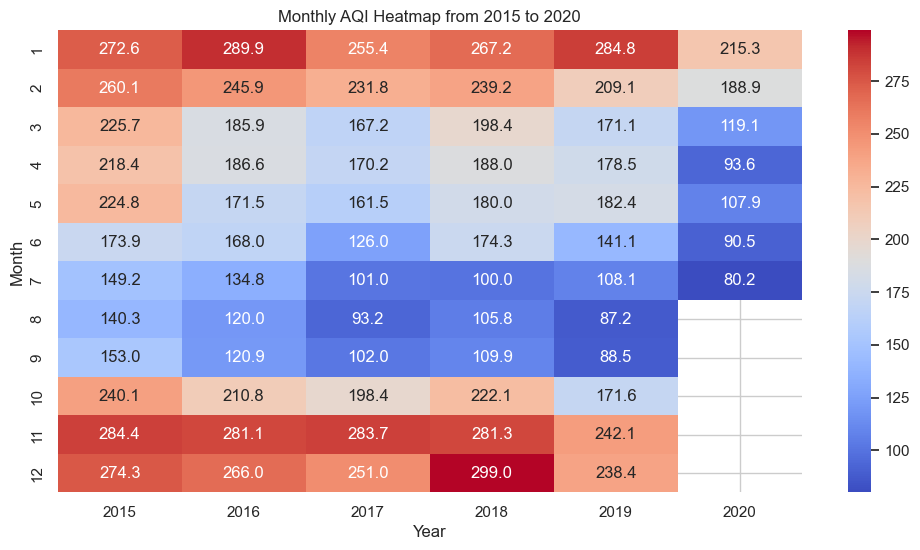

In [262]:
plt.figure(figsize=(12, 6))
sns.heatmap(monthly_aqi_over_years, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Monthly AQI Heatmap from 2015 to 2020")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

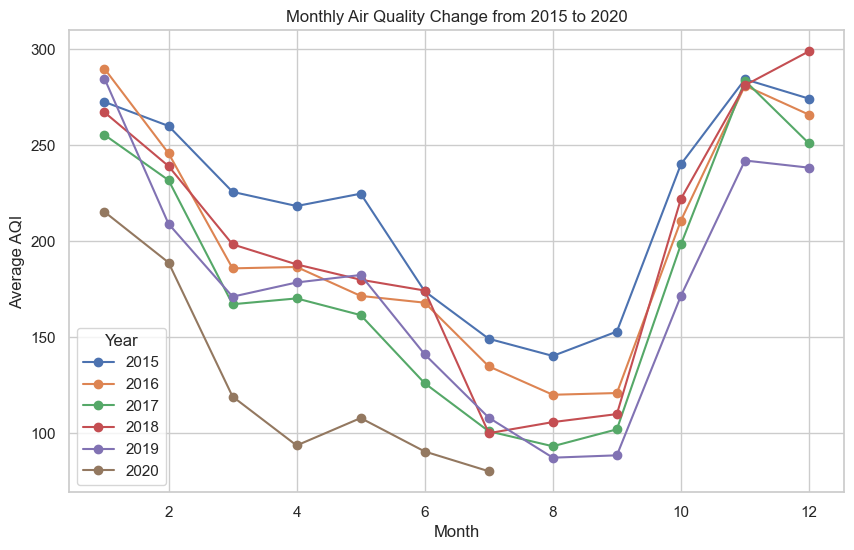

In [263]:
plt.figure(figsize=(10, 6))
for year in monthly_aqi_over_years.columns:
    plt.plot(monthly_aqi_over_years.index, monthly_aqi_over_years[year], marker='o', label=str(year))
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Monthly Air Quality Change from 2015 to 2020")
plt.grid(True)
plt.legend(title="Year")
plt.show()

In year 2015, the monthly AQI hits the highest records for each month (Jan and Dec exception). For the following years, the monthly values are quite consistent and similar with exception of year 2020 which hits the lowest records for each month compared to the previous years. The reason for this might be Covid-19 and the following crisis which shut down manufacturing and decreased air and car traffic.

We can observe that in each year, the AQI increases in Q3 (after September)
and decreases in Q1 (after January). Thus, it can be concluded with high certainty that the AQI is relatively high diring winter and low during summer. 

The main factor behind this tendency could be the increased heating during winter which influences the air quality poorly due to eco-unfriendly heating methods. After some research we found out that the average temperature in India varies from 19°C in winter to 30°C in summer. Thus, the demand for heating isn't massive and it couldn't impact the AQI on this large-scale.
From several resources we found out that a serious issue for AQI is biomass burning. Especially in autumn and winter months there is a large-scale crop burning in agriculture fields which is regarded as low-cost alternative to mechanical tilling. In some states (as it can be seen in the national crop burning portal) there is also increased crop burning in April and Mai which also explains why some years show slight increase in AQI on average during these months. Crop burning produces tremendous amounts of smoke, smog and particulate pollution.

Due to restriction in the access in cropburning.in and lack of crop burning data in Kaggle in the period 2015-2020 we weren't able to show the high correlation between AQI and crop burning. Nevertheless, with high possibility it is certain that biomass and especially crop burning is the major factor for the increase of AQI from October to December.

In the image below we can observe a high increase in the biomass fire data from October to December and a slight increase from April to Mai in the state of Punjab as an example - Source: Crop Burning Portal

Sources: 
- Crop burning issues in India during autumn and winter https://www.kaggle.com/datasets/yashpl11/air-quality-dataset/data
- Multi Year Biomass Fire data (high values from October to December) - https://www.cropburning.in/

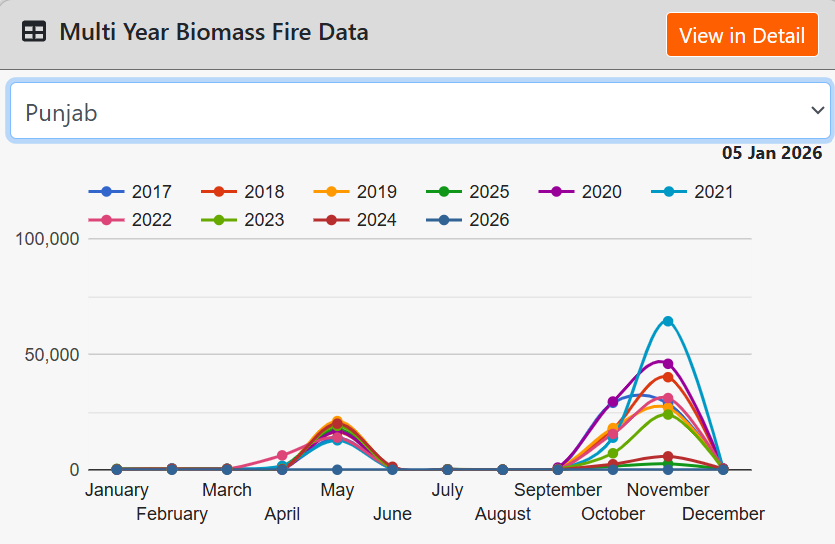

***Visualisation of the monthly emission change over the years 2015-2000 for the 2 most impactful/relevant emissions (PM2.5 and PM10) and interpretation of the results***

In [264]:
monthly_pm25_over_years = station_hour.pivot_table(values="PM2.5", index="Month", columns="Year", aggfunc="mean")
monthly_pm10_over_years = station_hour.pivot_table(values="PM10", index="Month", columns="Year", aggfunc="mean")

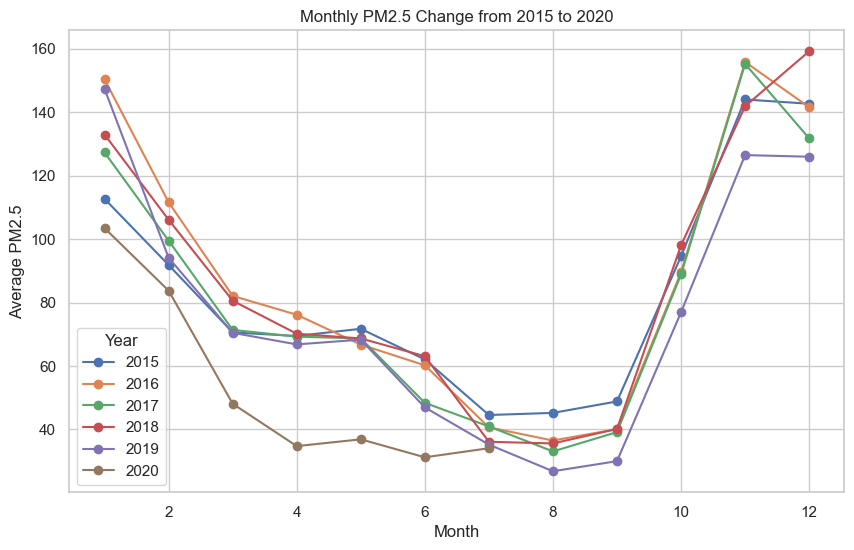

In [265]:
plt.figure(figsize=(10, 6))
for year in monthly_pm25_over_years.columns:
    plt.plot(monthly_pm25_over_years.index, monthly_pm25_over_years[year], marker='o', label=str(year))
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly PM2.5 Change from 2015 to 2020")
plt.grid(True)
plt.legend(title="Year")
plt.show()

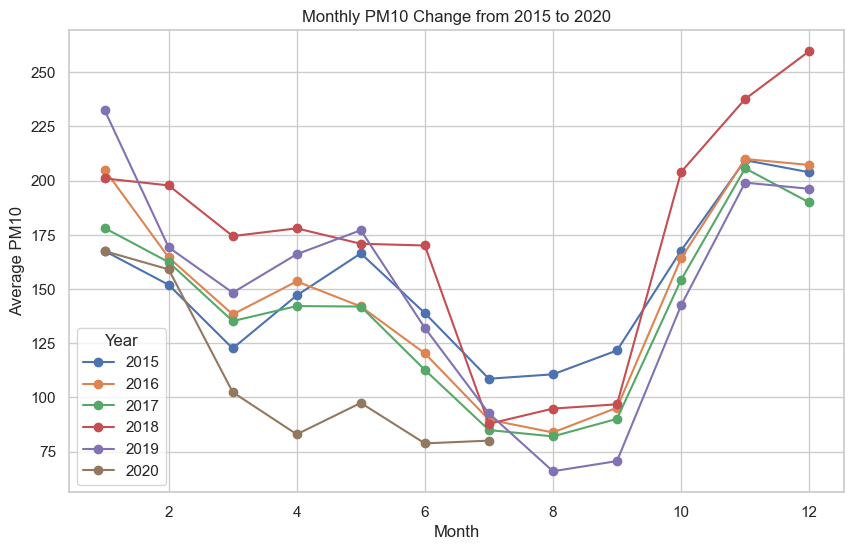

In [266]:
plt.figure(figsize=(10, 6))
for year in monthly_pm10_over_years.columns:
    plt.plot(monthly_pm10_over_years.index, monthly_pm10_over_years[year], marker='o', label=str(year))
plt.xlabel("Month")
plt.ylabel("Average PM10")
plt.title("Monthly PM10 Change from 2015 to 2020")
plt.grid(True)
plt.legend(title="Year")
plt.show()

We can observe that the values of the emission PM2.5 are quite consistent and similar. The values of PM10 are slightly more volative compared to those of PM2.5, but still both emissions show the tendency of dropping during summer and rising during winter. This proves the correlation between these emissions and AQI.

Surprisingly, the emission values for 2015 are quite similar with those of the following years. Nevertheless, we observe a high increase of PM10 from March to Mai 2015 which could be the reason for the slightly higher AQI values during these months.

The emission values are significantly low in 2020 which proves the high correlation between PM2.5, PM10 and AQI as well.

**Dynamic visualisation of AQI on the map of India for relevant cities in the period 2015-2020**

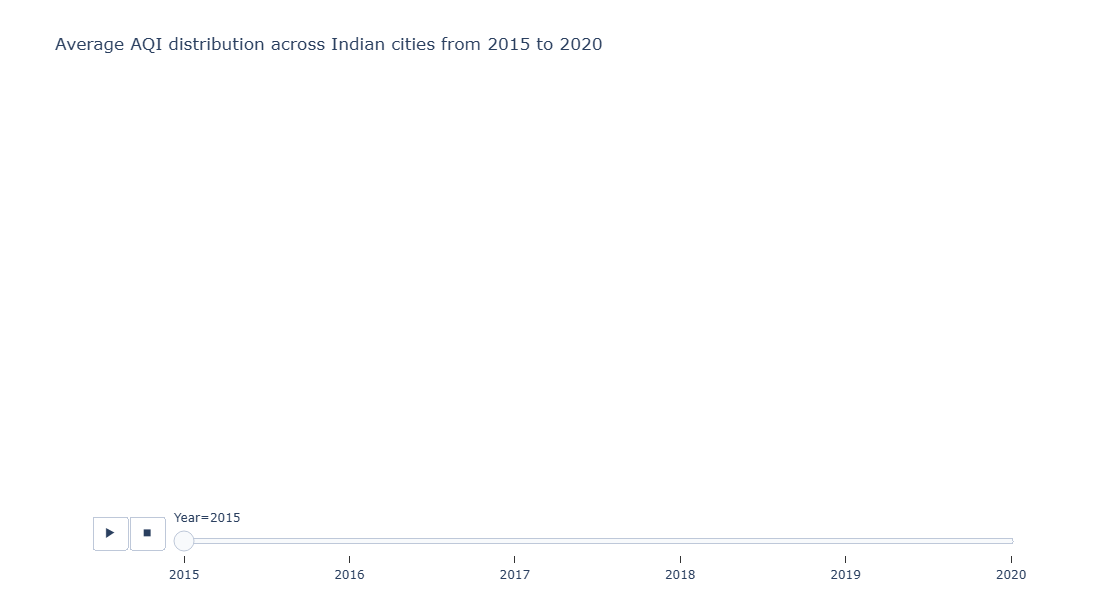

In [267]:
city_aqi = (   #calculating average AQI per city
    station_hour.groupby(["City", "Year"])["AQI_final"]
    .mean()
    .reset_index()
    .dropna()
)

city_coordinates = {    #filling relevant city coordinates (latitude & longitude)
    "Delhi": (28.7041, 77.1025),
    "Mumbai": (19.0760, 72.8777),
    "Kolkata": (22.5726, 88.3639),
    "Chennai": (13.0827, 80.2707),
    "Bengaluru": (12.9716, 77.5946),
    "Hyderabad": (17.3850, 78.4867),
    "Ahmedabad": (23.0225, 72.5714),
    "Pune": (18.5204, 73.8567),
    "Jaipur": (26.9124, 75.7873),
    "Lucknow": (26.8467, 80.9462),
    "Kanpur": (26.4499, 80.3319),
    "Patna": (25.5941, 85.1376),
    "Gurugram": (28.4595, 77.0266),
    "Noida": (28.5355, 77.3910),
    "Faridabad": (28.4089, 77.3178)
}

coordinates_df = pd.DataFrame(city_coordinates.items(), columns=["City", "coords"])
coordinates_df[["lat", "lon"]] = pd.DataFrame(coordinates_df["coords"].tolist(), index=coordinates_df.index)
coordinates_df.drop(columns="coords", inplace=True) # converting coordinates to DataFrame

map_df = city_aqi.merge(coordinates_df, on="City", how="inner") # merging average AQI 
                                              #per city with coordinates DataFrame

fig = px.scatter_geo(   # plotting AQI distribution on the map of India
    map_df,
    lat="lat",
    lon="lon",
    color="AQI_final", #taking the default color of the AQI (red for high, green for small values)
    size="AQI_final",  #taking the size of AQI (bigger AQI means bigger bubble size)
    hover_name="City",
    animation_frame="Year",
    color_continuous_scale="RdYlGn_r",
    title="Average AQI distribution across Indian cities from 2015 to 2020",
)

fig.update_geos(
    scope="asia",  #by zooming-out the whole asian continent can be observed
    center={"lat": 22.5, "lon": 80},
    lataxis_range=[6, 38],
    lonaxis_range=[68, 98]
)

fig.update_layout(
    width=600,
    height=600
)

fig.show()

The results suggest that AQI is generally lower in South of India compared to North of India. For each year, the AQI values in the three relavant Indian cities in the South (Bengaluru, Chennai and Hyderabad) are below 200. In comparison, the AQI values on the North are generally over 200 and for cities like Delhi, Ahmedabad over 250 or even 300. Our assumption for this unequal distribution is the difference in the temperature between North and South and the high demand for heating during winter in the North. To further explore this assumption, it could be interesting to see how the AQI is correlated to the average temperature in each of the relevant cities. Unfortunately, we could't find open-source dataset about the monthly temperature change in particular Indian cities for the period 2015-2020 to prove this correlation.

The highest yearly AQI score is measured in Ahmedabad in 2018 (626,48). For each year, this city shows the highest scores. A very noticable observation is that the AQI score in Ahmedabad increased significantly from 2017 to 2018 while AQI generally decreased in other relevant cities. In 2018, the difference in the AQI score between the highest value in Ahmedabad and the second highest value in Delhi is approximately 381. This unequal distribution of AQI leads to the assumption that there is a specific reason for the high AQI score in Ahmedabad. This might be due to a specific industry which is relatively important for this city or the near location to the border of Pakistan.

From 2018 to 2020, the AQI values for all cities are decreasing hiting the lowest values in 2020. As already supposed, this could be due to Covid-19 and the following pandemic which decreased manufacturing and air/car traffic.

## AQI forecasting

### SARIMA Forecast of AQI for Aug-Dec 2020

SARIMA was selected as the baseline model, employing a univariate approach (forecasting based solely on historical AQI data). This choice is driven by the physical characteristics of the data:

- Inertia (AutoRegression): Atmospheric pollution does not change instantly. High autocorrelation allows us to effectively use past values to predict future levels.
- Seasonality: The AQI time series exhibits a strong 24-hour cyclical pattern driven by anthropogenic factors (traffic, industrial operating schedules) and diurnal meteorological cycles. SARIMA allows for the explicit modeling of these patterns.

In [268]:
station_hour["date"] = pd.to_datetime(station_hour["Date"])
monthly_aqi = (
    station_hour.set_index("date")
      .resample("ME")["AQI_final"]
      .mean()
      .dropna()
)
# Breaking AQI to monthly averages

***Deciding the order and seasonal order of model parameters: (p, d, q) (P, D, Q, s).***

***ACF and PACF plots are used to choose the values of the autoregressive (p and P) and moving average (q and Q) orders***

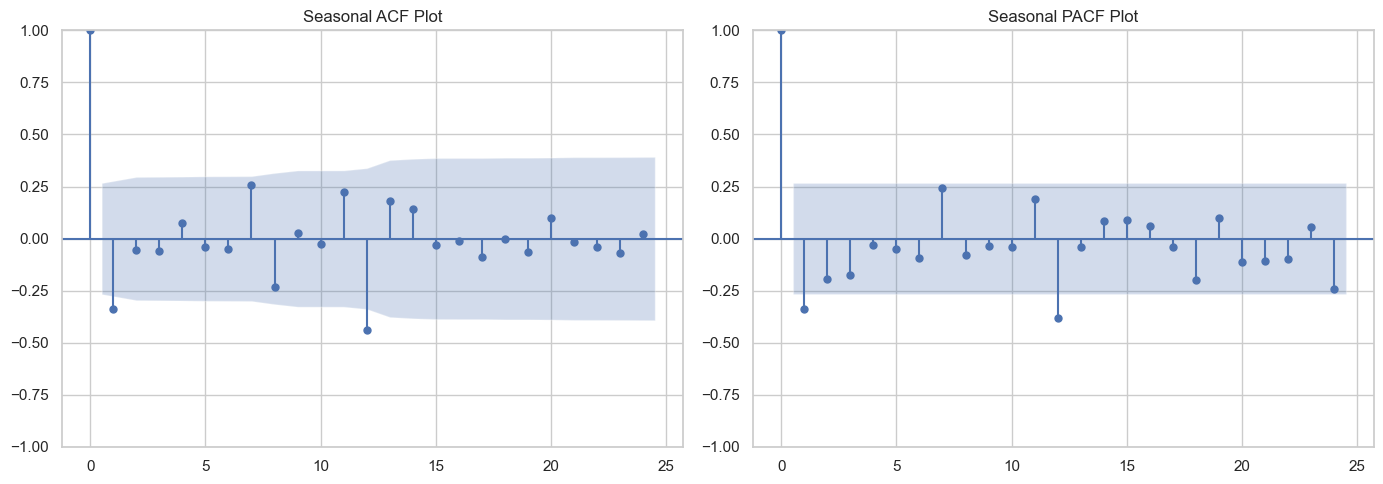

In [269]:
data_period_sarima = monthly_aqi["2015-01":"2020-07"]

train_diff = data_period_sarima.diff().dropna()
train_seasonal_diff = train_diff.diff(12).dropna()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_acf(train_seasonal_diff, lags=24, ax=plt.gca())
plt.title("Seasonal ACF Plot")

plt.subplot(1, 2, 2)
plot_pacf(train_seasonal_diff, lags=24, ax=plt.gca(), method="ywm")
plt.title("Seasonal PACF Plot")

plt.tight_layout()
plt.show()

Autocorrelation and partial autocorrelation are statistical methods to analyze time series data. ACF and PACF plots are designed to reveal the autoregressive (AR) and moving average (MA) components within a time series.

Significant spike at lag 1 in PACF Plot
- p = 1 is a correct choice of model parameter

Significant spike at lag 1 in ACF Plot
- q = 1 is a correct choice of model parameter (q = 1 is often used for environmental data)

Significant spikes at lag 12 in:
- PACF → P = 1
- ACF → Q = 1
  
One might argue that PACF shows significant spike at lag 24 as well which would lead to P=2. Nevertheless, this spike is still within the 25% limit and therefore not considered significant.

***Validation of parameter choice (d) in the model order***

In [270]:
# defining parameter d
# we check hypothesis for stationarity (that there is no trend and equal variance)
X = monthly_aqi

In [271]:
result = adfuller(X)

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

if result[1] > 0.05:
    print("The data is not stationary, we need d=1")
else:
    print("The data is stationary, d=0")

ADF Statistic: 0.6776757763703009
p-value: 0.9893816580422998
The data is not stationary, we need d=1


***Evaluating model quality through splitting the data into train and test and building the evaluation metrics***

In [272]:
tscv = TimeSeriesSplit(n_splits=3) # 3 number of splits delivers the lowest errors
     # TimeSeriesSplit ensures the splitting of time-ordered data. Each test set covers the same
     # time duration, while the train set size accumulates data from previous splits.

mse_scores = []
mae_scores = []
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(data_period_sarima), 1):
    train_data = data_period_sarima.iloc[train_idx]
    test_data = data_period_sarima.iloc[test_idx]

model = SARIMAX(  #fitting the model with train data in order to calculate the evaluation matrics
        train_data,
        order=(1, 1, 1), # check the comments for the choice of the parameter values below and the ACF/PACF plots
        seasonal_order=(1, 1, 1, 12), #S = 12 for monthly seasonality factor
        enforce_stationarity=False,
        enforce_invertibility=False
    )

results = model.fit() # fitting the model

forecast = results.get_forecast(steps=len(test_data)).predicted_mean #forecasting the results for 
                                        #the number of test datapoints and extracting the mean value

mse_scores.append(mean_squared_error(test_data, forecast))
mae_scores.append(mean_absolute_error(test_data, forecast))
r2_scores.append(r2_score(test_data, forecast))

print("\nTimeSeriesSplit Validation Results:")
print(f"Average MSE: {np.mean(mse_scores):.2f}")
print(f"Average MAE: {np.mean(mae_scores):.2f}")
print(f"Average R²: {np.mean(r2_scores):.3f}")

# order = (p, d, q) (P, D, Q, s)
# p = 1 means AQI depends on last month’s AQI
# d: Number of times the series is differenced to remove trend
# q: Number of past forecast errors used; q = 1 means last month’s error affects current prediction
# D: Removes seasonal trend; D = 1 subtracts the value from one year ago
# P = 1 means AQI this January depends on last January’s AQI
# Q = 1 uses last year’s forecast error


TimeSeriesSplit Validation Results:
Average MSE: 1548.56
Average MAE: 31.42
Average R²: 0.484


TimeSeriesSplit doesn't influence the final forecast for the end of 2020. It only shows our confidence in the model by revealing the best and worse case scenario (the lowest and highest MSE and MAE). In order to identify appropriate number of splits, we have to define some constraints. Each test fold should remain at least 1 full year so that the seasonality in the AQI values is represented and considered. This means that number of splits above 5 isn't appropriate as this increases the number of test sets but reduces the number of test datapoints below 12 months in each set (as we have only 5 full years of observation between 2015 to 2020). Thus, fewer but longer splits are more favorable for AQI data in our case. We set 3 number of splits as our lower limit and compare the results with 5 number of splits as our upper limit.

When choosing 3 number of splits, the R2 score shows that 48,4% of the data variance can be explained by the model. In this case, MAE shows that lowest MSE and MAE values and our model performs slightly better with lower error values compared to LightGBM (see model below). Nevertheless, we still need multiple models to appropriately predict AQI for the rest of 2020 and compare the results.

5 number of splits represents the worst-case scenario showing the lowest confidence in the model with the highest MSE and MAE errors. 5 number of splits leads to:
Average MSE: 3150.38; 
Average MAE: 50.43; 
Average R²: 0.147

***Creating the final SARIMA Model with all of the available data***

In [273]:
final_model = SARIMAX(   #fitting the final model with all data available
    data_period_sarima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),#using these values shows the best confidence interval (lowest difference
                                  # between upper and lower bound) and the most realistic AQI Forecast
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit()

forecast = final_results.get_forecast(steps=5) #forecasting for the next 5 months (Aug to Dec 2020)
forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int() #extracting the interval in which our forecast values are
                                           # moving with high certainty (95% default value)

***Vasualisation of AQI Forecast using SARIMA***

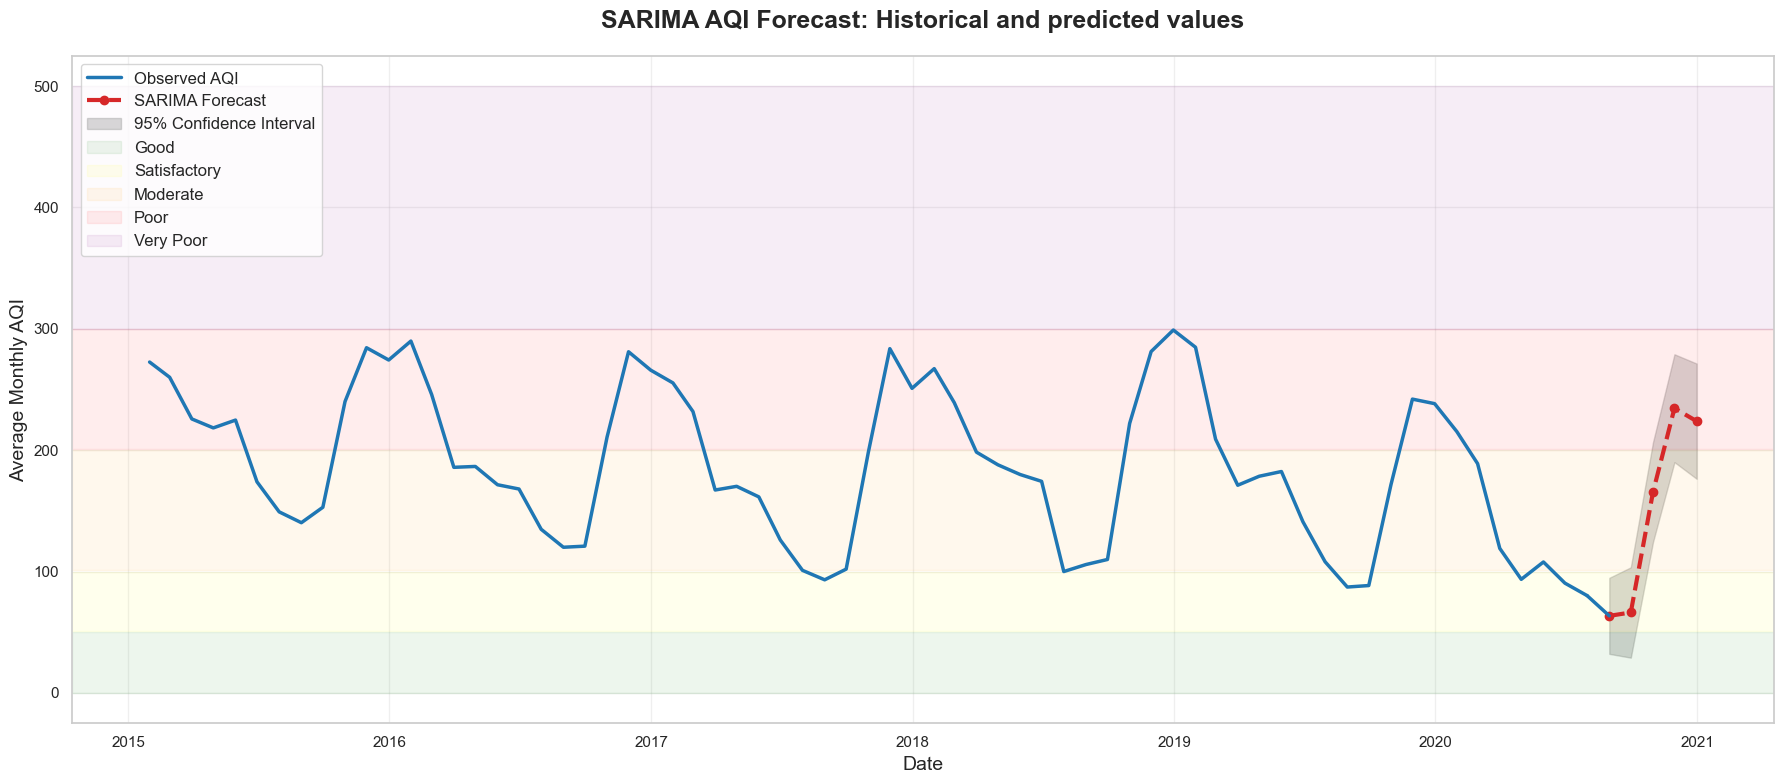

In [275]:
plt.figure(figsize=(18, 8))
sns.set_style("whitegrid")

plt.plot(data_period_sarima.index, data_period_sarima, 
         label='Observed AQI', color='#1f77b4', linewidth=2.5)

plt.plot(forecast_mean.index, forecast_mean, 
         label='SARIMA Forecast', color='#d62728', linewidth=3, linestyle='--', marker='o')

plt.plot([data_period_sarima.index[-1], forecast_mean.index[0]], 
         [data_period_sarima.iloc[-1], forecast_mean.iloc[0]], 
         color='#1f77b4', linestyle='-', linewidth=2.5)

plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0], # lower bound
    confidence_intervals.iloc[:, 1], # upper bound
    color="gray",
    alpha=0.3, 
    label="95% Confidence Interval"
)

plt.axhspan(0, 50, color='green', alpha=0.07, label='Good')
plt.axhspan(51, 100, color='yellow', alpha=0.07, label='Satisfactory')
plt.axhspan(101, 200, color='orange', alpha=0.07, label='Moderate')
plt.axhspan(201, 300, color='red', alpha=0.07, label='Poor')
plt.axhspan(300, 500, color='purple', alpha=0.07, label='Very Poor')

plt.title('SARIMA AQI Forecast: Historical and predicted values', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Average Monthly AQI', fontsize=14)
plt.xlabel('Date', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In the SARIMA Forecast, we can see the clear tendency of AQI increasing in winter and decreasing in the summer. Although the MSE and MAE show slightly higher errors than the following models, the consideration of seasonality in the values suggests SARIMA as an appropriate forecasting model.

The confidence interval shows large difference of lower and upper bounds. Building multiple machine learning models for forecasting AQI is therefore beneficial. Comparing the SARIMA and LightGBM Forecasts (see model further below), we observe relative similar results and tendency. Thus, we can conclude that the used models appropriately predict the AQI values for the rest of 2020.

***Numerical observation of forecasted AQI values and confidence interval (lower and upper bounds)***

In [276]:
forecast_df = pd.DataFrame({
    "Forecasted_AQI": forecast_mean,
    "Lower_CI": confidence_intervals.iloc[:, 0],
    "Upper_CI": confidence_intervals.iloc[:, 1]
})

print("\nAQI Forecast (Aug–Dec 2020):")
display(forecast_df)


AQI Forecast (Aug–Dec 2020):


,Forecasted_AQI,Lower_CI,Upper_CI
2020-08-31,63.498192,32.176740,94.819643
2020-09-30,66.278673,29.059094,103.498253
2020-10-31,165.367002,124.247641,206.486363
2020-11-30,234.581047,190.137761,279.024333
2020-12-31,223.899209,176.416706,271.381712


### AQI forecasting: LightGBM

We continue with **LightGBM** to quickly obtain highly accurate predictions and interpretable results.

Methodology: Regime-Shift Robustness
- **Training (2015 - 2019):** We trained on stable, pre-pandemic data to learn the fundamental physics of seasonal and diurnal emission cycles.
- **Validation (Jan - Jun 2020):** We specifically validated on the COVID-19 lockdown era. This served as a stress test to ensure the model could adapt to the structural break caused by sudden drops in human activity.
- **Forecasting (Jul - Dec 2020):** The final prediction combines the historical seasonal inertia (winter smog expectations) with the specific context of the "new normal."

In [277]:
station_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 26 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Datetime          datetime64[ns]
 1   StationId         object        
 2   PM2.5             float64       
 3   PM10              float64       
 4   NO                float64       
 5   NO2               float64       
 6   NOx               float64       
 7   NH3               float64       
 8   CO                float64       
 9   SO2               float64       
 10  O3                float64       
 11  Benzene           float64       
 12  Toluene           float64       
 13  Date              object        
 14  Time              int32         
 15  Month             int32         
 16  Weekday           int32         
 17  Time_Period       category      
 18  StationName       object        
 19  City              object        
 20  State             object        
 21  Status  

In [278]:
# Creating separate dataset for the prediction
df = station_hour.sort_values(['StationId', 'Datetime']).copy()

# Creating additioal time variable alongside with time, month, day of week
df['dayofyear'] = df['Datetime'].dt.dayofyear

# Cyclical encoding
# Now 23:00 will be close to 00:00 mathematically
df['hour_sin'] = np.sin(2 * np.pi * df['Time'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Time'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [279]:
# Primary lag - 24 hours (one day ago)
df['lag_24'] = df.groupby('StationId')['AQI_final'].shift(24)

# Weekly lag - 168 hours (one week ago)
df['lag_168'] = df.groupby('StationId')['AQI_final'].shift(168)

# Rolling mean over 24 hours (trend)
# Note: We shift by 24 first to ensure we don't use future data
df['rolling_mean_24'] = df.groupby('StationId')['AQI_final'].transform(
    lambda x: x.shift(24).rolling(window=24).mean()
)

# The first 7 days of each station become NaN due to shift(168). We remove them.
df = df.dropna()

In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2568953 entries, 183 to 2589082
Data columns (total 34 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Datetime          datetime64[ns]
 1   StationId         object        
 2   PM2.5             float64       
 3   PM10              float64       
 4   NO                float64       
 5   NO2               float64       
 6   NOx               float64       
 7   NH3               float64       
 8   CO                float64       
 9   SO2               float64       
 10  O3                float64       
 11  Benzene           float64       
 12  Toluene           float64       
 13  Date              object        
 14  Time              int32         
 15  Month             int32         
 16  Weekday           int32         
 17  Time_Period       category      
 18  StationName       object        
 19  City              object        
 20  State             object        
 21  Status     

In [281]:
#  Prepare StationId (LightGBM prefers 'category' type)
# If StationId is object/string (AP001, DL005...), convert to category
if df['StationId'].dtype == 'object':
    df['StationId'] = df['StationId'].astype('category')

In [282]:
# Define split boundaries
split_date_train = '2020-01-01'  # End of training period
split_date_test = '2020-07-01'   # End of available data (validation period)

In [283]:
# Data Slicing
# Train: Everything BEFORE 2020
train = df[df['Datetime'] < split_date_train].copy()

# Validation: First half of 2020 (COVID period)
val = df[(df['Datetime'] >= split_date_train) & (df['Datetime'] < split_date_test)].copy()

In [284]:
# Separate Features (X) and Target (y)
# Drop columns that are not features for the model
# (We remove City and State because StationId already captures this geo-information)
features_to_drop = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI_final', 'Datetime', 'AQI_bucket_final', 'City', 'Date', 'date', 'StationName', 'State', 'Status', 'StationId']

X_train = train.drop(columns=features_to_drop, errors='ignore')
y_train = train['AQI_final']

X_val = val.drop(columns=features_to_drop, errors='ignore')
y_val = val['AQI_final']

In [285]:
# Check shapes
print(f"--- Dataset Sizes ---")
print(f"Train (2015-2019): {X_train.shape} rows")
print(f"Validation (Jan-Jun 2020): {X_val.shape} rows")
print(f'Validation train ratio: {round(X_val.shape[0] / X_train.shape[0]*100, 2)}%')

# Verify feature columns
print(f"\nTraining Features: {X_train.columns.tolist()}")

--- Dataset Sizes ---
Train (2015-2019): (2108354, 13) rows
Validation (Jan-Jun 2020): (460491, 13) rows
Validation train ratio: 21.84%

Training Features: ['Time', 'Month', 'Weekday', 'Time_Period', 'Year', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'lag_24', 'lag_168', 'rolling_mean_24']


In [286]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2108354 entries, 183 to 2584713
Data columns (total 13 columns):
 #   Column           Dtype   
---  ------           -----   
 0   Time             int32   
 1   Month            int32   
 2   Weekday          int32   
 3   Time_Period      category
 4   Year             int32   
 5   dayofyear        int32   
 6   hour_sin         float64 
 7   hour_cos         float64 
 8   month_sin        float64 
 9   month_cos        float64 
 10  lag_24           float64 
 11  lag_168          float64 
 12  rolling_mean_24  float64 
dtypes: category(1), float64(7), int32(5)
memory usage: 170.9 MB


In [287]:
param_dist = {
    'num_leaves': [20, 31, 40],
    'max_depth': [7, 10, 15],        
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500],  
    'min_child_samples': [20, 50, 100],      
    'colsample_bytree': [0.6, 0.7, 0.8], 
    'subsample': [0.6, 0.7, 0.8]             
}

In [288]:
lgb_model = lgb.LGBMRegressor(
    objective='regression', 
    metric='rmse', 
    random_state=42, 
    n_jobs=-1
)

In [289]:
tscv = TimeSeriesSplit(n_splits=3) 

search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,027280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1124
[LightGBM] [Info] Number of data points in the train set: 2108354, number of used features: 13
[LightGBM] [Info] Start training from score 187,086714


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=LGBMRegressor(metric='rmse', n_jobs=-1,
                                           objective='regression',
                                           random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': [7, 10, 15],
                                        'min_child_samples': [20, 50, 100],
                                        'n_estimators': [100, 300, 500],
                                        'num_leaves': [20, 31, 40],
                                        'subsample': [0.6, 0.7, 0.8]},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [290]:
params = search.best_params_

In [291]:
final_model = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1)

In [292]:
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,025728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1124
[LightGBM] [Info] Number of data points in the train set: 2108354, number of used features: 13
[LightGBM] [Info] Start training from score 187,086714
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 68.5398	training's l2: 4697.71	valid_1's rmse: 49.6662	valid_1's l2: 2466.73
Early stopping, best iteration is:
[146]	training's rmse: 66.8343	training's l2: 4466.82	valid_1's rmse: 49.559	valid_1's l2: 2456.1


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=15,
              min_child_samples=50, n_estimators=500, n_jobs=-1, num_leaves=40,
              random_state=42, subsample=0.7)

In [293]:
y_pred_train = final_model.predict(X_train)
y_pred_val = final_model.predict(X_val)

def print_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {set_name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.2f}")

print_metrics(y_train, y_pred_train, "TRAIN (2015-2019)")
print("\n")
print_metrics(y_val, y_pred_val, "VALIDATION (Jan-Jun 2020)")

--- TRAIN (2015-2019) ---
RMSE: 66.83
MSE: 4466.82
MAE:  36.06
R2:   0.78


--- VALIDATION (Jan-Jun 2020) ---
RMSE: 49.56
MSE: 2456.10
MAE:  30.44
R2:   0.72


In [294]:
residuals = y_val - y_pred_val

''

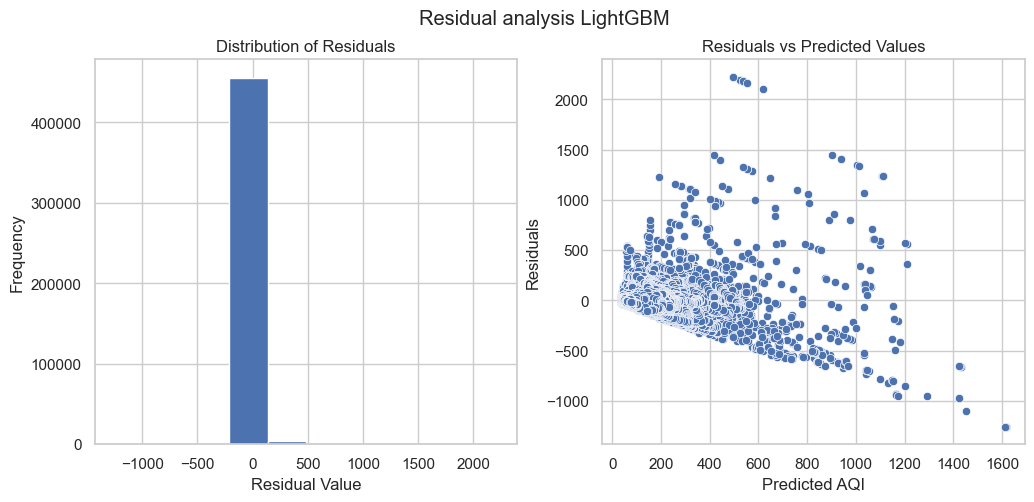

In [295]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(residuals)
axes[0].set_title('Distribution of Residuals')
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Frequency')

sns.scatterplot(x=y_pred_val, y=residuals, ax=axes[1])
axes[1].set_title('Residuals vs Predicted Values') # Specific title for this plot
axes[1].set_xlabel('Predicted AQI')
axes[1].set_ylabel('Residuals')

plt.suptitle('Residual analysis LightGBM')
;

**Residual Analysis**
1. *Distribution of Residuals (Histogram):* The residual distribution is well-centered around zero. This indicates that the LightGBM model is unbiased on average. In general the destribution slightly right-skewed, meanig that model slightly underestimates the values, but in general model is quite precise.

2. *Residuals vs. Predicted Values (Scatter Plot):* The scatter plot reveals that the residuals are not perfectly random (homoscedastic). Instead, we observe distinct heteroscedasticity.

Low to Medium AQI: For lower predicted values, the residuals are tightly clustered around zero, indicating high precision.

High AQI: As the predicted AQI values increase, the variance of the residuals expands (a "funnel" shape).

**Conclusion:** While the model is robust for the majority of observations, the increasing error variance at high AQI levels suggests that extreme pollution events are inherently more volatile and harder to predict with high precision. However, the absence of clear non-linear patterns suggests the model has successfully captured the main relationships in the data.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32908\966631502.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




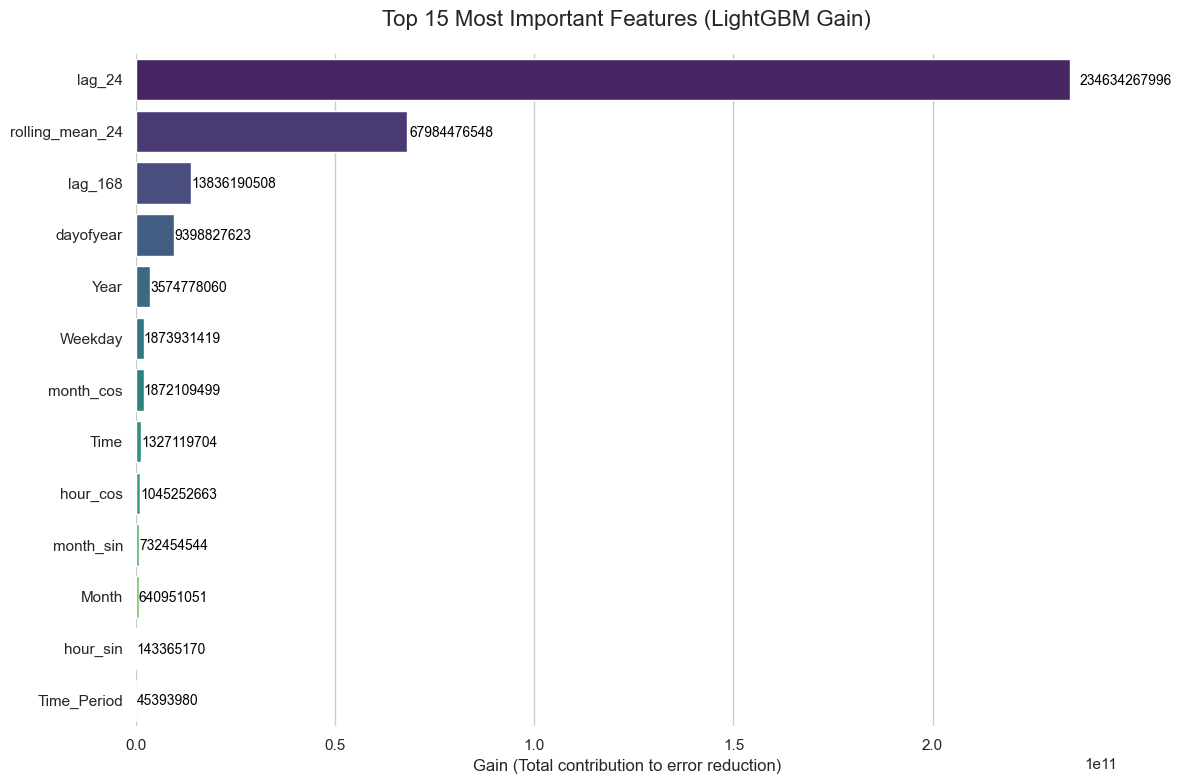

In [296]:
def plot_importance(final_model, X_train, num_features=15):
    
    importance_values = final_model.booster_.feature_importance(importance_type='gain')
    feature_names = X_train.columns
    
    imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Gain': importance_values
    })
    
    imp_df = imp_df.sort_values(by='Gain', ascending=False).head(num_features)
    
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(x='Gain', y='Feature', data=imp_df, palette='viridis')
    
    plt.title(f'Top {num_features} Most Important Features (LightGBM Gain)', fontsize=16, pad=20)
    plt.xlabel('Gain (Total contribution to error reduction)', fontsize=12)
    plt.ylabel('')
    
    sns.despine(left=True, bottom=True)
    
    for i, v in enumerate(imp_df['Gain']):
        ax.text(v + (v * 0.01), i + 0.1, f'{v:.0f}', color='black', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_importance(final_model, X_train, num_features=15)

**Features Importance Analysis**

The values on the graph (gain) represents to which extent this feature in the model reduces the error term for prediction.

The main feature in the predicting model is the AQI values lagged for 24 hours, this feature mainly reduces the error term for the predicting model. Also mean value for 24 hour and lagged values for 1 week (168 days) apper to be quite importat for the prediction. Less contribute time vriables such month, day, time, year.

After we trained the model and validated it on the COVID data seeing that model successfuly predicting AQI for pandemic period. Also, after analysing how exactly model is predicting values (residual analysis) we build predictions itself.

For predictions we use **Recursive Forecasting Strategy** (Dynamic Simulation)

Since the standard batch prediction (e.g., `model.predict(X_test)`) is impossible for long-term forecasting because our model relies on **Lag Features**. For a date in December 2020, the "value from 24 hours ago" is unknown - it hasn't happened yet.

Therefore we implement an **Iterative Feedback Loop**:
1.  **Step:** Generate features for the current specific hour ($t$).
2.  **Predict:** Use the model to estimate AQI for $t$.
3.  **Update:** Write this prediction back into the dataset. It effectively becomes the "history" used to generate lags for future steps ($t+1, t+2...$).

In [297]:
# Define the date range for the forecast (July - Dec 2020)
future_dates = pd.date_range(start='2020-07-01 00:00:00', end='2020-12-31 23:00:00', freq='h')

In [298]:
# Create a Cartesian product of "All Stations" x "All Future Dates"
# We need a row for every station for every hour
stations = df['StationId'].unique()  # Get stations from the original dataset
future_df = pd.DataFrame([
    {'StationId': s, 'Datetime': d} 
    for s in stations 
    for d in future_dates
])

In [299]:
# Set correct data types
future_df['StationId'] = future_df['StationId'].astype('category')
future_df['AQI'] = np.nan  # Initialize target column with NaNs (to be filled by model)

In [300]:
# Append "History Tail" (Last week of June)
# We need this data to calculate lags (e.g., lag_24) for the first few days of July.
# We take the last 168 hours (1 week) from the validation/original set.
history_tail = df[df['Datetime'] >= '2020-06-23'].copy()

# Keep only necessary columns to match the future structure
required_cols = ['StationId', 'Datetime', 'AQI_final']
history_tail = history_tail[required_cols]

In [301]:
# Merge History and Future into one simulation dataframe
# We will read from the past rows and write to the future rows in the loop.
full_simulation = pd.concat([history_tail, future_df], ignore_index=True)
full_simulation = full_simulation.sort_values(['StationId', 'Datetime']).reset_index(drop=True)

In [302]:
full_simulation.head()

,StationId,Datetime,AQI_final,AQI
0,AP001,2020-06-23 00:00:00,55.0,NaN
1,AP001,2020-06-23 01:00:00,55.0,NaN
2,AP001,2020-06-23 02:00:00,55.0,NaN
3,AP001,2020-06-23 03:00:00,55.0,NaN
4,AP001,2020-06-23 04:00:00,55.0,NaN


In [303]:
feature_cols = X_train.columns.tolist()

print(f"Starting simulation using {len(feature_cols)} features...")
full_simulation = full_simulation.drop_duplicates(subset=['StationId', 'Datetime'])

Starting simulation using 13 features...


In [304]:
station_dtype = full_simulation['StationId'].dtype
period_categories = ['Night', 'Morning', 'Day', 'Evening']
period_dtype = pd.CategoricalDtype(categories=period_categories, ordered=True)

for current_time in tqdm(future_dates):
    
    current_mask = (full_simulation['Datetime'] == current_time)
    
    if not current_mask.any():
        continue

    pred_batch = full_simulation.loc[current_mask, ['StationId']].copy()
    
    pred_batch['Month'] = current_time.month
    pred_batch['Weekday'] = current_time.weekday()
    pred_batch['Time'] = current_time.hour
    pred_batch['Year'] = current_time.year
    pred_batch['dayofyear'] = current_time.dayofyear

    # Time Period
    h = current_time.hour
    if 6 <= h < 12:
        period = 'Morning'
    elif 12 <= h < 18:
        period = 'Day'
    elif 18 <= h < 24:
        period = 'Evening'
    else:
        period = 'Night'
    
    pred_batch['Time_Period'] = period
    pred_batch['Time_Period'] = pred_batch['Time_Period'].astype(period_dtype)

    pred_batch['StationId'] = pred_batch['StationId'].astype(station_dtype)

    # Sin/Cos
    pred_batch['hour_sin'] = np.sin(2 * np.pi * h / 24)
    pred_batch['hour_cos'] = np.cos(2 * np.pi * h / 24)
    pred_batch['month_sin'] = np.sin(2 * np.pi * current_time.month / 12)
    pred_batch['month_cos'] = np.cos(2 * np.pi * current_time.month / 12)

    # Lag 24
    time_24_ago = current_time - pd.Timedelta(hours=24)
    aqi_24 = full_simulation.loc[full_simulation['Datetime'] == time_24_ago, ['StationId', 'AQI']]
    
    pred_batch = pred_batch.merge(aqi_24, on='StationId', how='left', suffixes=('', '_prev'))
    pred_batch = pred_batch.rename(columns={'AQI': 'lag_24'})
    
    # Lag 168
    time_168_ago = current_time - pd.Timedelta(hours=168)
    aqi_168 = full_simulation.loc[full_simulation['Datetime'] == time_168_ago, ['StationId', 'AQI']]
    
    pred_batch = pred_batch.merge(aqi_168, on='StationId', how='left')
    pred_batch = pred_batch.rename(columns={'AQI': 'lag_168'})

    pred_batch['lag_24'] = pred_batch['lag_24'].ffill().fillna(0)
    pred_batch['lag_168'] = pred_batch['lag_168'].ffill().fillna(0)

    pred_batch['rolling_mean_24'] = pred_batch['lag_24']
    
    X_test_step = pred_batch[feature_cols]
    
    # Теперь ошибки быть не должно, так как категории совпадают
    current_preds = final_model.predict(X_test_step)
    
    full_simulation.loc[current_mask, 'AQI'] = current_preds

100%|██████████████████████████████████████████████████████████████████████████████| 4416/4416 [03:27<00:00, 21.32it/s]


In [305]:
full_simulation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506496 entries, 0 to 506603
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   StationId  506496 non-null  category      
 1   Datetime   506496 non-null  datetime64[ns]
 2   AQI_final  20844 non-null   float64       
 3   AQI        485760 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(2)
memory usage: 15.9 MB


In [306]:
full_simulation

,StationId,Datetime,AQI_final,AQI
0,AP001,2020-06-23 00:00:00,55.0,NaN
1,AP001,2020-06-23 01:00:00,55.0,NaN
2,AP001,2020-06-23 02:00:00,55.0,NaN
3,AP001,2020-06-23 03:00:00,55.0,NaN
4,AP001,2020-06-23 04:00:00,55.0,NaN
...,...,...,...,...
506599,WB013,2020-12-31 19:00:00,NaN,247.084938
506600,WB013,2020-12-31 20:00:00,NaN,247.084938
506601,WB013,2020-12-31 21:00:00,NaN,247.084938
506602,WB013,2020-12-31 22:00:00,NaN,247.084938


In [307]:
history_data = df[df['Datetime'] < '2020-07-01'].copy()

forecast_data_lgbm = full_simulation.loc[
    full_simulation['Datetime'] >= '2020-07-01', 
    ['Datetime', 'AQI']
].copy()

hist_monthly = history_data.set_index('Datetime')['AQI_final'].resample('ME').mean()
fc_monthly = forecast_data_lgbm.set_index('Datetime')['AQI'].resample('ME').mean()

last_hist_point = hist_monthly.iloc[[-1]]

fc_monthly_connected = pd.concat([last_hist_point, fc_monthly])

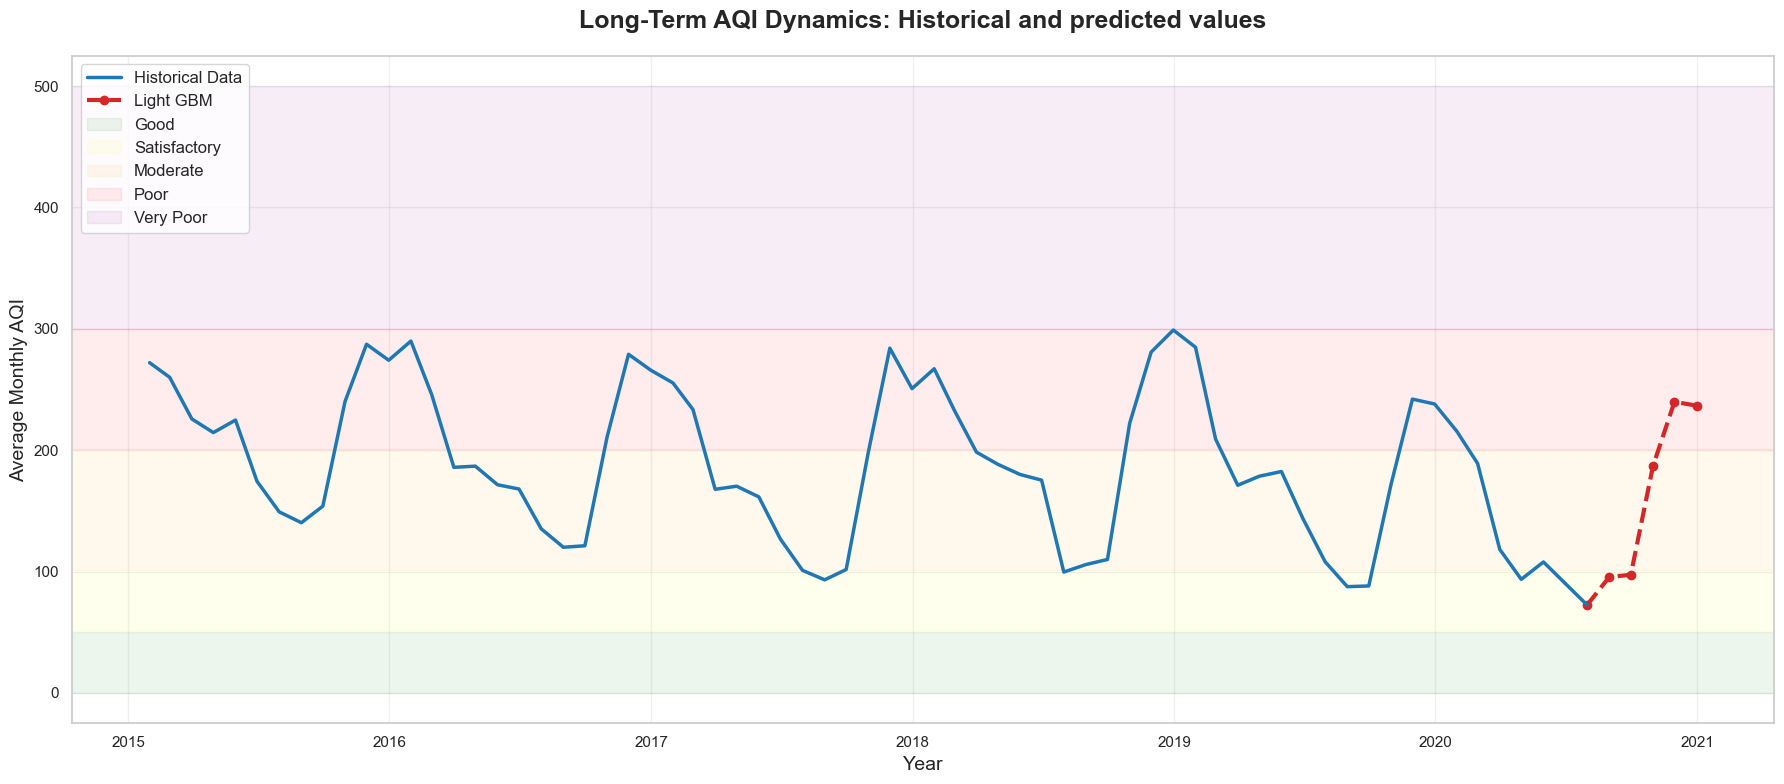

In [308]:
plt.figure(figsize=(18, 8))
sns.set_style("whitegrid")

# Historical data (blue line)
plt.plot(hist_monthly.index, hist_monthly.values, 
         label='Historical Data', color='#1f77b4', linewidth=2.5)

# Forecasted values (red line)
plt.plot(fc_monthly.index, fc_monthly.values, 
         label='Light GBM', color='#d62728', linewidth=3, linestyle='--', marker='o')

# Connecting historical and predicted data
plt.plot([hist_monthly.index[-1], fc_monthly.index[0]], 
         [hist_monthly.values[-1], fc_monthly.values[0]], 
         color='#1f77b4', linestyle='-', linewidth=2.5)

# Coluoring zones based on Air Quality 
full_index = pd.concat([hist_monthly, fc_monthly]).index
plt.axhspan(0, 50, color='green', alpha=0.07, label='Good')
plt.axhspan(51, 100, color='yellow', alpha=0.07, label='Satisfactory')
plt.axhspan(101, 200, color='orange', alpha=0.07, label='Moderate')
plt.axhspan(201, 300, color='red', alpha=0.07, label='Poor')
plt.axhspan(300, 500, color='purple', alpha=0.07, label='Very Poor')

plt.title('Long-Term AQI Dynamics: Historical and predicted values', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Average Monthly AQI', fontsize=14)
plt.xlabel('Year', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [309]:
fc_monthly

Datetime
2020-07-31     72.442201
2020-08-31     95.549384
2020-09-30     97.313046
2020-10-31    186.838762
2020-11-30    239.870007
2020-12-31    236.692109
Freq: ME, Name: AQI, dtype: float64

In [310]:
# for SARIMA and LightGBM forecast comparison
final_forecast_sarima_mean = forecast_df['Forecasted_AQI']
final_forecast_sarima_mean

2020-08-31     63.498192
2020-09-30     66.278673
2020-10-31    165.367002
2020-11-30    234.581047
2020-12-31    223.899209
Freq: ME, Name: Forecasted_AQI, dtype: float64

In [311]:
point_to_add = fc_monthly.iloc[0:1] 

final_forecast_sarima_mean = pd.concat([point_to_add, final_forecast_sarima_mean])

In [312]:
final_forecast_sarima_mean

2020-07-31     72.442201
2020-08-31     63.498192
2020-09-30     66.278673
2020-10-31    165.367002
2020-11-30    234.581047
2020-12-31    223.899209
Freq: ME, dtype: float64

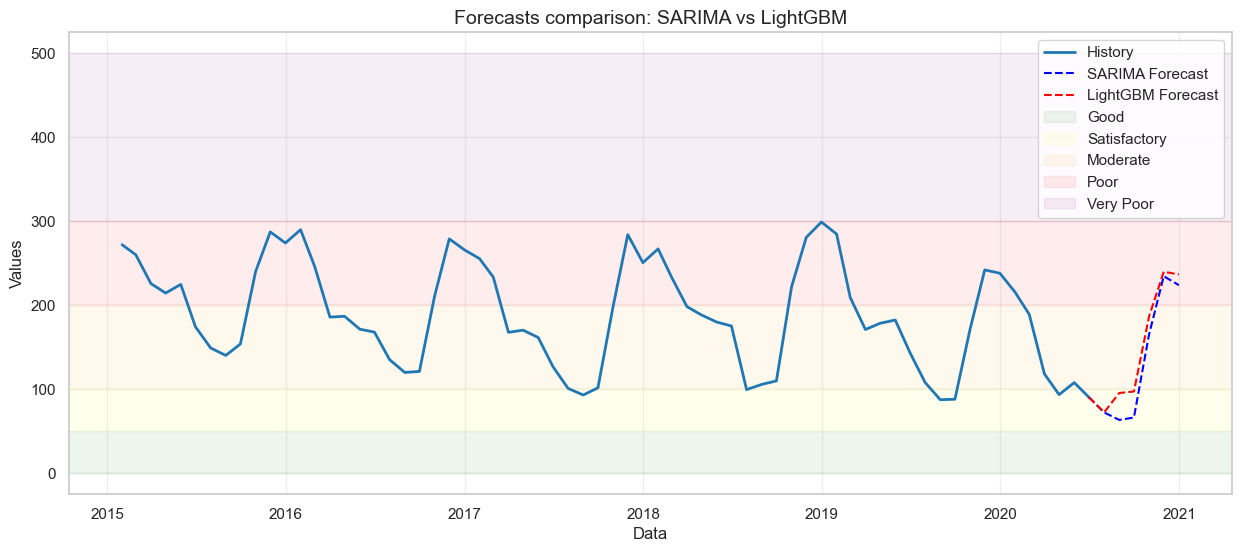

In [313]:
last_hist_point = hist_monthly.iloc[-1:]

plot_sarima = pd.concat([last_hist_point, final_forecast_sarima_mean])
plot_lgbm = pd.concat([last_hist_point, fc_monthly])

plt.figure(figsize=(15, 6))

plt.plot(hist_monthly.index, hist_monthly, label='History', color='#1f77b4', linewidth=2)

plt.plot(plot_sarima.index, plot_sarima, 
         label='SARIMA Forecast', linestyle='--', color='blue')

plt.plot(plot_lgbm.index, plot_lgbm, 
         label='LightGBM Forecast', linestyle='--', color='red')

plt.axhspan(0, 50, color='green', alpha=0.07, label='Good')
plt.axhspan(51, 100, color='yellow', alpha=0.07, label='Satisfactory')
plt.axhspan(101, 200, color='orange', alpha=0.07, label='Moderate')
plt.axhspan(201, 300, color='red', alpha=0.07, label='Poor')
plt.axhspan(300, 500, color='purple', alpha=0.07, label='Very Poor')

plt.title('Forecasts comparison: SARIMA vs LightGBM', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Conclusion: LightGBM Forecasting Model**
- **Feature Engineering & Data Leakage Prevention:** We developed a LightGBM regressor using strictly temporal features (hour, month, seasonality via cyclical sin/cos transformations) and historical lags. We intentionally excluded concurrent pollutant measurements (e.g., current PM2.5, CO) to prevent data leakage, ensuring the model simulates a realistic forecasting scenario where future chemical compositions are unknown.
- **Recursive Forecasting Strategy:**
To predict AQI for the extended horizon (July–December 2020), we implemented a Recursive Multi-Step Strategy. This approach is essential for capturing the high inertia of air quality data: the model predicts one hour ahead ($t+1$), and this prediction is fed back into the dataset as a lag feature to generate the subsequent prediction ($t+2$), preserving the continuity of the time series
- **Adaptability to COVID-19 Anomalies:** Despite being trained on "normal" pre-pandemic conditions (2015–2019), the model showed remarkable robustness during the COVID-19 lockdown validation period (Jan–June 2020). This adaptability is driven by strong autocorrelation captured by lag features (specifically lag_24). These features act as a self-correcting mechanism, allowing the model to quickly adjust to the structural shift of lower pollution levels based on the immediate history, without requiring specific "lockdown" flags..

### AQI forecasting: RNN LTSM

In [314]:
station_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 26 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Datetime          datetime64[ns]
 1   StationId         object        
 2   PM2.5             float64       
 3   PM10              float64       
 4   NO                float64       
 5   NO2               float64       
 6   NOx               float64       
 7   NH3               float64       
 8   CO                float64       
 9   SO2               float64       
 10  O3                float64       
 11  Benzene           float64       
 12  Toluene           float64       
 13  Date              object        
 14  Time              int32         
 15  Month             int32         
 16  Weekday           int32         
 17  Time_Period       category      
 18  StationName       object        
 19  City              object        
 20  State             object        
 21  Status  

In [315]:
df_prep = station_hour.copy()

df_prep['Datetime'] = pd.to_datetime(df_prep['Datetime'])

df = df_prep.set_index('Datetime').groupby('City').resample('D')['AQI_final'].mean().to_frame()

df = df.reset_index()

In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   City       29531 non-null  object        
 1   Datetime   29531 non-null  datetime64[ns]
 2   AQI_final  29513 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 692.3+ KB


In [317]:
df = df.set_index('Datetime')
df['month_index'] = df.index.month
df['sin_month'] = np.sin(2 * np.pi * df['month_index'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month_index'] / 12)

data_values = df[['AQI_final', 'sin_month', 'cos_month']].values

In [318]:
df['AQI_final'] = df.groupby('City')['AQI_final'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)
train_end_date = pd.to_datetime('2019-12-31')
val_start_date = pd.to_datetime('2020-01-01')
val_end_date   = pd.to_datetime('2020-06-30')
look_back = 365
feature = ['AQI_final', 'sin_month', 'cos_month']

scaler = MinMaxScaler()
train_mask = df.index <= train_end_date
scaler.fit(df.loc[train_mask, feature])

X_train, y_train = [], []
X_val, y_val = [], []

for city in df['City'].unique():
    city_series = df[df['City'] == city][feature]
    scaled_city = scaler.transform(city_series)
    city_indices = city_series.index
    
    for i in range(look_back, len(scaled_city)):
        current_date = city_indices[i]
        
        window = scaled_city[i-look_back:i, :] 
        target = scaled_city[i, 0]
        
        if current_date <= train_end_date:
            X_train.append(window)
            y_train.append(target)
        elif val_start_date <= current_date <= val_end_date:
            X_val.append(window)
            y_val.append(target)

X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)

In [319]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2]))) 

model.add(LSTM(units=32, 
               return_sequences=False, 
               kernel_regularizer=l2(0.01)))

model.add(Dropout(0.3))
model.add(Dense(units=1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,                     
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 542s 124ms/step - loss: 0.0097 - val_loss: 0.0045
Epoch 2/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 5427s 1s/step - loss: 0.0026 - val_loss: 0.0013
Epoch 3/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 888s 192ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 4/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 823s 189ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 5/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 762s 175ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 6/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 785s 180ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 7/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 632s 145ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 8/8
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 570s 131ms/step - loss: 0.0022 - val_loss: 9.6159e-04


In [324]:
aqi_scaler = MinMaxScaler()

aqi_scaler.fit(df[['AQI_final']])

MinMaxScaler()

In [325]:
train_preds_scaled = model.predict(X_train, verbose=0)
val_preds_scaled = model.predict(X_val, verbose=0)

y_train_real = aqi_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
train_preds_real = aqi_scaler.inverse_transform(train_preds_scaled).flatten()

y_val_real = aqi_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
val_preds_real = aqi_scaler.inverse_transform(val_preds_scaled).flatten()

print_metrics(y_train_real, train_preds_real, "TRAIN (2015-2019)")
print("\n")
print_metrics(y_val_real, val_preds_real, "VALIDATION")

--- TRAIN (2015-2019) ---
RMSE: 84.35
MSE: 7114.27
MAE:  44.24
R2:   0.68


--- VALIDATION ---
RMSE: 56.53
MSE: 3195.08
MAE:  33.80
R2:   0.60


In [326]:
residuals_train = y_train_real - train_preds_real
val_residuals = y_val_real - val_preds_real

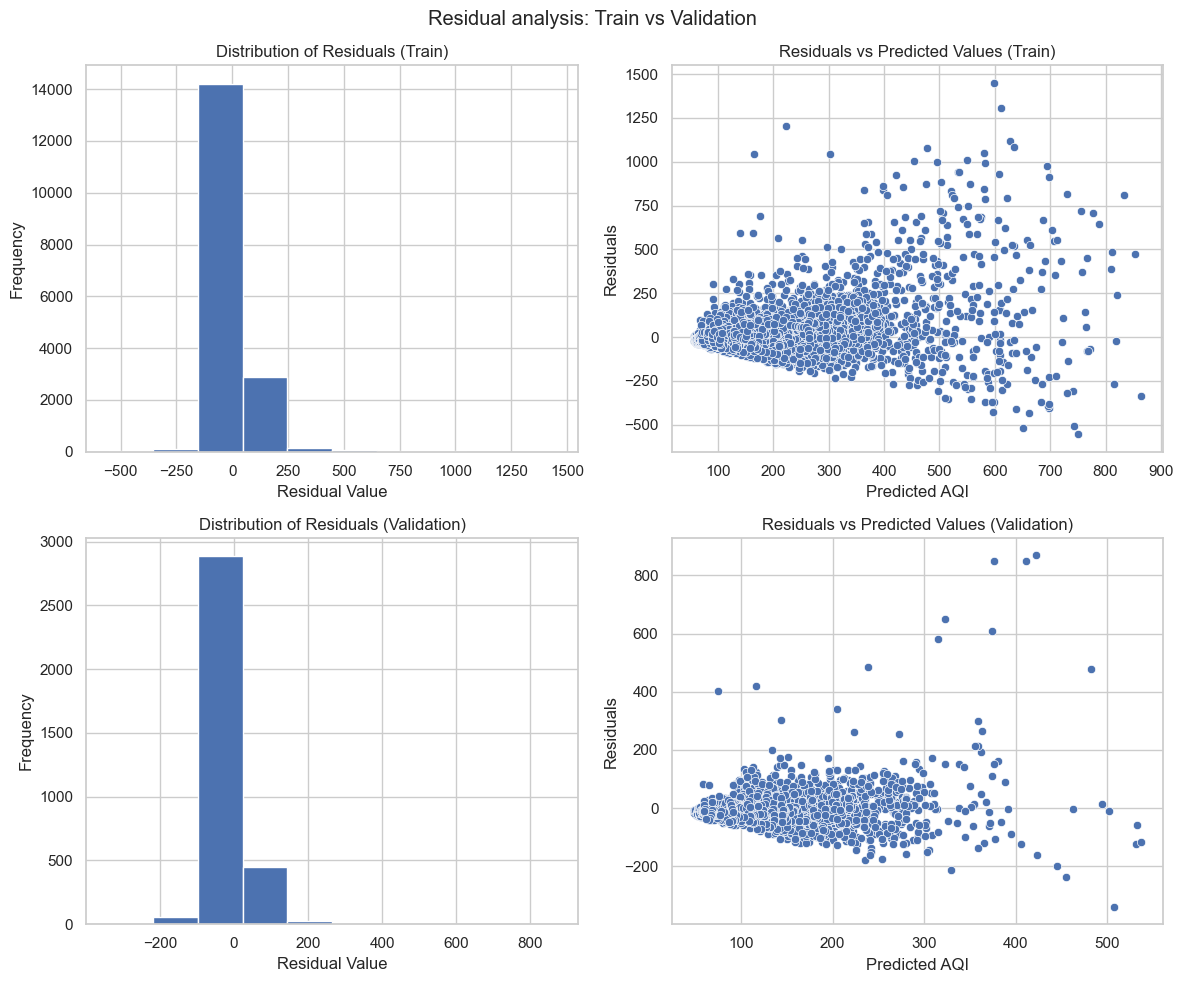

In [327]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Training Set ---

# Гистограмма Train
axes[0, 0].hist(residuals_train)
axes[0, 0].set_title('Distribution of Residuals (Train)')
axes[0, 0].set_xlabel('Residual Value')
axes[0, 0].set_ylabel('Frequency')

# Scatter Plot Train
sns.scatterplot(x=train_preds_real, y=residuals_train, ax=axes[0, 1])
axes[0, 1].set_title('Residuals vs Predicted Values (Train)')
axes[0, 1].set_xlabel('Predicted AQI')
axes[0, 1].set_ylabel('Residuals')

# --- Validation Set  ---

# Гистограмма Validation
axes[1, 0].hist(val_residuals)
axes[1, 0].set_title('Distribution of Residuals (Validation)')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Frequency')

# Scatter Plot Validation
sns.scatterplot(x=val_preds_real, y=val_residuals, ax=axes[1, 1])
axes[1, 1].set_title('Residuals vs Predicted Values (Validation)')
axes[1, 1].set_xlabel('Predicted AQI')
axes[1, 1].set_ylabel('Residuals')

plt.suptitle('Residual analysis: Train vs Validation')
plt.tight_layout()
plt.show();

In [332]:
current_batch = X_val[-1].reshape(1, look_back, 3) 

future_predictions = []
future_dates = []
current_date = pd.to_datetime('2020-07-01') 

for i in tqdm(range(184), desc="Progress"):
    pred_aqi = model.predict(current_batch, verbose=0)[0][0]
    
    noise = np.random.normal(0, 0.01)
    pred_final = np.clip(pred_aqi + noise, 0, 1)
    
    future_predictions.append(pred_final)
    future_dates.append(current_date)
    
    next_date = current_date + pd.Timedelta(days=1)
    m = next_date.month
    next_sin = np.sin(2 * np.pi * m / 12)
    next_cos = np.cos(2 * np.pi * m / 12)
    
    new_entry = np.array([pred_final, next_sin, next_cos]).reshape(1, 1, 3)
    
    current_batch = np.append(current_batch[:, 1:, :], new_entry, axis=1)
    current_date = next_date

dummy = np.zeros((len(future_predictions), 3))
dummy[:, 0] = future_predictions
real_predictions = scaler.inverse_transform(dummy)[:, 0]

forecast_daily = pd.DataFrame(real_predictions, index=future_dates, columns=['AQI'])
forecast_monthly = forecast_daily.resample('ME').mean()

Progress: 100%|██████████████████████████████████████████████████████████████████████| 184/184 [00:41<00:00,  4.48it/s]


In [333]:
forecast_monthly

,AQI
2020-07-31,26.886399
2020-08-31,34.922387
2020-09-30,65.624511
2020-10-31,114.701749
2020-11-30,171.924093
2020-12-31,197.506983


In [334]:
df = df_prep.set_index('Datetime').resample('ME')['AQI_final'].mean().to_frame()

In [343]:
hist_monthly = df['AQI_final'].resample('MS').mean()

# 2. Подготовка данных прогноза
# Используем forecast_monthly, который мы получили в предыдущем шаге
forecast_data = forecast_monthly['AQI']

In [346]:
forecast_data

2020-07-31     26.886399
2020-08-31     34.922387
2020-09-30     65.624511
2020-10-31    114.701749
2020-11-30    171.924093
2020-12-31    197.506983
Freq: ME, Name: AQI, dtype: float64

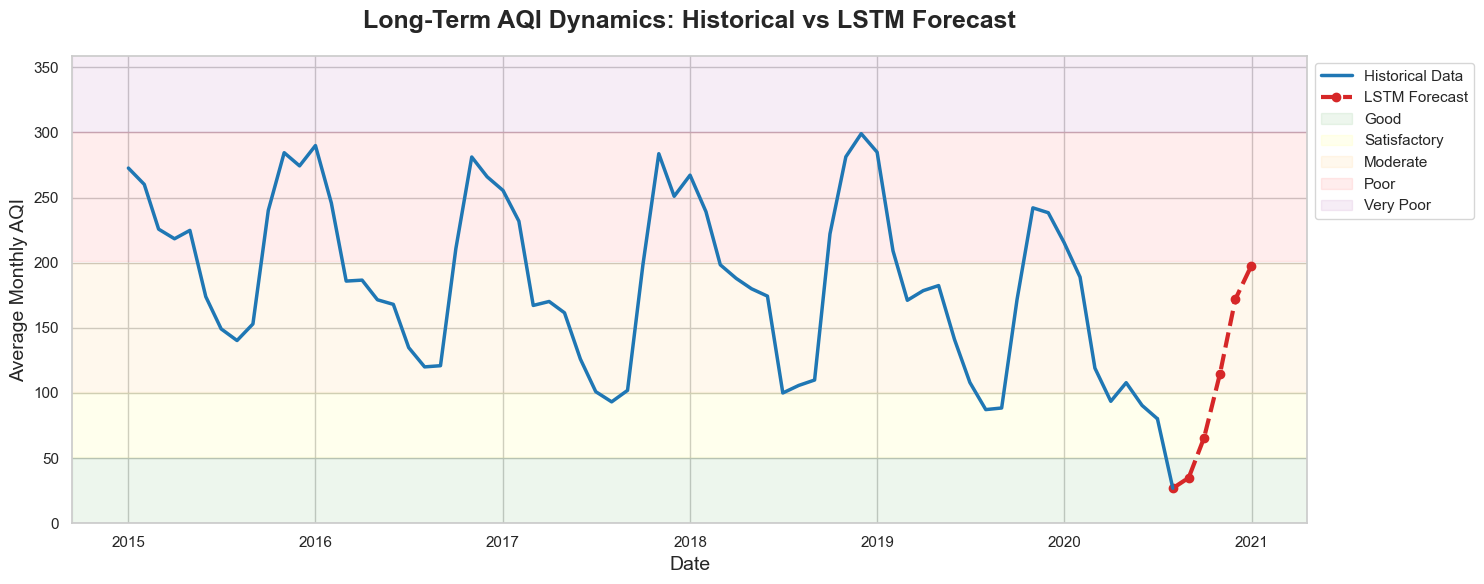

In [348]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

plt.plot(hist_monthly.index, hist_monthly.values, 
         label='Historical Data', color='#1f77b4', linewidth=2.5)

plt.plot(forecast_data.index, forecast_data.values, 
         label='LSTM Forecast', color='#d62728', linewidth=3, linestyle='--', marker='o')

plt.plot([hist_monthly.index[-1], forecast_data.index[0]], 
         [hist_monthly.values[-1], forecast_data.values[0]], 
         color='#1f77b4', linestyle='-', linewidth=2.5)

plt.axhspan(0, 50, color='green', alpha=0.07, label='Good')
plt.axhspan(51, 100, color='yellow', alpha=0.07, label='Satisfactory')
plt.axhspan(101, 200, color='orange', alpha=0.07, label='Moderate')
plt.axhspan(201, 300, color='red', alpha=0.07, label='Poor')
plt.axhspan(300, 500, color='purple', alpha=0.07, label='Very Poor')

plt.title('Long-Term AQI Dynamics: Historical vs LSTM Forecast', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Average Monthly AQI', fontsize=14)
plt.xlabel('Date', fontsize=14)

max_val = max(hist_monthly.max(), forecast_data.max())
plt.ylim(0, max_val * 1.2)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

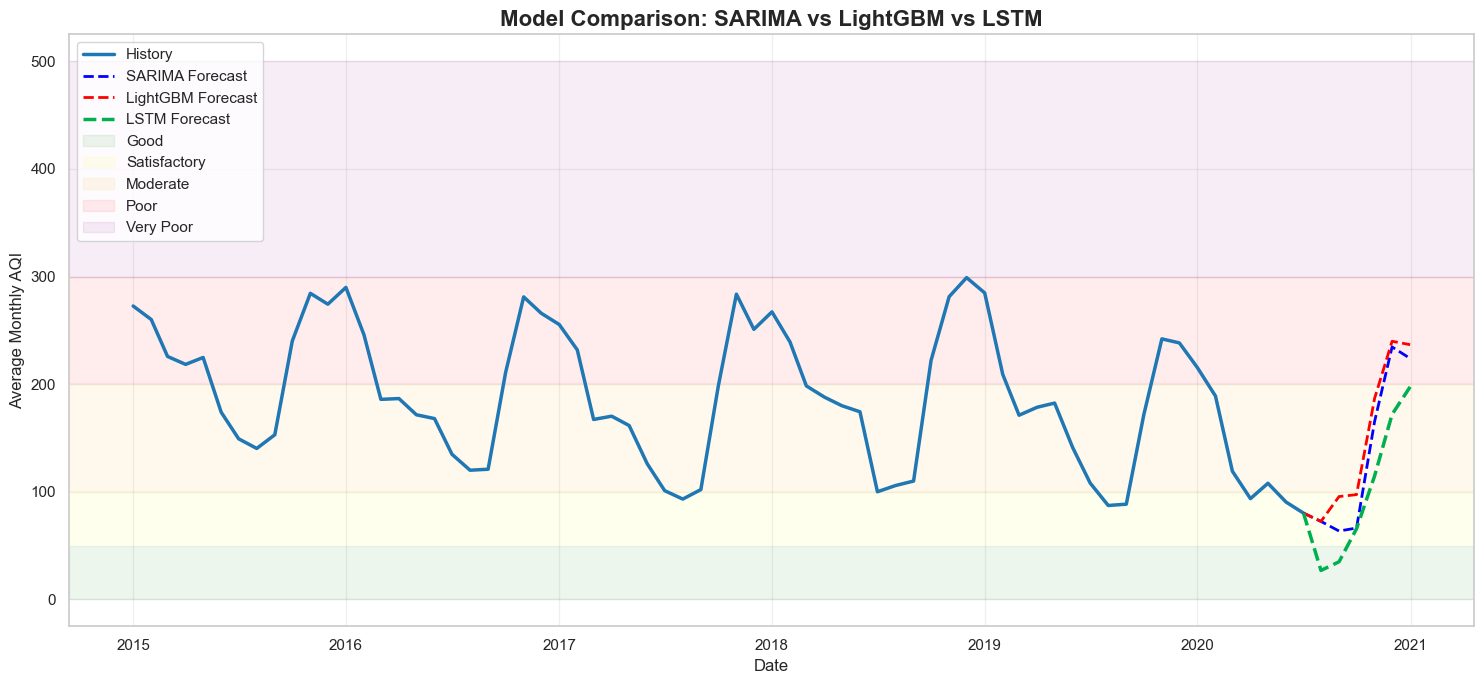

In [354]:
last_hist_point = hist_monthly.iloc[-1:]

# SARIMA
plot_sarima = pd.concat([last_hist_point, final_forecast_sarima_mean])

# LightGBM
plot_lgbm = pd.concat([last_hist_point, fc_monthly])

# LSTM
lstm_series = forecast_data
plot_lstm = pd.concat([last_hist_point, lstm_series])

plt.figure(figsize=(15, 7))
plt.plot(hist_monthly.index, hist_monthly, label='History', color='#1f77b4', linewidth=2.5)
plt.plot(plot_sarima.index, plot_sarima, 
         label='SARIMA Forecast', linestyle='--', color='blue', linewidth=2)

plt.plot(plot_lgbm.index, plot_lgbm, 
         label='LightGBM Forecast', linestyle='--', color='red', linewidth=2)

plt.plot(plot_lstm.index, plot_lstm, 
         label='LSTM Forecast', linestyle='--', color='#00b050', linewidth=2.5, markersize=2)

plt.axhspan(0, 50, color='green', alpha=0.07, label='Good')
plt.axhspan(51, 100, color='yellow', alpha=0.07, label='Satisfactory')
plt.axhspan(101, 200, color='orange', alpha=0.07, label='Moderate')
plt.axhspan(201, 300, color='red', alpha=0.07, label='Poor')
plt.axhspan(300, 500, color='purple', alpha=0.07, label='Very Poor')

plt.title('Model Comparison: SARIMA vs LightGBM vs LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Monthly AQI', fontsize=12)

plt.legend(loc='upper left', frameon=True, fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Clustering

This clustering analysis identifies unique 'chemical signatures' for different regions. By grouping stations based on pollutant composition rather than just total AQI, we can recommend data-driven policies tailored to the specific emission sources of each cluster.

### Feature engineering and aggregation

For defining clusters accurately, we firstly will work with stations to define the profile of the city in more details. Since stations might be located in differet parts of the city and differently describe the environment there. After clustering the stations we will superimpose the results on the city level. 

Before clustering we firstly need to aggregate our data to the station level (before we were wroking with hourly data for each station). For this purpouse we need to apply feature engineering. And create variables that will capture the day, week, month and year dynamics for each pollutant tracked by the station. 

The following metrics will be calculated for the each pollutant from the dataset:
1. **Intensity (`{Pol}_Median`):** Represents the typical background pollution level at the station. Unlike the mean, it is robust against outliers and extreme measurement errors.
2. **Peaks (`{Pol}_P95`):** Represents hazardous pollution episodes. It indicates the pollution level that is exceeded only 5% of the time (worst-case scenarios).
3. **Cleanest State (`{Pol}_P05`):** Represents the baseline pollution level when local sources are inactive or ventilation is high. It filters out sensor noise (zeros) but captures the "cleanest" air available at that station.
4. **Pollution Amplitude (`{Pol}_Range_P95_P05`):** The absolute difference between the peak events and the cleanest state.
5. **Volatility (`{Pol}_CV`):** The Coefficient of Variation. It measures how unstable the pollution source is. A high value indicates sporadic, burst-like emissions; a low value indicates a constant, steady source (like a continuously running factory).
6. **Daily Cycle (`{Pol}_DayNight_Ratio`):** Compares pollution levels during active hours versus sleeping hours. Helps distinguish between traffic/office activity (high day values) and domestic heating/accumulation (high night values).
7. **Weekly Cycle (`{Pol}_Weekend_Ratio`):** Captures the "Weekend Effect." Measures the reduction in pollution when human economic activity (traffic, offices, industry) slows down.
8. **Annual Cycle (`{Pol}_WinterSummer_Ratio`):** Captures seasonal dependency, primarily serving as a proxy for heating emissions (winter peaks) versus photochemical smog or dust (summer peaks).

Initially we have 11 pollutants and create 8 variables for each. Thus, as a result we have 88 variables.

In [355]:
# Data aggreagtion to the station level
def preprocess_air_quality_data(df):
    
    # Copy to avoid SettingWithCopy warnings
    data = df.copy()
    
    # Drop rows with missing essential metadata
    # We don't drop rows with missing pollutants yet, as they might exist for other pollutants
    data = data.dropna(subset=['StationId', 'Month', 'Weekday', 'Time_Period'])
    
    # Pre-calculate boolean masks for temporal cycles (Vectorized operations)
    # Daily Cycle: 'Night' vs everything else
    data['is_night'] = data['Time_Period'] == 'Night'
    
    # Weekly Cycle: Saturday (5) and Sunday (6)
    data['is_weekend'] = data['Weekday'].isin([5, 6])
    
    # Annual Cycle: Season mapping
    def get_season(month):
        if month in [12, 1, 2]: return 'Winter'
        if month in [6, 7, 8]: return 'Summer'
        return 'Other'
        
    data['season_calc'] = data['Month'].apply(get_season)
    
    print(f"Preprocessing complete. Rows: {len(data)}")
    return data

In [356]:
df_clean = preprocess_air_quality_data(station_hour)

Preprocessing complete. Rows: 2589083


In [357]:
df_clean.head()

,Datetime,StationId,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,City,State,Status,AQI_final,AQI_bucket_final,Year,date,is_night,is_weekend,season_calc
0,2017-11-24 17:00:00,AP001,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,...,Amaravati,Andhra Pradesh,Active,NaN,NaN,2017,2017-11-24,False,False,Other
1,2017-11-24 18:00:00,AP001,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,...,Amaravati,Andhra Pradesh,Active,NaN,NaN,2017,2017-11-24,False,False,Other
2,2017-11-24 19:00:00,AP001,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,...,Amaravati,Andhra Pradesh,Active,NaN,NaN,2017,2017-11-24,False,False,Other
3,2017-11-24 20:00:00,AP001,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,...,Amaravati,Andhra Pradesh,Active,NaN,NaN,2017,2017-11-24,False,False,Other
4,2017-11-24 21:00:00,AP001,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,...,Amaravati,Andhra Pradesh,Active,NaN,NaN,2017,2017-11-24,False,False,Other


In [358]:
def calculate_statistical_features(df, pollutants):
    """
    Calculates basic stats (Median, P05, P95, CV, Range)
    """    
    stations = df['StationId'].unique()
    stats_df = pd.DataFrame(index=stations)
    
    # Aggregation: Calculate all base stats in one efficient 'groupby' pass
    agg_funcs = {
        'Median': 'median',
        'P05': lambda x: x.quantile(0.05),
        'P95': lambda x: x.quantile(0.95),
        'Mean': 'mean',
        'Std': 'std'
    }
    
    # Group by StationId and calculate stats for ALL pollutants at once
    # Result is a MultiIndex columns dataframe
    grouped = df.groupby('StationId')[pollutants].agg(list(agg_funcs.values()))
    
    # Rename columns to match our aggregation names (optional, for clarity inside loop)
    # But it's easier to access via MultiIndex: grouped[('NO2', 'median')]
    
    for pol in pollutants:
        # Accessing the calculated stats using the function names/aliases
        # We assume the order matches agg_funcs.values()
        
        # 1. Intensity (Median)
        stats_df[f'{pol}_Median'] = grouped[pol].iloc[:, 0] # First agg func is median
        
        # 2. Cleanest State (P05)
        p05 = grouped[pol].iloc[:, 1]
        stats_df[f'{pol}_P05'] = p05
        
        # 3. Peaks (P95)
        p95 = grouped[pol].iloc[:, 2]
        stats_df[f'{pol}_P95'] = p95
        
        # 4. Range (Amplitude)
        stats_df[f'{pol}_Range_P95_P05'] = p95 - p05
        
        # 5. Volatility (CV)
        mean_val = grouped[pol].iloc[:, 3]
        std_val = grouped[pol].iloc[:, 4]
        stats_df[f'{pol}_CV'] = std_val / (mean_val + 1e-6)
        
    return stats_df

In [359]:
# Define your target pollutants
target_pollutants = ['PM2.5', 'PM10','NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
features_stats = calculate_statistical_features(df_clean, target_pollutants)
print("Stats shape:", features_stats.shape)

Stats shape: (110, 55)


In [360]:
def calculate_temporal_features(df, pollutants):
    """
    Calculates cycle ratios (Day/Night, Weekend/Workday, Winter/Summer)
    """
    stations = df['StationId'].unique()
    temp_df = pd.DataFrame(index=stations)
    
    # Dayly cycle
    daily_pivot = df.pivot_table(
        index='StationId', columns='is_night', values=pollutants, aggfunc='mean'
    )
    
    # Weekly cycle
    weekly_pivot = df.pivot_table(
        index='StationId', columns='is_weekend', values=pollutants, aggfunc='mean'
    )
    
    # Seasonal cycle
    season_mask = df['season_calc'].isin(['Winter', 'Summer'])
    seasonal_pivot = df[season_mask].pivot_table(
        index='StationId', columns='season_calc', values=pollutants, aggfunc='mean'
    )
    
    # Calculating ratios
    for pol in pollutants:
        # 1. Day/Night Ratio (False=Day, True=Night)
        if (pol, False) in daily_pivot.columns and (pol, True) in daily_pivot.columns:
            temp_df[f'{pol}_DayNight_Ratio'] = daily_pivot[(pol, False)] / (daily_pivot[(pol, True)] + 1e-6)
            
        # 2. Weekend Ratio (False=Workday, True=Weekend)
        if (pol, True) in weekly_pivot.columns and (pol, False) in weekly_pivot.columns:
            temp_df[f'{pol}_Weekend_Ratio'] = weekly_pivot[(pol, True)] / (weekly_pivot[(pol, False)] + 1e-6)
            
        # 3. Winter/Summer Ratio
        if (pol, 'Winter') in seasonal_pivot.columns and (pol, 'Summer') in seasonal_pivot.columns:
            temp_df[f'{pol}_WinterSummer_Ratio'] = seasonal_pivot[(pol, 'Winter')] / (seasonal_pivot[(pol, 'Summer')] + 1e-6)
            
    return temp_df

In [361]:
features_temporal = calculate_temporal_features(df_clean, target_pollutants)
print("Temporal features shape:", features_temporal.shape)

Temporal features shape: (110, 33)


In [362]:
def finalize_dataset(stats_df, temporal_df):
    """
    Step 4: Merges features and handles missing values.
    """
    # Merge on index (StationId)
    final_df = pd.concat([stats_df, temporal_df], axis=1)
    
    # Replace infinite values with NaN
    final_df = final_df.replace([np.inf, -np.inf], np.nan)
    
    # Fill NaN with Median (Robust imputation)
    # We use column-wise median
    final_df = final_df.fillna(final_df.median())
    
    # Sort columns alphabetically for better readability
    final_df = final_df.sort_index(axis=1)
    
    print(f"Final Dataset Ready. Shape: {final_df.shape}")
    return final_df

In [363]:
station_profile_final = finalize_dataset(features_stats, features_temporal)
station_profile_final.head()

Final Dataset Ready. Shape: (110, 88)


,Benzene_CV,Benzene_DayNight_Ratio,Benzene_Median,Benzene_P05,Benzene_P95,Benzene_Range_P95_P05,Benzene_Weekend_Ratio,Benzene_WinterSummer_Ratio,CO_CV,CO_DayNight_Ratio,...,SO2_Weekend_Ratio,SO2_WinterSummer_Ratio,Toluene_CV,Toluene_DayNight_Ratio,Toluene_Median,Toluene_P05,Toluene_P95,Toluene_Range_P95_P05,Toluene_Weekend_Ratio,Toluene_WinterSummer_Ratio
AP001,10.426311,1.342539,0.10,0.0,0.950,0.950,1.280649,0.359991,0.837334,1.016512,...,0.934143,1.303939,6.021660,0.835364,0.57,0.0,6.420000,6.420000,0.707505,0.746560
AP005,0.843542,1.040221,3.35,0.0,10.258,10.258,0.960836,1.243953,0.952643,1.204046,...,1.017913,0.874486,0.935681,0.937132,6.88,0.0,22.200000,22.200000,0.986388,0.931504
AS001,5.483758,1.385683,0.23,0.0,6.540,6.540,0.583792,0.316034,0.852879,0.694451,...,1.021037,1.080321,0.000000,1.000000,2.70,2.7,2.700000,0.000000,1.000000,1.000000
BR005,1.309592,1.072803,1.54,0.0,10.656,10.656,1.076117,4.691126,0.967559,1.106268,...,1.001863,4.070716,1.308010,1.114803,3.37,0.0,9.803333,9.803333,0.968109,0.863160
BR006,1.227756,0.913135,1.31,0.0,7.656,7.656,1.068731,2.476243,0.445820,0.957317,...,0.963045,1.348603,3.730559,1.134933,0.22,0.0,1.130000,1.130000,0.944038,1.652368


### Clustering: PCA reducing dataset dimensionality (Ekaterina)

**Currently we have created dataset aggregated to station level and containing 88 features. This hight number of variables might negatively affect the clustering result. Therefore, we need to reduce dataset dimensionality by applying PCA method.**

In [364]:
# PCA is sensetive to the scales, thus it is essential to scale the values before applying dimentionality reduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(station_profile_final)

In [365]:
# We want to save 90% of the information from data ad reduce dimentionality
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

In [366]:
n_components = pca.n_components_
explained_variance = np.sum(pca.explained_variance_ratio_)
    
print(f"Initially features after Feature Egineering: {station_profile_final.shape[1]}")
print(f"Remaining Components: {n_components}")
print(f"Saved information (variance): {explained_variance:.2%}")

Initially features after Feature Egineering: 88
Remaining Components: 28
Saved information (variance): 90.55%


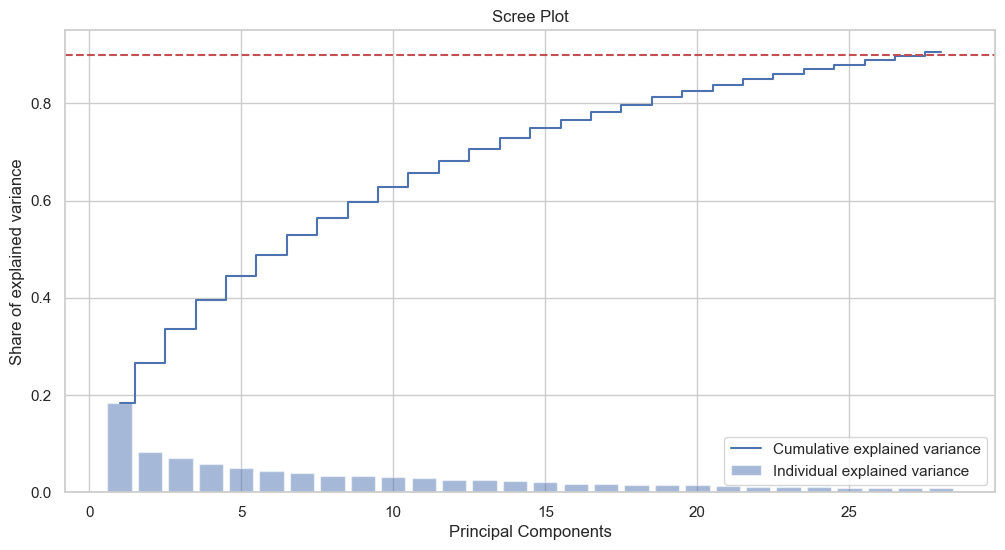

In [367]:
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
    
plt.figure(figsize=(12, 6))
    
plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.5, align='center',
            label='Individual explained variance')
    
plt.step(range(1, len(cum_var)+1), cum_var, where='mid',
             label='Cumulative explained variance')
    
plt.ylabel('Share of explained variance')
plt.xlabel('Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.title("Scree Plot")
plt.show()

This scree plot represents the share of explained variance depending on the number of principal components (PC). In general, explained variance is gradually increasing with growing number of PC. 

Since we want to save 90% of information and reduce dimentioality, PCA method suggests to use 28 components insted of 88 features. 

However, 28 PC is still quite a lot for clustering methods including kmeans and might lead to misleading results. 

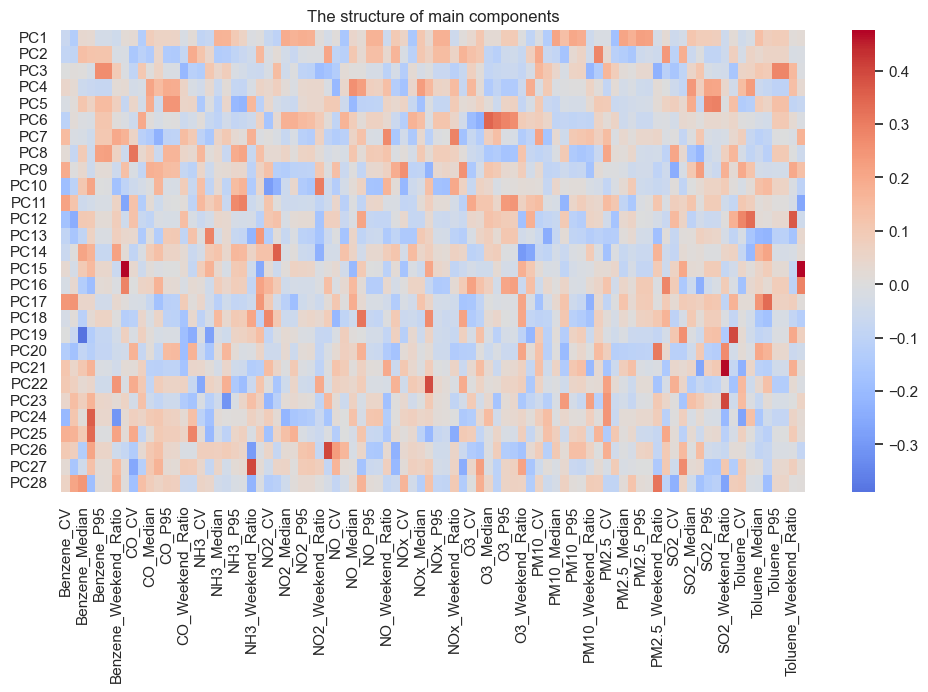

In [368]:
components_df = pd.DataFrame(
        pca.components_, 
        columns=station_profile_final.columns,
        index=[f'PC{i+1}' for i in range(pca.n_components_)]
    )
    
plt.figure(figsize=(12, 6))
sns.heatmap(components_df.head(28), cmap='coolwarm', center=0)
plt.title("The structure of main components")
plt.show()

In [369]:
print("\n--- Components structure ---")
for i in range(min(28, pca.n_components_)):
        pc_name = f'PC{i+1}'
        print(f"\n{pc_name} mainly depends on:")
        top_features = components_df.loc[pc_name].abs().sort_values(ascending=False).head(5)
        print(top_features)


--- Components structure ---

PC1 mainly depends on:
PM2.5_P95              0.221173
PM2.5_Range_P95_P05    0.219671
PM10_Median            0.212197
PM2.5_Median           0.206958
PM10_P95               0.200342
Name: PC1, dtype: float64

PC2 mainly depends on:
PM10_WinterSummer_Ratio     0.280620
PM2.5_WinterSummer_Ratio    0.239584
NO2_WinterSummer_Ratio      0.204271
PM10_CV                     0.197479
CO_WinterSummer_Ratio       0.190719
Name: PC2, dtype: float64

PC3 mainly depends on:
Toluene_Range_P95_P05    0.279225
Toluene_P95              0.278829
Benzene_Range_P95_P05    0.266883
Benzene_P95              0.266598
PM2.5_Weekend_Ratio      0.228646
Name: PC3, dtype: float64

PC4 mainly depends on:
NO_Median                 0.259040
SO2_Median                0.238280
Toluene_DayNight_Ratio    0.233465
NOx_Median                0.227183
NO_P05                    0.223473
Name: PC4, dtype: float64

PC5 mainly depends on:
SO2_Range_P95_P05    0.292239
SO2_P95              0.281

This graph represents the structure of 28 Principal Components showing from which initial variables (88 features) each PC is built.

### Defining number of clusters

Before clustering we need to define number of clusters. Mathematically, we can do it measuring the distance between data points within one cluster is smaller (Elbow method) and how well datapoints fit defined clusters (Silhouette method).

In [370]:
X_pca.shape

(110, 28)

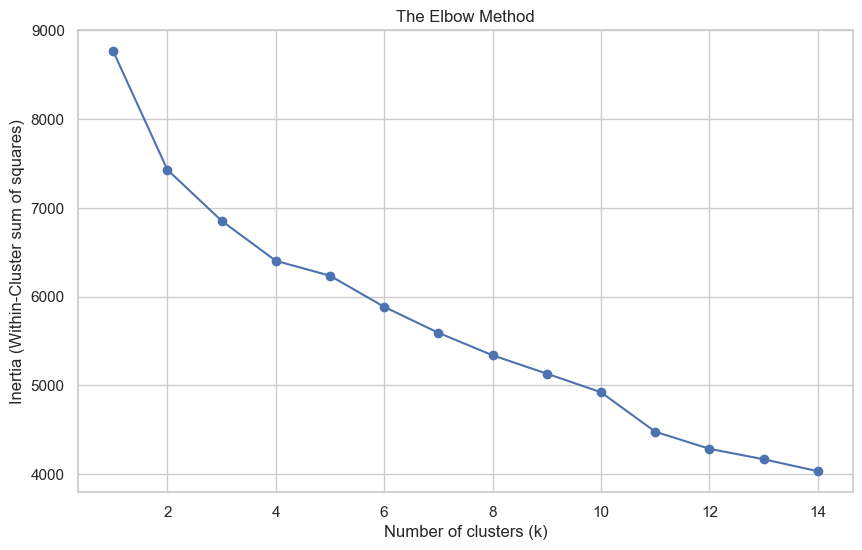

In [371]:
# Implementation and visual represetatio of Elbow method
inertia = [] # within-cluster sum of squares
K_range = range(1, 15)  # Test k from 1 to 15

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  # Use your PCA data (28 components)
    inertia.append(kmeans.inertia_)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster sum of squares)')
plt.show()

The elbow method shows that in general with growing number of clusters inertia is gradually decreasing, showing that distance between datapoits is reducing and clusters become tighter. However, there is no significant drop in inertia comming from one number of clusters to another. 

Therefore, we can not clearly define number of clusters solenly relying on the Elbow method. 

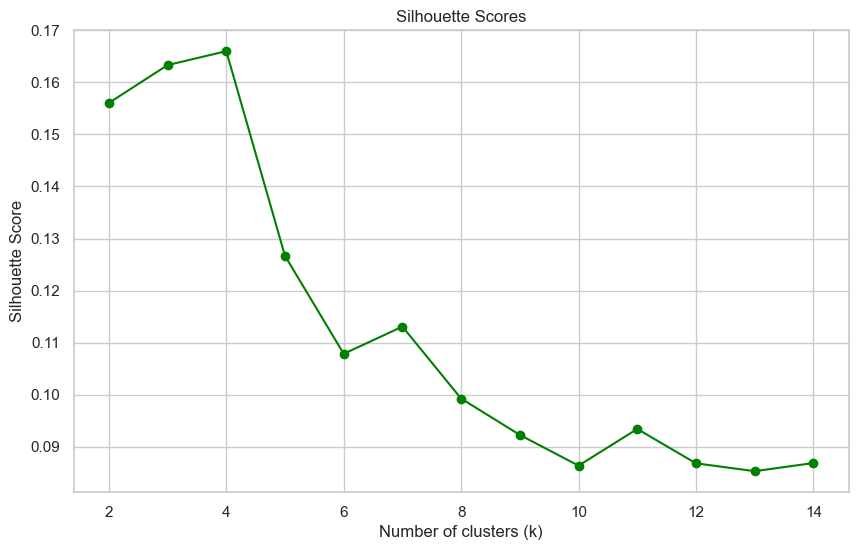

In [372]:
# Implementation and vizualization of Silhouette method 
silhouette_scores = []
K_range_sil = range(2, 15) 

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    
    # Calculate average score for this k
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

For Silhouette method, where the Silhouette score shows how well datapoints suit the defined number of clusters. The higher the silhouette score (the closer to 1) the better, meaning that the datapoints are closer to the datapoints from its own cluster and far away from the datapoints of the neighbouring cluster. The values close to 0 mean that the datapoints are closer to the neighbourig cluster rather than to the datapoints of its own cluster.

Although the silhouette method indicates k=4 as the most compact division, it was decided to retain the k=5 model as it provides a more detailed and practically applicable division of cities by environmental load types.s.

### Kmeans clustering (Ekaterina)

After reducing dimentionality using PCA method we have reduced number of features from 88 to 28 Principal components. However, 28 PC is still high dimentionality for clustering methods that might lead to inaccurate clustering. Therefore, not to lose information we Normalize Principal components values. 

Under Normalization we understand L2-regularization. Mathematically, Normalization (L2) scales all vectors to a unit length. This transformation ensures that K-Means groups stations based on the composition of pollutants (e.g., "High NO2 relative to PM10") rather than just the total volume of emissions. This allows us to cluster stations based on the pollution profile rather than on just emission volumes.

In [373]:
# Normalizing PC
transformer = Normalizer()
X_norm = transformer.fit_transform(X_pca)

In [374]:
# Creating, training and predicting clustering model
kmeans = KMeans(n_clusters=5, random_state=42)

labels = kmeans.fit_predict(X_norm) 

df_analysis = station_profile_final.copy()
df_analysis['Cluster'] = labels

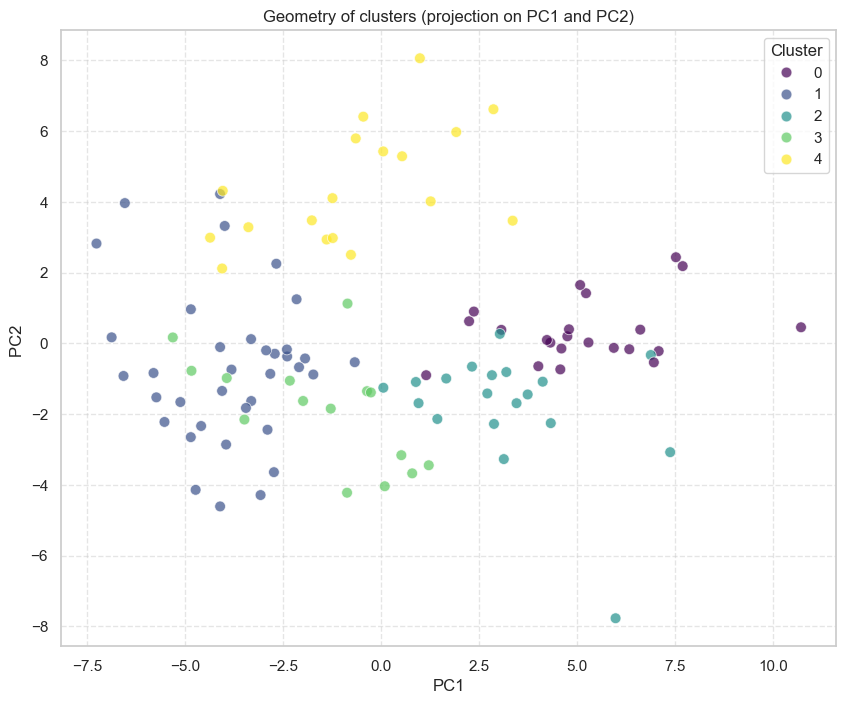

In [375]:
# Clustering results visualization in PC1 and PC2 dimentions
def plot_pca_clusters(X_pca, labels):
    plt.figure(figsize=(10, 8))
    
    pca_viz = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
    pca_viz['Cluster'] = labels
    
    sns.scatterplot(
        data=pca_viz, 
        x='PC1', 
        y='PC2', 
        hue='Cluster', 
        palette='viridis', 
        s=60,
        alpha=0.7
    )
    
    plt.title('Geometry of clusters (projection on PC1 and PC2)')
    plt.xlabel('PC1')
    plt.ylabel('PC2 ')
    plt.legend(title='Cluster')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_pca_clusters(X_pca, labels)

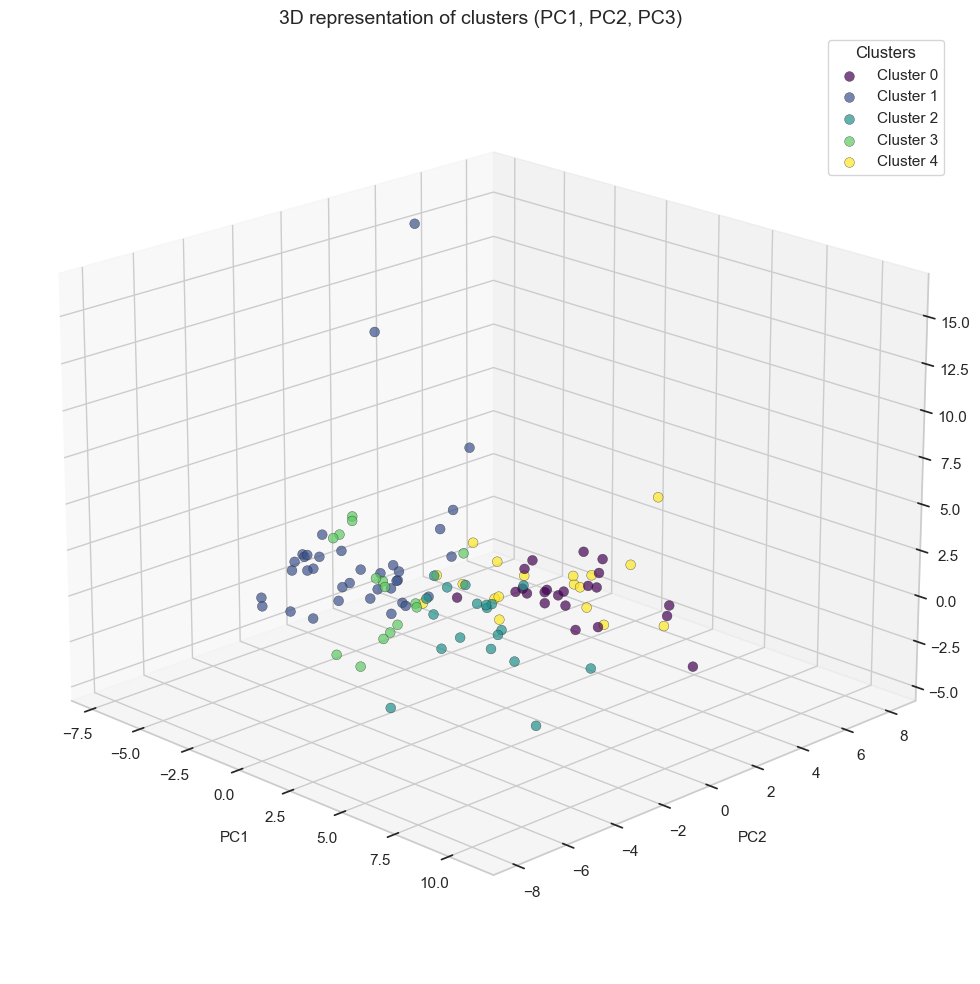

In [376]:
# Clustering results visualization in 3D (PC1, PC2 and PC3)
def plot_pca_clusters_3d(X_pca, labels):
    if X_pca.shape[1] < 3:
        print("Error: For this 3D graph minimum 3 PC needed in X_pca.")
        return

    pca_viz = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
    pca_viz['Cluster'] = labels

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
    
    for i, cluster_label in enumerate(unique_labels):
        cluster_data = pca_viz[pca_viz['Cluster'] == cluster_label]
        
        ax.scatter(
            xs=cluster_data['PC1'], 
            ys=cluster_data['PC2'], 
            zs=cluster_data['PC3'], 
            c=[colors[i]],           
            label=f'Cluster {cluster_label}',
            s=50,                    # dots size
            alpha=0.7,               # transparency
            edgecolor='k', linewidth=0.3 # thin outline for dots
        )

    ax.set_title('3D representation of clusters (PC1, PC2, PC3)', fontsize=14)
    ax.set_xlabel('PC1', fontsize=11, labelpad=10)
    ax.set_ylabel('PC2', fontsize=11, labelpad=10)
    ax.set_zlabel('PC3', fontsize=11, labelpad=10)

    ax.legend(title="Clusters", loc='best')
    
    ax.view_init(elev=20, azim=-45) 

    plt.tight_layout()
    plt.show()

plot_pca_clusters_3d(X_pca, labels)

In [377]:
# statistics for each cluster
clusters_stats = pd.DataFrame(df_analysis.groupby('Cluster').median()).reset_index()
clusters_stats

,Cluster,Benzene_CV,Benzene_DayNight_Ratio,Benzene_Median,Benzene_P05,Benzene_P95,Benzene_Range_P95_P05,Benzene_Weekend_Ratio,Benzene_WinterSummer_Ratio,CO_CV,...,SO2_Weekend_Ratio,SO2_WinterSummer_Ratio,Toluene_CV,Toluene_DayNight_Ratio,Toluene_Median,Toluene_P05,Toluene_P95,Toluene_Range_P95_P05,Toluene_Weekend_Ratio,Toluene_WinterSummer_Ratio
0,0,1.145472,0.775270,2.440,0.225,11.475,11.29025,0.924307,2.860542,0.797360,...,0.972262,1.315676,1.238710,0.769611,19.095,0.790000,89.068500,87.365250,0.923751,1.601468
1,1,2.552372,0.987214,0.260,0.000,3.430,3.33000,0.970573,2.117227,0.807803,...,0.990671,1.316415,2.196673,1.044218,0.955,0.000000,6.020000,5.970000,0.977413,1.189946
2,2,1.477322,0.769537,1.715,0.000,8.430,8.23450,0.974311,2.468133,1.387494,...,0.977608,1.395023,1.392695,0.749072,5.630,0.000000,42.657250,42.657250,0.965272,2.184232
3,3,1.851033,1.040221,0.600,0.000,5.320,5.32000,0.932218,2.142425,0.851854,...,0.991259,1.151680,2.043873,1.000309,1.450,0.000000,15.260000,15.260000,0.977336,2.009303
4,4,1.540098,0.848598,2.510,0.075,16.855,16.33150,0.933075,4.163771,0.892247,...,0.989192,2.147248,0.890798,0.740110,3.035,0.005113,13.746167,13.746167,0.942575,0.931580


### Surrogate Modeling: Decision Tree

Since kmeas algorithm is based on eucledian distance and it is complext to understand how this model works and which features it has used. Moreover, it is time consuming to analyze all 88 statisitcs that we got for each cluster.

Therefore, it is rational to use surrogate modeling or in other words aplly to dataset with clusters Decision Tree Classifier to make it explain rules for clusters definition. Decision Tree Algorithm defines most important features and creates if-then-else tree, based on which each of the clusters can be explained.

In [378]:
df_analysis

,Benzene_CV,Benzene_DayNight_Ratio,Benzene_Median,Benzene_P05,Benzene_P95,Benzene_Range_P95_P05,Benzene_Weekend_Ratio,Benzene_WinterSummer_Ratio,CO_CV,CO_DayNight_Ratio,...,SO2_WinterSummer_Ratio,Toluene_CV,Toluene_DayNight_Ratio,Toluene_Median,Toluene_P05,Toluene_P95,Toluene_Range_P95_P05,Toluene_Weekend_Ratio,Toluene_WinterSummer_Ratio,Cluster
AP001,10.426311,1.342539,0.10,0.000,0.9500,0.9500,1.280649,0.359991,0.837334,1.016512,...,1.303939,6.021660,0.835364,0.570,0.000000,6.420000,6.420000,0.707505,0.746560,1
AP005,0.843542,1.040221,3.35,0.000,10.2580,10.2580,0.960836,1.243953,0.952643,1.204046,...,0.874486,0.935681,0.937132,6.880,0.000000,22.200000,22.200000,0.986388,0.931504,3
AS001,5.483758,1.385683,0.23,0.000,6.5400,6.5400,0.583792,0.316034,0.852879,0.694451,...,1.080321,0.000000,1.000000,2.700,2.700000,2.700000,0.000000,1.000000,1.000000,4
BR005,1.309592,1.072803,1.54,0.000,10.6560,10.6560,1.076117,4.691126,0.967559,1.106268,...,4.070716,1.308010,1.114803,3.370,0.000000,9.803333,9.803333,0.968109,0.863160,4
BR006,1.227756,0.913135,1.31,0.000,7.6560,7.6560,1.068731,2.476243,0.445820,0.957317,...,1.348603,3.730559,1.134933,0.220,0.000000,1.130000,1.130000,0.944038,1.652368,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WB009,1.736672,0.652254,4.55,0.720,41.1700,40.4500,0.888983,1.567782,0.867852,0.765521,...,2.642833,1.371600,0.721608,12.300,0.180000,54.902500,54.722500,1.062004,3.295491,4
WB010,0.856149,0.791486,53.05,1.105,148.0100,146.9050,1.081652,1.972570,0.916642,0.741298,...,2.113585,1.020032,0.777325,48.050,4.271250,197.425000,193.153750,1.009623,2.418043,4
WB011,1.485939,0.696281,3.80,0.340,24.2560,23.9160,0.915902,2.410176,1.120099,0.817351,...,1.809660,1.379442,0.814383,7.280,0.663158,41.729000,41.065842,0.891790,1.238824,4
WB012,1.558430,0.715934,4.00,0.770,33.7275,32.9575,0.876466,5.218066,1.247608,0.907857,...,3.966425,1.280653,0.681604,6.385,1.200000,39.210000,38.010000,0.973219,3.815190,4


In [379]:
# defining relevant 88 features
features = df_analysis.columns.drop(['Cluster'])
features.shape

(88,)

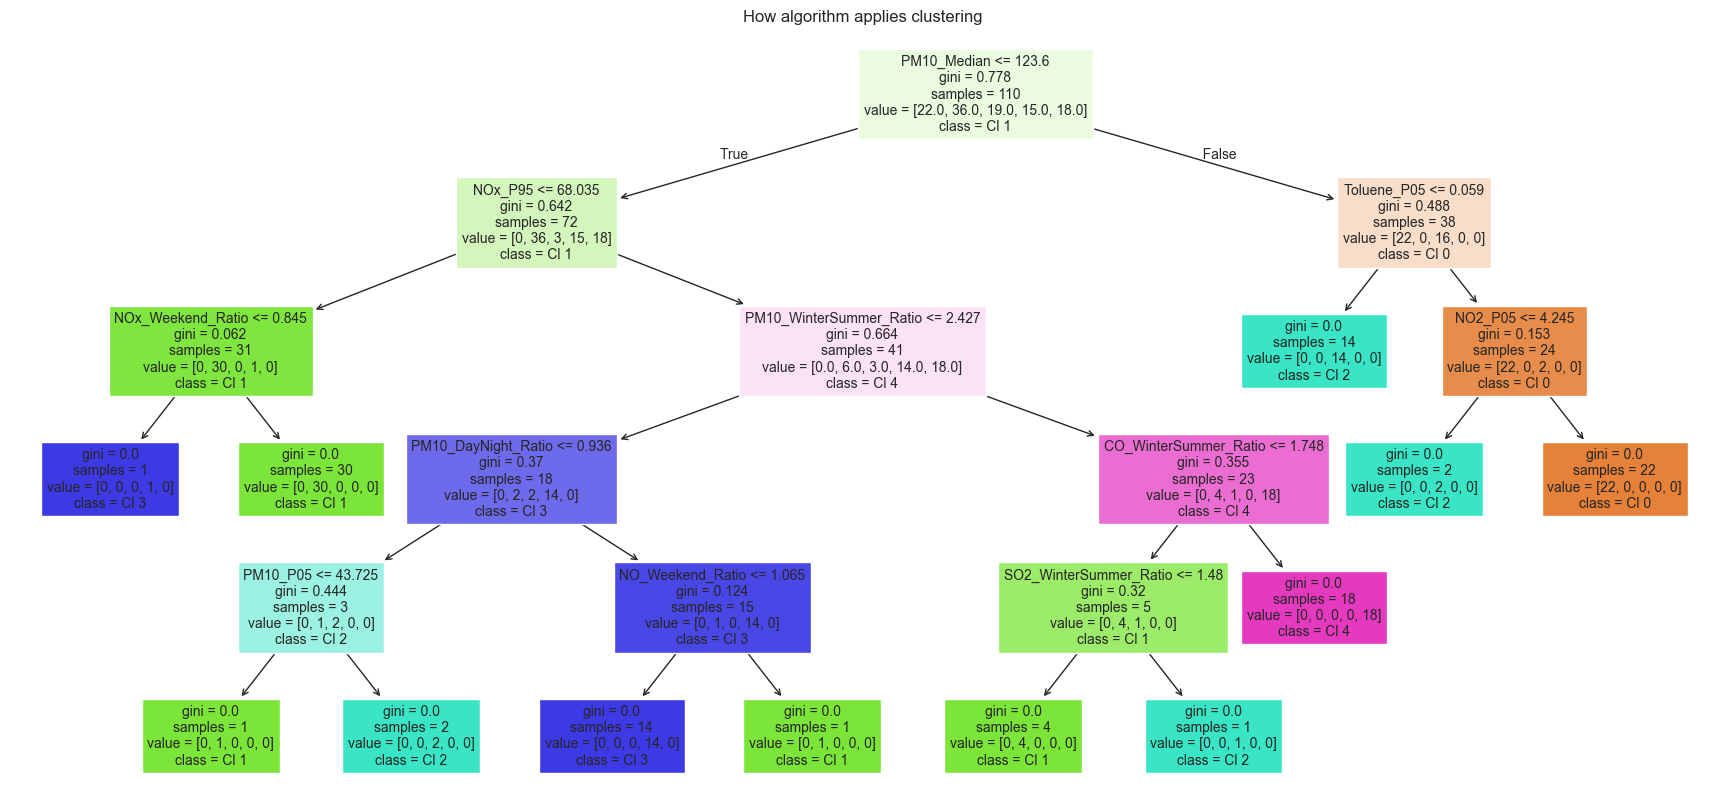

In [380]:
# Training Decision Tree classifier to reveal the rules for defining clusters
X_explain = df_analysis[features]
y_explain = df_analysis['Cluster']

# Constraining the tree depth by 4 to make it explainable
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_explain, y_explain)

# Vizualizing the model
plt.figure(figsize=(22, 10))
plot_tree(clf, feature_names=X_explain.columns, class_names=['Cl 0', 'Cl 1', 'Cl 2', 'Cl 3', 'Cl 4'], filled=True, fontsize=10)
plt.title("How algorithm applies clustering")
plt.show()

Since the K-Means algorithm partitions data based on multidimensional distances, the underlying logic behind each group's formation can be opaque. To uncover this logic and interpret the resulting clusters, we trained a Decision Tree Classifier as a surrogate model. The original pollution data served as features, while the cluster labels assigned by K-Means served as the target variable.

The tree visualization reveals the hierarchy of feature importance. The Root Node is defined by PM10_Median. This indicates that the median level of PM10 particulate matter is the strongest discriminator, splitting the monitoring stations into two major groups:

- If PM10_Median <= 123.6 (Left branch): The station is highly likely to belong to Clusters 1, 3, or 4.
- If PM10_Median > 123.6 (Right branch): The station is most likely associated with Clusters 0 or 2.

Subsequently, the split continues based on gaseous composition:

- For stations with lower PM10 (Left branch): The key factor becomes NOx_P95 (Nitrogen Oxides). This distinguishes Cluster 1 (likely cleaner or exhibiting specific characteristics) from Clusters 3 and 4.
- For stations with higher PM10 (Right branch): Toluene_P05 acts as the defining variable, differentiating between Cluster 0 and Cluster 2.

Consequently, the Decision Tree enabled us to derive clear profiles for each cluster. We observed that the classification depends not only on absolute concentration values but also on seasonality (evidenced by WinterSummer_Ratio features at deeper levels). This finding validates our hypothesis regarding the seasonal nature of pollution patterns.

### Clusters description

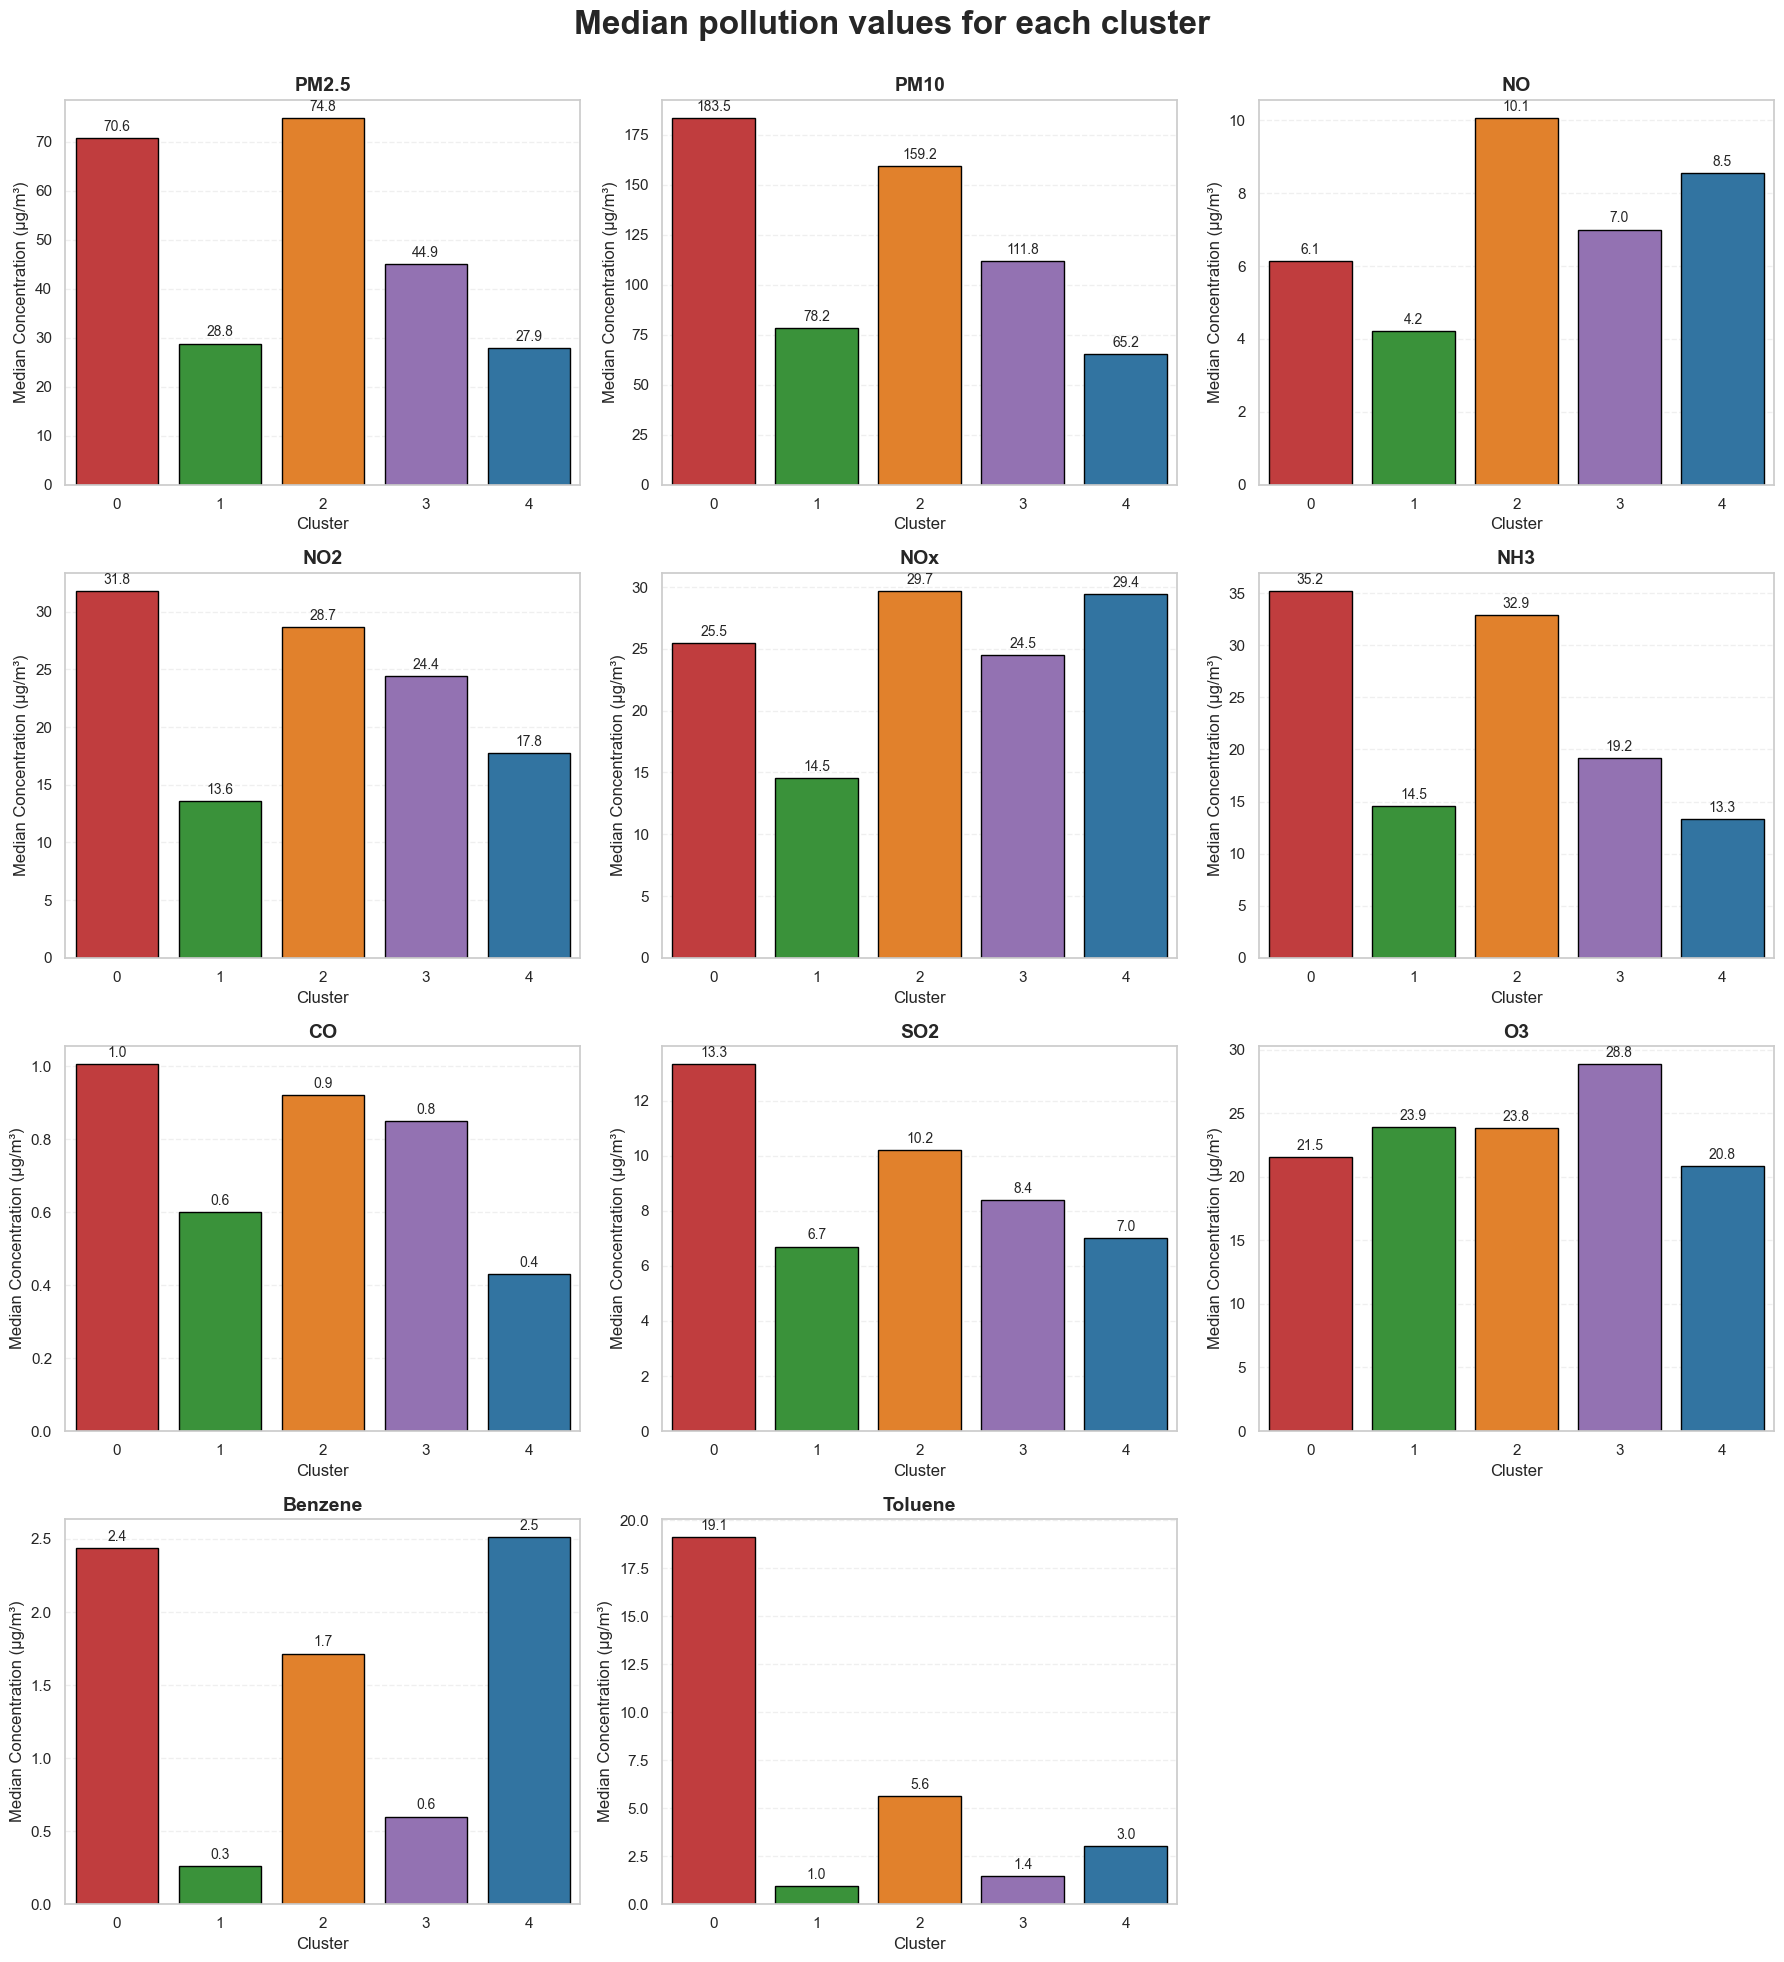

In [381]:
# Clusters statistics visualization 
clusters_stats['Cluster'] = clusters_stats['Cluster'].astype(int)

pollutants = [
    'PM2.5_Median', 'PM10_Median', 
    'NO_Median', 'NO2_Median', 'NOx_Median', 
    'NH3_Median', 'CO_Median', 'SO2_Median', 
    'O3_Median', 'Benzene_Median', 'Toluene_Median'
]

n_cols = 3
n_rows = math.ceil(len(pollutants) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

cluster_colors = {
    0: '#d62728', # Red (Toxic)
    1: '#2ca02c', # Green (Clean)
    2: '#ff7f0e', # Orange (Dust)
    3: '#9467bd', # Purple (Ozone)
    4: '#1f77b4'  # Blue (Benzene)
}

for i, col_name in enumerate(pollutants):
    if col_name in clusters_stats.columns:
        barplot = sns.barplot(
            data=clusters_stats, 
            x='Cluster', 
            y=col_name, 
            hue='Cluster',         
            ax=axes[i],
            palette=cluster_colors,
            edgecolor='black',
            legend=False         
        )
        
        axes[i].set_title(col_name.replace('_Median', ''), fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Median Concentration (µg/m³)')
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        for container in barplot.containers:
            axes[i].bar_label(container, fmt='%.1f', padding=3, fontsize=10)
            
    else:
        axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Median pollution values for each cluster', fontsize=24, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [382]:
cluster_profile = clusters_stats[pollutants]
cluster_profile

,PM2.5_Median,PM10_Median,NO_Median,NO2_Median,NOx_Median,NH3_Median,CO_Median,SO2_Median,O3_Median,Benzene_Median,Toluene_Median
0,70.636364,183.4575,6.125000,31.780000,25.475,35.20000,1.005,13.3250,21.5300,2.440,19.095
1,28.785000,78.2175,4.225000,13.610000,14.515,14.54000,0.600,6.7025,23.9000,0.260,0.955
2,74.825000,159.1550,10.065000,28.691897,29.670,32.88619,0.920,10.2000,23.8375,1.715,5.630
3,44.920000,111.8300,7.000000,24.440000,24.470,19.16000,0.850,8.4000,28.8450,0.600,1.450
4,27.940000,65.2150,8.548576,17.772500,29.440,13.32500,0.430,7.0250,20.8425,2.510,3.035


In [383]:
df_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

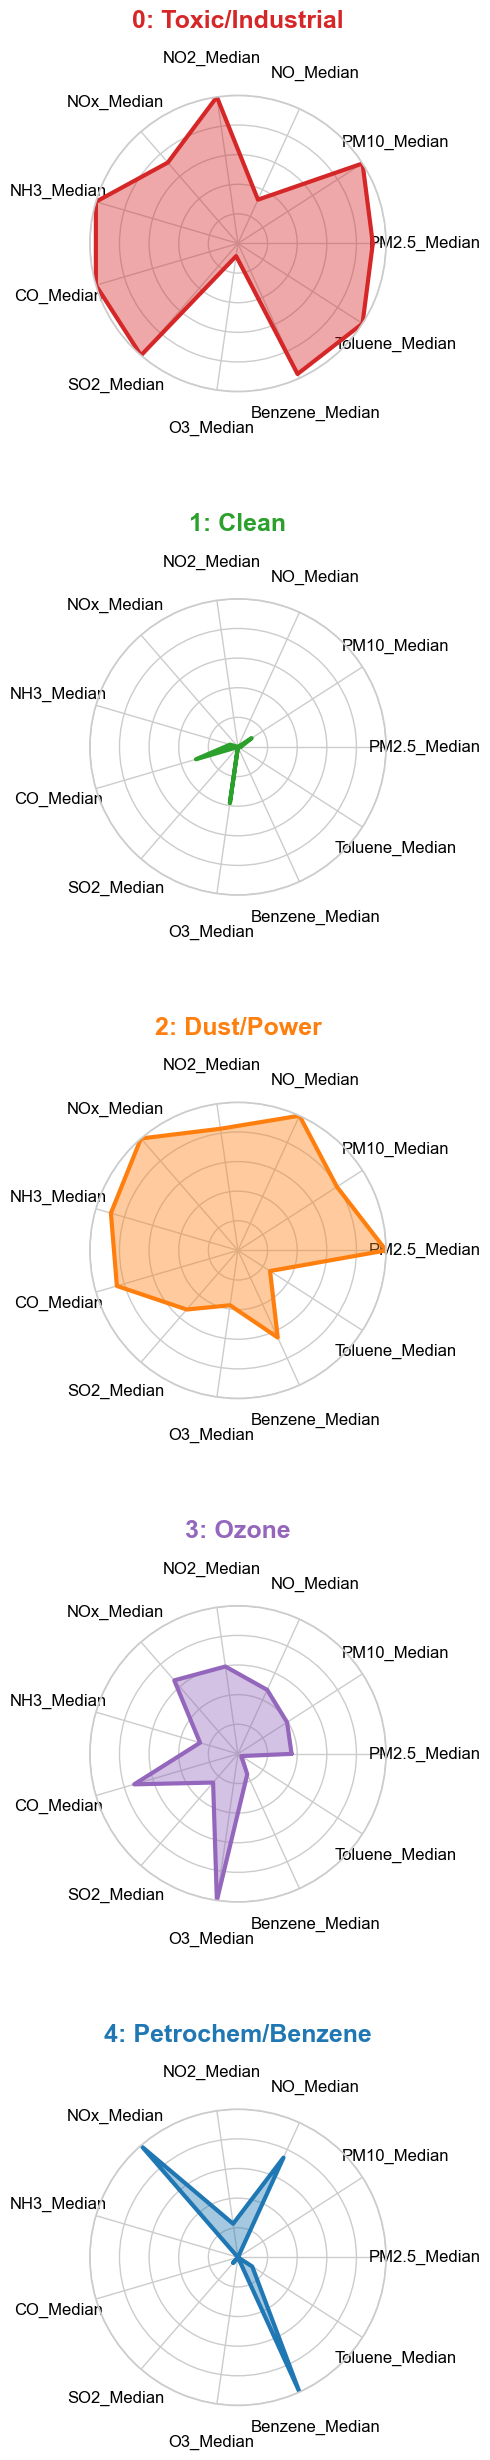

In [384]:
categories = list(df_norm.columns)
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Замыкаем круг

colors = ['#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#1f77b4']
cluster_labels = [
    '0: Toxic/Industrial', 
    '1: Clean', 
    '2: Dust/Power', 
    '3: Ozone', 
    '4: Petrochem/Benzene'
]

fig, ax = plt.subplots(5, 1, figsize=(10, 30), subplot_kw=dict(polar=True))

for i, cluster_id in enumerate(df_norm.index):
    values = df_norm.loc[cluster_id].values.flatten().tolist()
    values += values[:1]
    
    ax[i].plot(angles, values, linewidth=3, linestyle='solid', color=colors[i])
    ax[i].fill(angles, values, color=colors[i], alpha=0.4)
    
    ax[i].set_xticks(angles[:-1])
    ax[i].set_xticklabels(categories, size=12, color='black') 
    ax[i].tick_params(axis='x', pad=15) 
    
    ax[i].set_yticklabels([])
    ax[i].set_ylim(0, 1)
    
    ax[i].set_title(cluster_labels[i], size=18, color=colors[i], fontweight='bold', y=1.2)

plt.subplots_adjust(hspace=0.7)

plt.show()

**Clusters description**
- **0 cluster: Toxic Industrial Emissions Area**: This is the most chemically toxic cluster. It exhibits Toluene levels 30-40 times higher than the background level.

Dominant Pollutants: Toluene (Median: 20.4 $\mu g/m^3$, P95: 88.6), NH3, PM10.

- **1 cluster: Clean Air Zone:** Lowest values across all metrics. Minimal. These stations represent the target air quality standards.

- **2 cluster: Dust and Power Generation Area:** Coal-fired thermal power plants, heavy industry (metallurgy), and brick kilns. Also includes arid cities with high road dust re-suspension.

Dominant Pollutants: PM2.5 (Highest: 80.7 $\mu g/m^3$), SO2 (Highest: 11.1), PM10.

- **3 cluster: Ozone Zone:** A unique cluster where primary pollutants (PM, SO2) are moderate, but secondary pollutants (Ozone) are maximized.

Dominant Pollutants: Ozone

- **4 cluster: Petrochemical & Vehicular Area:** Oil refineries, fuel storage depots, petrol pumps, or intense vehicular traffic (fuel evaporation and exhaust) without associated construction dust.



### Superimposition: comming from station to city level

In [385]:
station_meta = station_hour[['StationId', 'StationName', 'City', 'State']]
station_grouped = station_meta.drop_duplicates(subset=['StationId']).reset_index(drop=True)

station_grouped.head()

,StationId,StationName,City,State
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh
1,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh
2,AS001,"Railway Colony, Guwahati - APCB",Guwahati,Assam
3,BR005,"DRM Office Danapur, Patna - BSPCB",Patna,Bihar
4,BR006,"Govt. High School Shikarpur, Patna - BSPCB",Patna,Bihar


In [386]:
df_analysis = df_analysis.merge(station_grouped, 
                  left_index=True,
                 right_on = 'StationId')

In [387]:
city_cluster_counts = pd.crosstab(
    index=df_analysis['City'], 
    columns=df_analysis['Cluster'],
    margins=True,
    margins_name="Total"
)

city_cluster_counts = city_cluster_counts.sort_values('Total', ascending=False)

city_cluster_counts

Cluster,0,1,2,3,4,Total
City,,,,,,
Total,22,36,19,15,18,110
Delhi,22,0,16,0,0,38
Bengaluru,0,8,0,2,0,10
Mumbai,0,3,0,0,7,10
Kolkata,0,0,0,0,7,7
Hyderabad,0,6,0,0,0,6
Patna,0,1,0,2,3,6
Lucknow,0,0,0,5,0,5
Gurugram,0,2,2,0,0,4


In [388]:
city_cluster_shares = pd.crosstab(
    index=df_analysis['City'], 
    columns=df_analysis['Cluster'],
    normalize='index'
)

city_cluster_percentages = (city_cluster_shares * 100).round(1)
city_cluster_percentages

city_cluster_percentages.merge(city_cluster_counts, on='City')

Cluster,0_x,1_x,2_x,3_x,4_x,0_y,1_y,2_y,3_y,4_y,Total
City,,,,,,,,,,,
Ahmedabad,0.0,0.0,100.0,0.0,0.0,0,0,1,0,0,1
Aizawl,0.0,100.0,0.0,0.0,0.0,0,1,0,0,0,1
Amaravati,0.0,100.0,0.0,0.0,0.0,0,1,0,0,0,1
Amritsar,0.0,100.0,0.0,0.0,0.0,0,1,0,0,0,1
Bengaluru,0.0,80.0,0.0,20.0,0.0,0,8,0,2,0,10
Bhopal,0.0,100.0,0.0,0.0,0.0,0,1,0,0,0,1
Brajrajnagar,0.0,100.0,0.0,0.0,0.0,0,1,0,0,0,1
Chandigarh,0.0,100.0,0.0,0.0,0.0,0,1,0,0,0,1
Chennai,0.0,100.0,0.0,0.0,0.0,0,4,0,0,0,4


In [389]:
# distribution of clusters among the variables
city_cluster_total = city_cluster_counts.merge(city_cluster_percentages, on='City')
city_cluster_total = city_cluster_total.rename(columns = {
    '0_x':'0_cnt', 
    '1_x':'1_cnt', 
    '2_x':'2_cnt', 
    '3_x':'3_cnt',
    '4_x':'4_cnt', 
    'Total':'Total_cnt', 
    '0_y':'0_share', 
    '1_y':'1_share', 
    '2_y':'2_share',
    '3_y':'3_share', 
    '4_y':'4_share'
})
city_cluster_total = city_cluster_total[['0_cnt', '0_share', 
                                         '1_cnt', '1_share', 
                                         '2_cnt', '2_share', 
                                         '3_cnt', '3_share', 
                                         '4_cnt', '4_share',
                                         'Total_cnt']]
city_cluster_total

Cluster,0_cnt,0_share,1_cnt,1_share,2_cnt,2_share,3_cnt,3_share,4_cnt,4_share,Total_cnt
City,,,,,,,,,,,
Delhi,22,57.9,0,0.0,16,42.1,0,0.0,0,0.0,38
Bengaluru,0,0.0,8,80.0,0,0.0,2,20.0,0,0.0,10
Mumbai,0,0.0,3,30.0,0,0.0,0,0.0,7,70.0,10
Kolkata,0,0.0,0,0.0,0,0.0,0,0.0,7,100.0,7
Hyderabad,0,0.0,6,100.0,0,0.0,0,0.0,0,0.0,6
Patna,0,0.0,1,16.7,0,0.0,2,33.3,3,50.0,6
Lucknow,0,0.0,0,0.0,0,0.0,5,100.0,0,0.0,5
Gurugram,0,0.0,2,50.0,2,50.0,0,0.0,0,0.0,4
Chennai,0,0.0,4,100.0,0,0.0,0,0.0,0,0.0,4


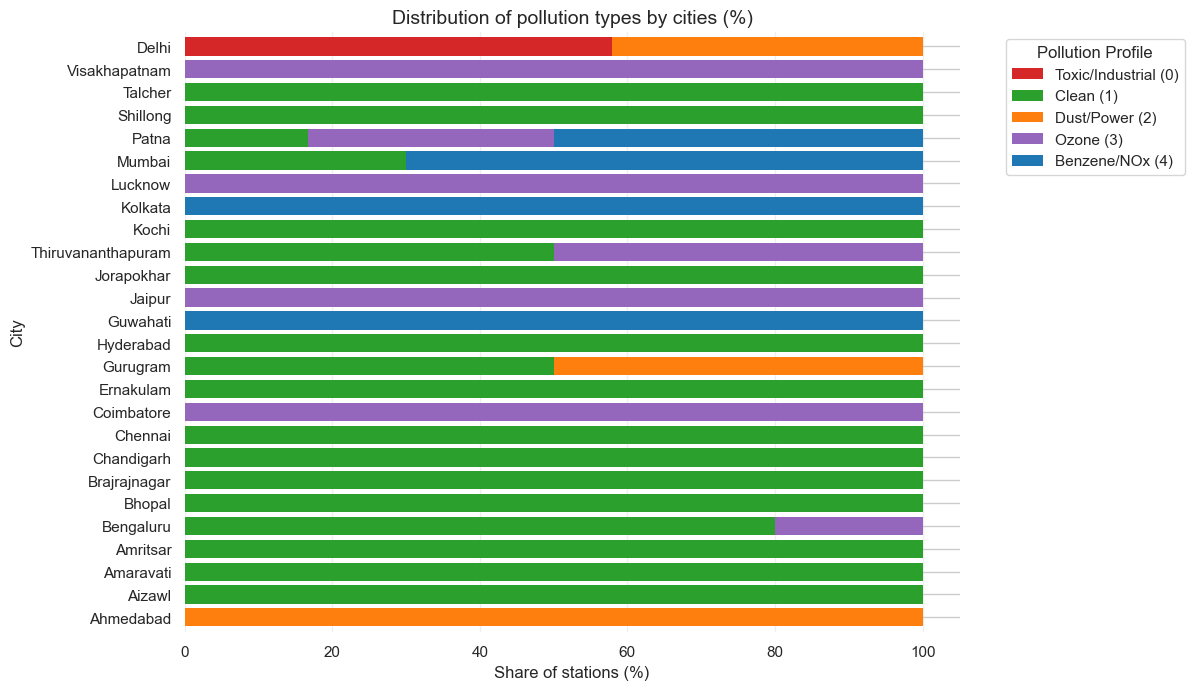

In [390]:
# city pollution structure visualization
cluster_names = {
    0: 'Toxic/Industrial (0)',
    1: 'Clean (1)',
    2: 'Dust/Power (2)',
    3: 'Ozone (3)',
    4: 'Benzene/NOx (4)'
}

df_plot = city_cluster_percentages.rename(columns=cluster_names)

target_name = cluster_names[0] 
df_plot = df_plot.sort_values(by=target_name, ascending=True)

named_colors = {cluster_names[k]: v for k, v in cluster_colors.items()}
my_colors = [named_colors.get(c, '#333333') for c in df_plot.columns]

ax = df_plot.plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, len(df_plot)*0.3),
    color=my_colors,
    edgecolor='none',
    width=0.8
)

plt.title('Distribution of pollution types by cities (%)', fontsize=14)
plt.xlabel('Share of stations (%)')
plt.ylabel('City')
plt.legend(title='Pollution Profile', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
sns.despine(left=True, bottom=True)

plt.show()

In [391]:
# creates pie chart representing each city emission structure
def make_pie_svg(data, colors, radius=20):
    total = sum(data)
    if total == 0:
        return ""

    cx = radius
    cy = radius
    
    if any(v == total for v in data):
        color = colors[data.index(total)]
        return f'<svg width="{radius*2}" height="{radius*2}"><circle cx="{cx}" cy="{cy}" r="{radius}" fill="{color}" /></svg>'

    paths = []
    start_angle = 0
    
    for value, color in zip(data, colors):
        if value <= 0:
            continue
            
        percentage = value / total
        angle = percentage * 2 * math.pi
        end_angle = start_angle + angle
        
        x1 = cx + radius * math.cos(start_angle)
        y1 = cy + radius * math.sin(start_angle)
        x2 = cx + radius * math.cos(end_angle)
        y2 = cy + radius * math.sin(end_angle)
        
        large_arc = 1 if angle > math.pi else 0
        
        path = f'<path d="M{cx},{cy} L{x1},{y1} A{radius},{radius} 0 {large_arc},1 {x2},{y2} z" fill="{color}" stroke="white" stroke-width="1"/>'
        paths.append(path)
        start_angle = end_angle

    return f'<svg width="{radius*2}" height="{radius*2}" style="transform: rotate(-90deg)">{"".join(paths)}</svg>'
    

In [392]:
city_coords_dict = {
    'Ahmedabad': [23.0225, 72.5714],
    'Aizawl': [23.7271, 92.7176],
    'Amaravati': [16.5062, 80.6480],
    'Amritsar': [31.6340, 74.8723],
    'Bengaluru': [12.9716, 77.5946],
    'Bhopal': [23.2599, 77.4126],
    'Brajrajnagar': [21.8217, 83.9261],
    'Chandigarh': [30.7333, 76.7794],
    'Chennai': [13.0827, 80.2707],
    'Coimbatore': [11.0168, 76.9558],
    'Delhi': [28.7041, 77.1025],
    'Ernakulam': [9.9816, 76.2999],
    'Gurugram': [28.4595, 77.0266],
    'Guwahati': [26.1445, 91.7362],
    'Hyderabad': [17.3850, 78.4867],
    'Jaipur': [26.9124, 75.7873],
    'Jorapokhar': [23.7000, 86.4100],
    'Kochi': [9.9312, 76.2673],
    'Kolkata': [22.5726, 88.3639],
    'Lucknow': [26.8467, 80.9462],
    'Mumbai': [19.0760, 72.8777],
    'Patna': [25.5941, 85.1376],
    'Shillong': [25.5788, 91.8933],
    'Talcher': [20.9500, 85.2300],
    'Thiruvananthapuram': [8.5241, 76.9366],
    'Visakhapatnam': [17.6868, 83.2185]
}

coords = pd.DataFrame.from_dict(city_coords_dict, orient='index', columns=['Latitude', 'Longitude'])
coords.index.name = 'City'

data_for_map = city_cluster_percentages.join(coords, how='inner')

In [393]:
colors_list = [
    '#d62728', # 0: Red (Toxic)
    '#2ca02c', # 1: Green (Clean)
    '#ff7f0e', # 2: Orange (Dust)
    '#9467bd', # 3: Purple (Ozone)
    '#1f77b4'  # 4: Blue (Benzene)
]

m = folium.Map(location=[22.0, 79.0], zoom_start=5, tiles='CartoDB positron')

for city_name, row in data_for_map.iterrows():
    lat, lon = row['Latitude'], row['Longitude']
    
    values = row[[0, 1, 2, 3, 4]].values.tolist()
    
    # SVG
    svg_html = make_pie_svg(values, colors_list, radius=20)
    
    # Popup
    popup_text = f"""
    <div style="font-family: Arial; width: 150px;">
        <b>{city_name}</b><br><br>
        <span style="color:{colors_list[0]}">■</span> Toxic: {row[0]:.0f}%<br>
        <span style="color:{colors_list[1]}">■</span> Clean: {row[1]:.0f}%<br>
        <span style="color:{colors_list[2]}">■</span> Dust: {row[2]:.0f}%<br>
        <span style="color:{colors_list[3]}">■</span> Ozone: {row[3]:.0f}%<br>
        <span style="color:{colors_list[4]}">■</span> Benzene: {row[4]:.0f}%
    </div>
    """
    
    folium.Marker(
        location=[lat, lon],
        icon=DivIcon(
            icon_size=(40, 40),
            icon_anchor=(20, 20),
            html=f'<div style="background:none;">{svg_html}</div>'
        ),
        popup=folium.Popup(popup_text, max_width=200)
    ).add_to(m)

    folium.Marker(
        location=[lat, lon],
        icon=DivIcon(
            icon_size=(100, 20),
            icon_anchor=(50, -25),
            html=f'<div style="font-size: 8pt; font-weight: bold; text-align: center; text-shadow: 1px 1px 1px white;">{city_name}</div>'
        )
    ).add_to(m)

m

## Strategic Network Optimization: Kriging-Based Information Gain Analysis

While clustering and decision trees identify what factors drive air pollution, Kriging Variance reveals where our conclusions lack reliability due to data scarcity. We utilize Kriging variance as a metric of spatial uncertainty to mathematically justify the expansion of the monitoring network. By proposing new stations in these 'informational vacuums,' we bridge the gap necessary to validate our environmental policy recommendations on a truly national scale.

In our project, Kriging acts as a spatial diagnostic tool. While our Decision Tree identifies the chemical drivers of pollution, Kriging identifies the geographical gaps. By mapping the Kriging Variance, we can mathematically pinpoint "Blind Spots" where new sensors are required to ensure our environmental insights are statistically valid across the entire country.

In [394]:
# Gathering coordinates for the cities from our statuion_hour dataset
city_coords_dict = {
    'Ahmedabad': [23.0225, 72.5714],
    'Aizawl': [23.7271, 92.7176],
    'Amaravati': [16.5062, 80.6480],
    'Amritsar': [31.6340, 74.8723],
    'Bengaluru': [12.9716, 77.5946],
    'Bhopal': [23.2599, 77.4126],
    'Brajrajnagar': [21.8217, 83.9261],
    'Chandigarh': [30.7333, 76.7794],
    'Chennai': [13.0827, 80.2707],
    'Coimbatore': [11.0168, 76.9558],
    'Delhi': [28.7041, 77.1025],
    'Ernakulam': [9.9816, 76.2999],
    'Gurugram': [28.4595, 77.0266],
    'Guwahati': [26.1445, 91.7362],
    'Hyderabad': [17.3850, 78.4867],
    'Jaipur': [26.9124, 75.7873],
    'Jorapokhar': [23.7000, 86.4100],
    'Kochi': [9.9312, 76.2673],
    'Kolkata': [22.5726, 88.3639],
    'Lucknow': [26.8467, 80.9462],
    'Mumbai': [19.0760, 72.8777],
    'Patna': [25.5941, 85.1376],
    'Shillong': [25.5788, 91.8933],
    'Talcher': [20.9500, 85.2300],
    'Thiruvananthapuram': [8.5241, 76.9366],
    'Visakhapatnam': [17.6868, 83.2185]
}

In [395]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 29 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Datetime          datetime64[ns]
 1   StationId         object        
 2   PM2.5             float64       
 3   PM10              float64       
 4   NO                float64       
 5   NO2               float64       
 6   NOx               float64       
 7   NH3               float64       
 8   CO                float64       
 9   SO2               float64       
 10  O3                float64       
 11  Benzene           float64       
 12  Toluene           float64       
 13  Date              object        
 14  Time              int32         
 15  Month             int32         
 16  Weekday           int32         
 17  Time_Period       category      
 18  StationName       object        
 19  City              object        
 20  State             object        
 21  Status  

For the spatial interpolation (criging) we are leveraging the insights from our Decision Tree, where $PM_{2.5}$ emerged as the dominant predictor. Therefore, we decided to focus on specific polutant (that plays critical role for clustering rather than aggregated AQI value). This ensures that our identification of 'informational blind spots' is prioritized for the factor that contributes most significantly to air pollution across the region.

In [396]:
kriging_df = df_clean.groupby('City')['PM2.5'].mean().reset_index()
kriging_df

,City,PM2.5
0,Ahmedabad,67.387993
1,Aizawl,16.878336
2,Amaravati,36.728470
3,Amritsar,55.943372
4,Bengaluru,35.012576
5,Bhopal,49.410629
6,Brajrajnagar,61.966498
7,Chandigarh,40.501766
8,Chennai,48.134555
9,Coimbatore,29.504402


In [397]:
# Map geographical coordinates to each city in the dataframe using a predefined dictionary
# city_coords_dict.get(x, [None, None]) provides a fallback to [None, None] if a city is missing from the dictionary
kriging_df['Lat'] = kriging_df['City'].map(lambda x: city_coords_dict.get(x, [None, None])[0])
kriging_df['Lon'] = kriging_df['City'].map(lambda x: city_coords_dict.get(x, [None, None])[1])

In [398]:
kriging_df

,City,PM2.5,Lat,Lon
0,Ahmedabad,67.387993,23.0225,72.5714
1,Aizawl,16.878336,23.7271,92.7176
2,Amaravati,36.728470,16.5062,80.6480
3,Amritsar,55.943372,31.6340,74.8723
4,Bengaluru,35.012576,12.9716,77.5946
5,Bhopal,49.410629,23.2599,77.4126
6,Brajrajnagar,61.966498,21.8217,83.9261
7,Chandigarh,40.501766,30.7333,76.7794
8,Chennai,48.134555,13.0827,80.2707
9,Coimbatore,29.504402,11.0168,76.9558


In [399]:
lons = kriging_df['Lon'].values
lats = kriging_df['Lat'].values
z = kriging_df['PM2.5'].values

The model that we initialize below uses Latitude and Longitude to define the geographical context of our monitoring network. By analyzing the distance between stations and the variance in $PM_{2.5}$ levels, the algorithm determines the mathematical correlation of air quality over space. This allows us to interpolate a continuous surface, transforming discrete city-level data into a comprehensive national map while simultaneously identifying regions where the lack of nearby data points creates high uncertainty.

In [400]:
# Initialize the Ordinary Kriging model using longitude, latitude, and the target variable (PM2.5)
# 'spherical' variogram_model: A standard model that assumes spatial correlation decreases 
# with distance and eventually reaches zero at a specific range.
OK = OrdinaryKriging(
    lons, lats, z, 
    variogram_model='spherical',
    verbose=False, 
    enable_plotting=False
)

In [401]:
# Define the spatial extent and resolution of the interpolation grid
# We add a +/- 5 degree buffer to the min/max coordinates of our stations 
# to ensure the heatmap covers the entire national territory of India.
grid_lon = np.linspace(lons.min() - 5, lons.max() + 5, 150)
grid_lat = np.linspace(lats.min() - 5, lats.max() + 5, 150)

In [402]:
# Execute the Ordinary Kriging interpolation over the defined grid
# z_pred: The predicted PM2.5 levels for every pixel in the grid
# ss_variance: The estimation error (uncertainty) for every pixel
z_pred, ss_variance = OK.execute('grid', grid_lon, grid_lat)

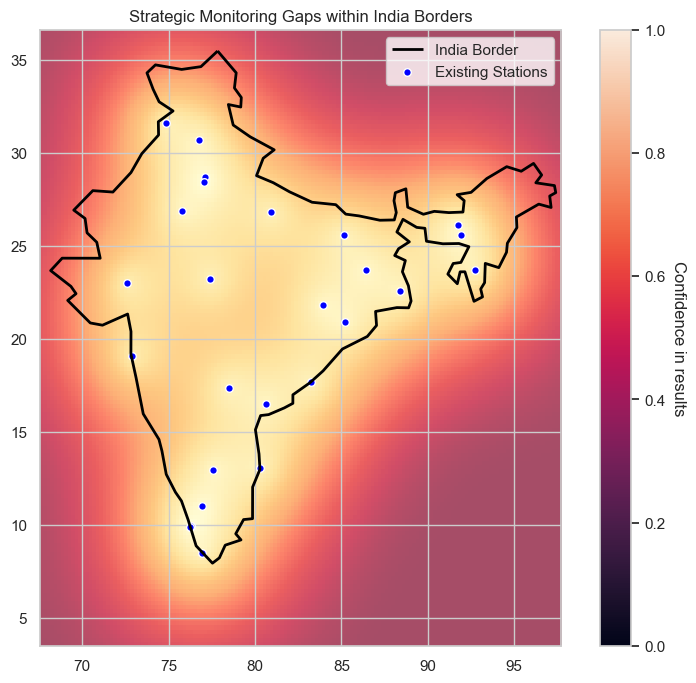

In [403]:
# Link to a file with the borders of countries around the world
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"

# Download data directly from the Internet
world = gpd.read_file(url)

# Filter for India (in this file the column is called 'name')
india_border = world[world['name'] == "India"]


plt.figure(figsize=(10, 8))

# Оставляем YlOrRd: желтый (0) - низкая ошибка, красный (1) - высокая
plt.imshow(ss_variance, extent=(grid_lon.min(), grid_lon.max(), grid_lat.min(), grid_lat.max()), 
           origin='lower', cmap='YlOrRd', alpha=0.7)

india_border.boundary.plot(ax=plt.gca(), color='black', linewidth=2, label='India Border')

plt.scatter(lons, lats, c='blue', marker='o', s=30, label='Existing Stations', edgecolors='white')

if 'final_spots' in locals():
    fs_lats, fs_lons = zip(*final_spots)
    plt.scatter(fs_lons, fs_lats, c='green', marker='X', s=150, label='Proposed Stations')

cbar = plt.colorbar()
cbar.set_label('Confidence in results', rotation=270, labelpad=15)

plt.title('Strategic Monitoring Gaps within India Borders')
plt.legend()
plt.show()

In [404]:
# Generate a unified geometry of India's borders
india_geom = india_border.geometry.union_all()

# Create a boolean grid with the same shape as your Kriging results
mask = np.zeros(ss_variance.shape, dtype=bool)

# Fill the mask: True if coordinates are inside India, False otherwise
for i, lat in enumerate(grid_lat):
    for j, lon in enumerate(grid_lon):
        if india_geom.contains(Point(lon, lat)):
            mask[i, j] = True

# 2. Теперь нормализуем данные и считаем индекс покрытия
# Scale variance between 0 and 1 for consistent measurement
max_val = ss_variance.max()
min_val = ss_variance.min()
normalized_variance = (ss_variance - min_val) / (max_val - min_val)

# Apply the mask to isolate inland data
internal_norm_variance = normalized_variance[mask]

# Calculate final metrics
avg_uncertainty = np.mean(internal_norm_variance)
coverage_index = 1 - avg_uncertainty

print(f"Average normalized uncertainty: {avg_uncertainty:.2f}")
print(f"India's Area Coverage Index (0-1): {coverage_index:.2f}")

Average normalized uncertainty: 0.27
India's Area Coverage Index (0-1): 0.73


In [405]:
# Consolidate India's geographic boundaries into a single geometry object for spatial filtering
# Using union_all() to create a unified polygon
india_geom = india_border.geometry.union_all()

# Initialize a boolean mask with the same dimensions as the Kriging variance matrix (ss_variance)
# This mask will distinguish between points inside India (True) and points outside (False)
mask = np.zeros(ss_variance.shape, dtype=bool)

# Perform a spatial join by iterating through the interpolation grid
# Checking if each grid point (lon, lat) falls within the national borders of India
for i, lat in enumerate(grid_lat):
    for j, lon in enumerate(grid_lon):
        if india_geom.contains(Point(lon, lat)):
            mask[i, j] = True

# Generate the filtered error matrix for inland analysis
# Using np.where to nullify variance values outside India (setting them to 0)
# This prevents offshore 'blind spots' from being identified as priority locations for new stations
india_variance = np.where(mask, ss_variance, 0)

To prevent all proposed stations from clustering around a single high-variance peak, we implement a Sequential Peak Exclusion strategy. After identifying a priority location, we "zero out" the surrounding area within a defined exclusion radius. This forces the algorithm to find the next most significant 'blind spot' in a different geographical region, ensuring broad national coverage.

In [406]:
final_land_spots = []
# Copy the matrix to avoid modifying the original data
temp_variance = india_variance.copy()

# Exclusion radius (in grid cells). 
# Increasing this value forces proposed stations to be further apart.
exclusion_radius = 20 

for i in range(3):
    # Identify the point with the highest remaining variance (the "blind spot" peak)
    idx_flat = np.argmax(temp_variance)
    idx = np.unravel_index(idx_flat, temp_variance.shape)
    
    lat = grid_lat[idx[0]]
    lon = grid_lon[idx[1]]
    final_land_spots.append((lat, lon))
    
    # "Mask out" the area around this point so the algorithm doesn't pick nearby cells
    # Create a circular mask centered on the newly selected station
    y, x = np.ogrid[:temp_variance.shape[0], :temp_variance.shape[1]]
    mask_circle = (x - idx[1])**2 + (y - idx[0])**2 <= exclusion_radius**2
    
    # Zero out the variance within the radius to find the next distinct peak
    temp_variance[mask_circle] = 0

print("TOP-3 locations for stations in India:")
for i, spot in enumerate(final_land_spots, 1):
    print(f"Station {i}: Latitude {spot[0]:.2f}, Longitude {spot[1]:.2f}")

TOP-3 locations for stations in India:
Station 1: Latitude 28.19, Longitude 97.31
Station 2: Latitude 23.75, Longitude 68.38
Station 3: Latitude 35.30, Longitude 77.89


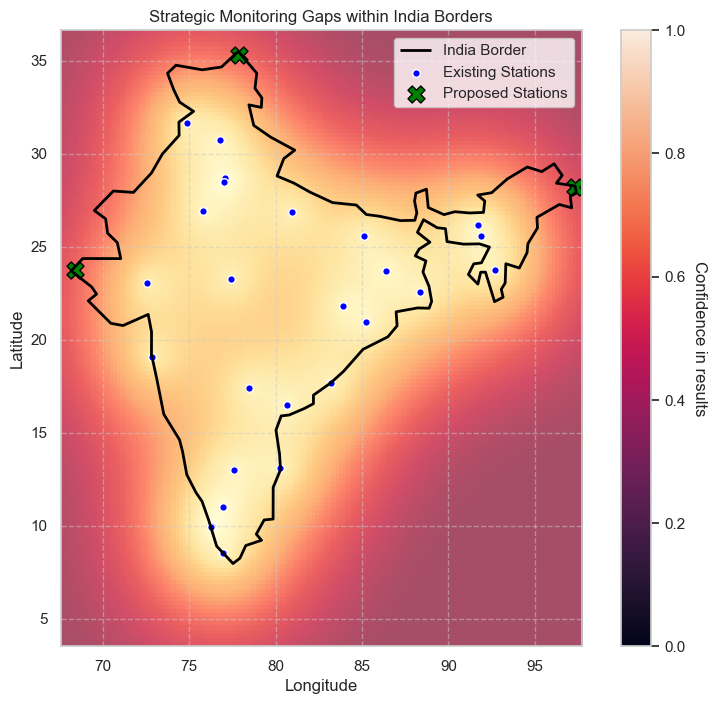

In [407]:
# Set the figure size
plt.figure(figsize=(10, 8))

# Render the Kriging heatmap (using ss_variance)
# We use the same 'extent' and 'cmap' parameters to maintain visual consistency
plt.imshow(ss_variance, extent=(grid_lon.min(), grid_lon.max(), grid_lat.min(), grid_lat.max()), 
           origin='lower', cmap='YlOrRd', alpha=0.7)

# Overlay the borders of India
# We plot the boundary on the current axes (gca) with a specific width and color
india_border.boundary.plot(ax=plt.gca(), color='black', linewidth=2, label='India Border')

# Plot existing monitoring stations (Blue circles)
plt.scatter(lons, lats, c='blue', marker='o', s=30, label='Existing Stations', edgecolors='white')

# Add the PROPOSED stations (Green crosses)
# Utilizing the 'final_land_spots' list obtained after geographic filtering and dispersal
if 'final_land_spots' in locals():
    # Unpack latitude and longitude coordinates
    fs_lats, fs_lons = zip(*final_land_spots)
    
    # Plot new points. The 'X' marker and size s=150 distinguish them from existing stations
    plt.scatter(fs_lons, fs_lats, c='green', marker='X', s=150, label='Proposed Stations', edgecolors='black')

cbar = plt.colorbar()
cbar.set_label('Confidence in results', rotation=270, labelpad=15)

plt.title('Strategic Monitoring Gaps within India Borders')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Enable the grid if it was present on your original plot
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

This plot represents the culmination of the spatial analysis. By layering the Kriging Variance (heatmap) under the national borders, we clearly visualize the information gaps. The contrast between the blue circles (current data points) and green crosses (mathematically optimized new locations) demonstrates a data-driven strategy for expanding the monitoring network to eliminate the identified 27% spatial uncertainty.

The current monitoring network leaves critical gaps along the borders and in remote regions of India. A spatial uncertainty analysis (Kriging Variance) identified three priority locations for new stations: in the far west, the north, and the east. Installing sensors at these coordinates will reduce overall data uncertainty and ensure virtually complete coverage of the country.

## Final Conclusion

- **Multi-Factor Profiles​** Delhi and Gurugram exhibit complex pollution signatures, blending Benzene/NOx with seasonal Ozone fluctuations.​
- **Data Coverage (0.73)​** High statistical uncertainty is concentrated in remote, non-urbanized regions, which likely serve as clean environmental baselines.​
- **Regional Divergence​** Delhi and Jaipur are improving via industrial relocation, whereas Ahmedabad remains a hotspot due to stagnant food and beverage sector emissions.
- **Predictive Outlook​** SARIMA, LightGBM, and LSTM models show synchronous trends forecasting a pollution surge during the November–January peak season ​
- **Policy Recommendation​** Implement seasonal output restrictions on the chemical sector during peak season, with a primary focus on the Adani Wilmar facility in Ahmedabad due to its persistent emission profile and the heightened risk of regulatory capture